# New Zealand reference-case simulations and results analysis — v5

This notebook adapts the Punta Arenas export-and-analysis workflow to the
multi-zone Aotearoa New Zealand case.

- The model uses one input-defined scenario: `reference`.
- Node names and coordinates are read dynamically from `input_new_zealand/nodes.csv`.
- Generation, storage, hydrogen, transmission, and demand are read from the base NZ CSV files.
- PtX is disabled until a dedicated NZ PtX scenario and demand are defined.
- Solved scenario-years are exported to detailed CSV tables and optional `network.nc` files.

After the first complete run, set `RUN_SIMULATIONS = False`, restart the kernel,
and rerun the notebook to rebuild tables and figures without repeating the optimisation.

## v5 revision focus

- Separates run-of-river hydro, reservoir hydro, and BESS in every summary and dispatch figure.
- Uses a colour-blind-friendly palette with distinct wind and hydro shades.
- Adds monthly dispatch, emissions, reservoir inflow/generation/spill, and storage-level diagnostics.
- Treats hydrogen/UHS and BESS analyses as optional, so absent assets no longer stop the notebook.
- Preserves the detailed export, maps, critical-event analysis, curtailment, robustness, and cost sections.


## 1. Imports and shared configuration

All imports, workflow controls, scenario labels, technology groups, colours, and plotting settings are defined here.

In [31]:
from calendar import monthrange
from datetime import datetime, timezone
from pathlib import Path
from types import SimpleNamespace
import gc
import importlib
import inspect
import json
import shutil
import tempfile

import atlite
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pypsa
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle

import folium

from IPython.display import FileLink, IFrame, display
from matplotlib.patches import (
    Circle,
    FancyBboxPatch,
    Patch,
    Rectangle,
)

import config

config = importlib.reload(config)
config.configure_runtime_output()
plt.style.use("seaborn-v0_8-whitegrid")


In [32]:
# Workflow controls
# Keep RUN_SIMULATIONS=False when reopening the notebook to analyse existing exports.
RUN_SIMULATIONS = False
OVERWRITE_EXISTING_EXPORTS = True
EXPORT_NETWORK_NETCDF = True
EXPORT_AGGREGATED_SUMMARIES = True

# Analysis selections
ACTIVE_SCENARIO = "reference"
LOW_WIND_THRESHOLD = 0.20
LOW_SOLAR_THRESHOLD = 0.10
H2_LHV_MWH_PER_TON = 33.33

# Output directories
OUTPUT_ROOT = Path("output") / "output_new_zealand"
SIMULATION_EXPORT_DIR = OUTPUT_ROOT / "simulations"
TABLE_EXPORT_DIR = OUTPUT_ROOT / "tables"
PAPER_FIGURE_DIR = OUTPUT_ROOT / "figures"
ROBUSTNESS_EXPORT_DIR = OUTPUT_ROOT / "robustness"

for output_dir in (
    OUTPUT_ROOT,
    SIMULATION_EXPORT_DIR,
    TABLE_EXPORT_DIR,
    PAPER_FIGURE_DIR,
    ROBUSTNESS_EXPORT_DIR,
):
    output_dir.mkdir(parents=True, exist_ok=True)

# Figure export settings
PAPER_MODE = True
PAPER_DPI = 300
COST_AXIS_LABEL = "Cost [million USD/yr]"

CM_TO_INCH = 1 / 2.54
WORD_DOUBLE_COL_IN = 16.0 * CM_TO_INCH
FIGSIZE_2COL = (WORD_DOUBLE_COL_IN, 3.35)
FIGSIZE_PAPER_2X2 = (WORD_DOUBLE_COL_IN, 4.95)
FIGSIZE_2COL_LARGE = (7.2, 5.6)

FONT_SIZE_BASE = 9
FONT_SIZE_SMALL = 8
FONT_SIZE_LABEL = 9
FONT_SIZE_PANEL = 9

plt.rcParams.update({
    "font.size": FONT_SIZE_BASE,
    "axes.labelsize": FONT_SIZE_BASE,
    "axes.titlesize": FONT_SIZE_BASE,
    "xtick.labelsize": FONT_SIZE_SMALL,
    "ytick.labelsize": FONT_SIZE_SMALL,
    "legend.fontsize": FONT_SIZE_SMALL,
})

# Map settings
MAP_WIDTH = "760px"
MAP_HEIGHT = "500px"
MAP_ZOOM = 5

SAVE_INTERACTIVE_HTML = True
SAVE_STATIC_PNG = True

MAP_OUTPUT_DIR = PAPER_FIGURE_DIR / "maps"
MAP_TABLE_DIR = TABLE_EXPORT_DIR / "maps"

MAP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MAP_TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Scenario labels and order
SCENARIO_LABELS = {
    "reference": "Reference",
}
SCENARIO_TECH_LABELS = {
    "reference": "Reference",
}
SCENARIO_PLOT_ORDER = list(SCENARIO_LABELS)
SCENARIO_ORDER_RANK = {
    code: rank for rank, code in enumerate(SCENARIO_PLOT_ORDER)
}
SCENARIO_AXIS_LABELS = {
    "reference": "Reference",
}

# Technology and demand group definitions
#
# The palette follows a colour-blind-friendly logic:
# - wind remains light sky blue;
# - run-of-river hydro is medium blue;
# - reservoir hydro is dark blue;
# - BESS remains purple and is never used as a hydro fallback.
TECH_COLORS = {
    "wind": "#56B4E9",
    "solar": "#F0E442",
    "solar_pv": "#F0E442",
    "hydro": "#0072B2",
    "hydro_run_of_river": "#0072B2",
    "run_of_river": "#0072B2",
    "hydro_fixed": "#0072B2",
    "hydro_reservoir": "#173F5F",
    "hydro_storage": "#173F5F",
    "reservoir_hydro": "#173F5F",
    "hydro_flexible": "#173F5F",
    "hydro_inflow": "#6BAED6",
    "hydro_spill": "#BFD7EA",
    "geothermal": "#7FBF3F",
    "geo": "#7FBF3F",
    "coal": "#3D3D3D",
    "thermal_other": "#A1887F",
    "ocgt": "#8C8C8C",
    "ccgt": "#666666",
    "gas": "#9E9E9E",
    "natural_gas": "#9E9E9E",
    "gas_cogeneration": "#B0B0B0",
    "gas_peaker": "#737373",
    "diesel": "#8D6E63",
    "bess": "#9C6ADE",
    "bess_soc": "#5E3C99",
    "electrolyzer": "#009E73",
    "electrolyser": "#009E73",
    "h2_fuel_cell": "#E69F00",
    "h2_turbine": "#A65E2E",
    "hydrogen_storage": "#26A69A",
    "uhs_injection": "#1E88E5",
    "uhs_withdrawal": "#3949AB",
    "uhs_storage": "#8E24AA",
    "slack": "#D55E00",
    "asu": "#80CBC4",
    "dac": "#4DB6AC",
    "solar_utility": "#E6B800",
    "solar_residential": "#FFE082",
    "solar_generic": "#F0E442",
    "ptx_shortfall": "#D55E00",
    "transmission": "#2E7D32",
}

HYDRO_GROUPS = [
    "Hydro run-of-river",
    "Hydro reservoir",
]

TECH_GROUPS = [
    "Wind",
    "Solar PV",
    "Hydro run-of-river",
    "Hydro reservoir",
    "Geothermal",
    "BESS",
    "Thermal",
    "Hydrogen",
    "Slack",
    "Other",
]
TECH_COLORS_GROUPED = {
    "Wind": TECH_COLORS["wind"],
    "Solar PV": TECH_COLORS["solar"],
    "Hydro run-of-river": TECH_COLORS["hydro_run_of_river"],
    "Hydro reservoir": TECH_COLORS["hydro_reservoir"],
    "Geothermal": TECH_COLORS["geothermal"],
    "BESS": TECH_COLORS["bess"],
    "Thermal": TECH_COLORS["ocgt"],
    "Hydrogen": TECH_COLORS["electrolyzer"],
    "Slack": TECH_COLORS["slack"],
    "Other": "#9E9E9E",
}
TECH_LEGEND_LABELS = {
    group: group for group in TECH_GROUPS
}
TECH_LEGEND_LABELS.update({
    "Hydro run-of-river": "Hydro RoR",
    "Hydro reservoir": "Hydro reservoir",
})

DEMAND_COMPONENT_LABELS = {
    "base_load": "Base load",
    "heating": "Heating",
    "ev": "EVs",
    "cooking": "Cooking",
    "process_electrification": "Process electrification",
    "other": "Other local demand",
}
DEMAND_COMPONENT_COLORS = {
    "base_load": "#4c78a8",
    "heating": "#f58518",
    "ev": "#54a24b",
    "cooking": "#b279a2",
    "process_electrification": "#e45756",
    "other": "#9e9e9e",
    "electrolyser": TECH_COLORS["electrolyzer"],
    "ptx_aux": TECH_COLORS["asu"],
}
DEMAND_GROUPS = [
    "Base load",
    "Heating",
    "EVs",
    "Cooking",
    "Process electrification",
    "Electrolyser",
    "PtX auxiliaries",
    "Other local demand",
]
DEMAND_COLORS_GROUPED = {
    "Base load": DEMAND_COMPONENT_COLORS["base_load"],
    "Heating": DEMAND_COMPONENT_COLORS["heating"],
    "EVs": DEMAND_COMPONENT_COLORS["ev"],
    "Cooking": DEMAND_COMPONENT_COLORS["cooking"],
    "Process electrification": DEMAND_COMPONENT_COLORS["process_electrification"],
    "Electrolyser": DEMAND_COMPONENT_COLORS["electrolyser"],
    "PtX auxiliaries": DEMAND_COMPONENT_COLORS["ptx_aux"],
    "Other local demand": DEMAND_COMPONENT_COLORS["other"],
}
DEMAND_LEGEND_LABELS = {
    "Base load": "Base load",
    "Heating": "Heating",
    "EVs": "EVs",
    "Cooking": "Cooking",
    "Process electrification": "Process elec.",
    "Electrolyser": "Electrolyser",
    "PtX auxiliaries": "PtX aux.",
    "Other local demand": "Other demand",
}

GENERATOR_CARRIER_GROUP = {
    # Variable renewables
    "wind": "Wind",
    "onwind": "Wind",
    "onshore_wind": "Wind",
    "offwind": "Wind",
    "offshore_wind": "Wind",
    "solar": "Solar PV",
    "solar_pv": "Solar PV",
    "pv": "Solar PV",
    "photovoltaic": "Solar PV",

    # New Zealand hydro categories
    "hydro": "Hydro run-of-river",
    "hydro_fixed": "Hydro run-of-river",
    "hydro_run_of_river": "Hydro run-of-river",
    "run_of_river": "Hydro run-of-river",
    "hydro_flexible": "Hydro reservoir",
    "hydro_storage": "Hydro reservoir",
    "hydro_reservoir": "Hydro reservoir",
    "reservoir_hydro": "Hydro reservoir",

    # Geothermal
    "geo": "Geothermal",
    "geothermal": "Geothermal",
    "geo_fixed": "Geothermal",
    "geo_flexible": "Geothermal",

    # Thermal fleet used in the NZ generator input
    "ocgt": "Thermal",
    "ccgt": "Thermal",
    "gas": "Thermal",
    "natural_gas": "Thermal",
    "gas_peaker": "Thermal",
    "gas_cogeneration": "Thermal",
    "other_cogeneration": "Thermal",
    "coal": "Thermal",
    "diesel": "Thermal",
    "diesel_peaker": "Thermal",
    "bio_reciprocating": "Thermal",
    "thermal": "Thermal",
    "thermal_other": "Thermal",

    # Diagnostic supply
    "slack": "Slack",
    "load_shedding": "Slack",
    "unserved": "Slack",
    "lost_load": "Slack",
}
STORAGE_UNIT_CARRIER_GROUP = {
    "bess": "BESS",
    "battery": "BESS",
    "battery_storage": "BESS",
    "hydro_storage": "Hydro reservoir",
    "hydro_reservoir": "Hydro reservoir",
    "reservoir_hydro": "Hydro reservoir",
}
ELECTRICITY_OUTPUT_LINK_GROUP = {
    "h2_fuel_cell": "Hydrogen",
    "fuel_cell": "Hydrogen",
    "h2_turbine": "Hydrogen",
    "hydrogen_turbine": "Hydrogen",
}

def _norm_carrier(value):
    """Normalise carrier labels used by grouped NZ plots."""
    return (
        str(value)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
    )


def clean_technology_group(value):
    """Map generator, storage and link carriers to broad NZ groups.

    Exact mappings are checked first. Prefix and keyword rules then protect
    the plots against future labels such as hydro_*, geothermal_*, *_peaker
    and *_cogeneration.
    """
    carrier = _norm_carrier(value)

    if carrier in GENERATOR_CARRIER_GROUP:
        return GENERATOR_CARRIER_GROUP[carrier]
    if carrier in STORAGE_UNIT_CARRIER_GROUP:
        return STORAGE_UNIT_CARRIER_GROUP[carrier]
    if carrier in ELECTRICITY_OUTPUT_LINK_GROUP:
        return ELECTRICITY_OUTPUT_LINK_GROUP[carrier]

    reservoir_tokens = (
        "hydro_storage",
        "hydro_reservoir",
        "reservoir_hydro",
        "hydro_flexible",
    )
    if any(token in carrier for token in reservoir_tokens):
        return "Hydro reservoir"

    if "run_of_river" in carrier or carrier in {"hydro", "hydro_fixed"}:
        return "Hydro run-of-river"

    if carrier.startswith("hydro"):
        return "Hydro run-of-river"

    if carrier.startswith("geo") or "geothermal" in carrier:
        return "Geothermal"

    if carrier.startswith("wind") or carrier in {"onwind", "offwind"}:
        return "Wind"

    if carrier.startswith("solar") or carrier in {"pv", "photovoltaic"}:
        return "Solar PV"

    thermal_tokens = (
        "ocgt",
        "ccgt",
        "gas",
        "coal",
        "diesel",
        "thermal",
        "peaker",
        "cogeneration",
        "reciprocating",
        "bio_",
    )
    if any(token in carrier for token in thermal_tokens):
        return "Thermal"

    if any(token in carrier for token in ("slack", "unserved", "lost_load", "load_shedding")):
        return "Slack"

    if any(token in carrier for token in ("bess", "battery")):
        return "BESS"

    if any(token in carrier for token in ("hydrogen", "h2_", "fuel_cell", "electroly")):
        return "Hydrogen"

    return "Other"


def storage_unit_group(storage_units: pd.DataFrame, asset) -> str:
    """Classify one StorageUnit without ever assuming that it is a battery."""
    if storage_units is None or asset not in storage_units.index:
        return "Other"

    row = storage_units.loc[asset]
    source_type = _norm_carrier(row.get("source_asset_type", ""))
    carrier = _norm_carrier(row.get("carrier", ""))

    if source_type in {"hydro_reservoir", "reservoir_hydro"}:
        return "Hydro reservoir"

    return STORAGE_UNIT_CARRIER_GROUP.get(
        carrier,
        clean_technology_group(carrier),
    )


def storage_unit_assets(net, target_group: str) -> pd.Index:
    """Return StorageUnit IDs assigned to the requested technology group."""
    if not hasattr(net, "storage_units") or net.storage_units.empty:
        return pd.Index([], dtype=object)

    return pd.Index([
        asset
        for asset in net.storage_units.index
        if storage_unit_group(net.storage_units, asset) == target_group
    ])


def dispatch_plot_key(carrier) -> str:
    """Return compact, non-duplicated carrier keys for detailed dispatch plots."""
    carrier = _norm_carrier(carrier)
    group = clean_technology_group(carrier)

    if group == "Hydro run-of-river":
        return "hydro_run_of_river"
    if group == "Hydro reservoir":
        return "hydro_reservoir"
    if group == "Geothermal":
        return "geothermal"
    if group == "Wind":
        return "wind"
    if group == "Solar PV":
        return "solar"
    if group == "Slack":
        return "slack"
    if group == "BESS":
        return "bess"

    if carrier in {"coal", "diesel", "ocgt", "ccgt", "gas_peaker", "gas_cogeneration"}:
        return carrier
    if group == "Thermal":
        return "thermal_other"
    return carrier or "other"


def column_or_zero(df, column):
    """Return a numeric dataframe column or an aligned zero-valued Series."""
    if column in df.columns:
        return pd.to_numeric(df[column], errors="coerce").fillna(0.0)

    return pd.Series(0.0, index=df.index, dtype=float)


def _metric_columns_by_group(df, prefix, suffix, target_group):
    """Return dynamic summary columns belonging to one broad technology group."""
    selected = []

    for column in df.columns:
        column_name = str(column)
        if not (column_name.startswith(prefix) and column_name.endswith(suffix)):
            continue

        carrier = column_name[len(prefix):len(column_name) - len(suffix)]
        if clean_technology_group(carrier) == target_group:
            selected.append(column)

    return selected


def sum_metric_by_group(df, prefix, suffix, target_group):
    """Sum all dynamic summary columns mapped to a broad technology group."""
    selected = _metric_columns_by_group(
        df,
        prefix=prefix,
        suffix=suffix,
        target_group=target_group,
    )

    if not selected:
        return pd.Series(0.0, index=df.index, dtype=float)

    return (
        df[selected]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0.0)
        .sum(axis=1)
    )


COST_GROUP_KEYWORDS = {
    "Slack": ["slack", "load_shedding", "load shedding", "unserved", "lost_load", "lost load"],
    "Wind": ["wind"],
    "Solar PV": ["solar", "pv"],
    "Hydro reservoir": ["hydro_storage", "hydro_reservoir", "reservoir_hydro", "hydro_flexible"],
    "Hydro run-of-river": ["hydro_run_of_river", "run_of_river", "hydro_fixed", "hydro"],
    "Geothermal": ["geothermal", "geo"],
    "BESS": ["bess", "battery"],
    "Thermal": ["ocgt", "ccgt", "gas", "natural_gas", "coal", "diesel", "thermal", "peaker", "cogeneration", "reciprocating", "bio_"],
    "Hydrogen": ["electroly", "hydrogen", "h2", "fuel_cell", "fuel cell", "h2_turbine", "uhs"],
    "PtX": ["ptx", "asu", "dac", "ammonia", "methanol", "synthesis"],
}


def scenario_label(
    scenario_code: str,
    paper_id: str | None = None,
    linebreak: bool = False,
) -> str:
    """Return a readable scenario label without underscores."""
    if scenario_code in SCENARIO_LABELS:
        label = SCENARIO_LABELS[scenario_code]
    else:
        clean = str(scenario_code).replace("_", " ")
        label = f"{paper_id} {clean}" if paper_id else clean
    return label.replace(" ", "\n", 1) if linebreak else label


def scenario_axis_label(scenario_code: str) -> str:
    """Return a compact two-line scenario label."""
    return SCENARIO_AXIS_LABELS.get(
        scenario_code,
        scenario_label(str(scenario_code), linebreak=True),
    )


def apply_scenario_order(
    df: pd.DataFrame,
    scenario_col: str = "scenario",
) -> pd.DataFrame:
    """Sort a table using the paper scenario order."""
    out = df.copy()
    out["_scenario_order"] = (
        out[scenario_col].map(SCENARIO_ORDER_RANK).fillna(999).astype(int)
    )
    return (
        out.sort_values(["_scenario_order", scenario_col])
        .drop(columns="_scenario_order")
    )


def clean_technology_label(label: str) -> str:
    """Return readable technology labels for legends and tables."""
    replacements = {
        "wind": "Wind",
        "solar": "Solar PV",
        "solar_pv": "Solar PV",
        "hydro": "Hydro run-of-river",
        "hydro_fixed": "Hydro run-of-river",
        "hydro_run_of_river": "Hydro run-of-river",
        "run_of_river": "Hydro run-of-river",
        "hydro_flexible": "Hydro reservoir",
        "hydro_storage": "Hydro reservoir",
        "hydro_reservoir": "Hydro reservoir",
        "reservoir_hydro": "Hydro reservoir",
        "geo": "Geothermal",
        "geothermal": "Geothermal",
        "coal": "Coal",
        "thermal_other": "Other thermal",
        "bess": "BESS",
        "bess_charge": "BESS charge",
        "ocgt": "OCGT",
        "ccgt": "CCGT",
        "gas": "Gas",
        "natural_gas": "Natural gas",
        "gas_cogeneration": "Gas cogeneration",
        "gas_peaker": "Gas peaker",
        "other_cogeneration": "Other cogeneration",
        "diesel": "Diesel",
        "diesel_peaker": "Diesel peaker",
        "bio_reciprocating": "Bio reciprocating engine",
        "electrolyzer": "Electrolyser",
        "h2_fuel_cell": "H2 fuel cell",
        "h2_turbine": "H2 turbine",
        "uhs_injection": "UHS injection",
        "uhs_withdrawal": "UHS withdrawal",
        "uhs_storage": "UHS storage",
        "hydrogen_storage": "H2 tank",
        "slack": "Slack",
        "asu": "ASU",
        "dac": "DAC",
        "Local electricity demand": "Local electricity demand",
        "Demand + flexible electricity use": "Demand + flexible electricity use",
    }
    return replacements.get(str(label), str(label).replace("_", " ").title())


def panel_label(ax, label: str, x: float = 0.015, y: float = 0.965):
    """Add a panel label inside an axis."""
    ax.text(
        x,
        y,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=FONT_SIZE_PANEL,
        fontweight="bold",
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.75, "pad": 1.5},
        zorder=20,
    )


def save_paper_figure(fig, filename: str, folder: Path | None = None) -> Path:
    """Save a figure using the notebook export settings."""
    out_dir = PAPER_FIGURE_DIR if folder is None else Path(folder)
    out_dir.mkdir(parents=True, exist_ok=True)
    path = out_dir / filename
    fig.savefig(path, dpi=PAPER_DPI, bbox_inches="tight")
    print(f"Saved figure: {path}")
    return path


def finish_axis(ax, xlabel=None, ylabel=None):
    """Apply the shared axis formatting."""
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", alpha=0.25)
    ax.tick_params(axis="both", labelsize=FONT_SIZE_SMALL)
    return ax


## 2. Simulation configuration

This section defines planning years, solver settings, scenarios, input paths, and emissions-cap rules. It does not run the model by itself.

In [33]:
# Model and solver settings
#
# Keep the short historical run as the safe default. Change to
# [2023, 2030, 2040, 2050] when the full reference expansion pathway is ready.
years = [2025]
detailed_year = years[-1]

case_folder = "input_new_zealand"
base_case_name = "new_zealand"
cutout_case_name = "new_zealand"

critical_weather_year = 2025
cutout_file = f"{cutout_case_name}_{critical_weather_year}.nc"

vre_profile_method = "atlite_technology"
wind_turbine = "Vestas_V112_3MW"
solar_panel = "CSi"
solar_orientation = "latitude_optimal"

solver_name = "gurobi"
time_limit = 2000
mip_gap = 0.02
threads = 4

enable_heat = False
enable_year_linking = True
prepare_cutout = False
fallback_to_highs = False

# Do not silently fall back to the synthetic profile in the formal NZ run.
REQUIRE_DEMAND_CSV = True

paths_base = config.get_case_paths(case_folder)

RESULT_BUNDLE_ROOT = SIMULATION_EXPORT_DIR
RESULT_MANIFEST_PATH = OUTPUT_ROOT / "manifest.csv"

_run_case_multiple_params = inspect.signature(config.run_case_multiple_years).parameters
SUPPORTS_PTX = "enable_ptx" in _run_case_multiple_params
SUPPORTS_HYDRO_INPUTS = {
    "csv_hydro_assets",
    "csv_hydro_inflows",
}.issubset(_run_case_multiple_params)

# One NZ scenario. The Reference pipeline, retirement status, and investment
# candidates are already encoded in the CSV inputs.
SCENARIOS_ALL = [
    {
        "code": "reference",
        "paper_id": "Reference",
        "technology": "Input-defined NZ reference system",
        "demand": "2025 Grid_export profile",
        "demand_profile_code": "reference",
        "enable_hydrogen": False,
        "enable_ptx": False,
        "co2_policy": "none",
    },
]

RUN_SCENARIO_CODES = ["reference"]
SCENARIOS = [sc for sc in SCENARIOS_ALL if sc["code"] in RUN_SCENARIO_CODES]

# Optional CSV-driven hydro formulation used by the NZ reservoir model.
HYDRO_ASSETS_PATH = Path(
    paths_base.get(
        "csv_hydro_assets",
        Path(case_folder) / "hydro_assets.csv",
    )
)
HYDRO_INFLOWS_PATH = Path(
    paths_base.get(
        "csv_hydro_inflows",
        Path(case_folder) / "hydro_inflows.csv",
    )
)
USE_CSV_HYDRO = (
    HYDRO_ASSETS_PATH.exists()
    and HYDRO_INFLOWS_PATH.exists()
)

if USE_CSV_HYDRO and not SUPPORTS_HYDRO_INPUTS:
    raise RuntimeError(
        "NZ hydro input files were found, but the imported config.py does not "
        "accept csv_hydro_assets/csv_hydro_inflows. Replace config.py with the "
        "hydro-enabled version before running simulations."
    )

print(
    "CSV-driven NZ hydro: "
    f"{'enabled' if USE_CSV_HYDRO else 'not enabled'}"
)
if USE_CSV_HYDRO:
    print(f"  Hydro assets:  {HYDRO_ASSETS_PATH}")
    print(f"  Hydro inflows: {HYDRO_INFLOWS_PATH}")


def _read_enabled_nodes() -> pd.DataFrame:
    """Read enabled NZ nodes and normalise Boolean values."""
    nodes_df = pd.read_csv(paths_base["csv_nodes"], comment="#")
    if "zone" not in nodes_df.columns:
        raise ValueError(f"{paths_base['csv_nodes']} must contain a zone column.")

    if "enabled" in nodes_df.columns:
        enabled = (
            nodes_df["enabled"].astype(str).str.strip().str.lower()
            .isin({"true", "1", "yes", "y"})
        )
        nodes_df = nodes_df.loc[enabled].copy()

    nodes_df["zone"] = nodes_df["zone"].astype(str).str.strip()
    if nodes_df["zone"].duplicated().any():
        duplicates = nodes_df.loc[nodes_df["zone"].duplicated(), "zone"].tolist()
        raise ValueError(f"Duplicated enabled zones in nodes.csv: {duplicates}")
    return nodes_df


def _validate_nz_input_zones() -> pd.DataFrame:
    """Fail early when any NZ input refers to an unknown node."""
    nodes_df = _read_enabled_nodes()
    zones = set(nodes_df["zone"])

    checks = [
        ("generators", paths_base.get("csv_capacity"), ("zone",)),
        ("storage", paths_base.get("csv_storage"), ("zone",)),
        ("hydrogen", paths_base.get("csv_hydrogen"), ("zone",)),
        ("hydro assets", str(HYDRO_ASSETS_PATH), ("zone",)),
        ("interlinks", paths_base.get("csv_interlinks"), ("from_zone", "to_zone")),
    ]

    for label, filename, columns in checks:
        if not filename or not Path(filename).exists():
            continue
        table = pd.read_csv(filename, comment="#")
        for column in columns:
            if column not in table.columns:
                continue
            referenced = set(table[column].dropna().astype(str).str.strip())
            unknown = sorted(referenced - zones)
            if unknown:
                raise ValueError(
                    f"{label} input {filename} contains zones absent from nodes.csv: {unknown}"
                )

    demand_path = Path(paths_base["csv_demand"])
    if REQUIRE_DEMAND_CSV and not demand_path.exists():
        raise FileNotFoundError(
            f"Missing formal NZ demand profile: {demand_path}. "
            "Run build_nz_demand_2025.py before running the optimisation."
        )

    if demand_path.exists():
        demand = pd.read_csv(demand_path, usecols=lambda column: column in {"zone"})
        if "zone" in demand.columns:
            demand_zones = set(demand["zone"].dropna().astype(str).str.strip())
            unknown = sorted(demand_zones - zones)
            missing = sorted(zones - demand_zones)
            if unknown or missing:
                raise ValueError(
                    "Demand/node mismatch. "
                    f"Unknown demand zones: {unknown}; nodes without demand: {missing}"
                )

    print(f"Enabled NZ zones ({len(zones)}): {', '.join(nodes_df['zone'])}")
    print(f"Demand input: {demand_path}")
    return nodes_df


nodes_input = _validate_nz_input_zones()

# The migrated NZ generator table may contain decommissioning_year. The notebook
# passes that column to config.py, but retirement only works if the imported
# config.py explicitly implements it.
capacity_header = pd.read_csv(paths_base["csv_capacity"], comment="#", nrows=0)
if "decommissioning_year" in capacity_header.columns:
    try:
        config_source_path = Path(inspect.getsourcefile(config))
        config_source_text = config_source_path.read_text(encoding="utf-8")
    except Exception:
        config_source_text = ""
    if "decommissioning_year" not in config_source_text:
        print(
            "WARNING: generators_capacity.csv contains decommissioning_year, "
            "but the imported config.py does not appear to use that field. "
            "Retired units may remain available unless config.py is updated."
        )

grouped_reference = Path(case_folder) / "generators_capacity_reference_grouped.csv"
canonical_capacity = Path(paths_base["csv_capacity"])
if grouped_reference.exists() and canonical_capacity.exists():
    print(
        "Note: generators_capacity_reference_grouped.csv also exists. "
        "This notebook uses generators_capacity.csv; confirm that the canonical "
        "file is the updated grouped Reference input."
    )
elif grouped_reference.exists() and not canonical_capacity.exists():
    raise FileNotFoundError(
        "Found generators_capacity_reference_grouped.csv but not "
        "generators_capacity.csv. Copy or rename the updated Reference file to "
        "input_new_zealand/generators_capacity.csv."
    )


def _scenario_optional_csv(base_name: str, scenario_code: str) -> str:
    """
    Use the base NZ input for the reference case.

    Scenario-specific files remain supported for future NZ sensitivities through
    names such as generators_capacity_<scenario>.csv.
    """
    fallback = Path(case_folder) / f"{base_name}.csv"
    if scenario_code == "reference":
        return str(fallback)

    specific = Path(case_folder) / f"{base_name}_{scenario_code}.csv"
    return str(specific if specific.exists() else fallback)


def _demand_csv_for_scenario(sc: dict) -> tuple[str, str]:
    """Return the formal base NZ demand and a compatible summary path."""
    demand_file = Path(paths_base["csv_demand"])
    if REQUIRE_DEMAND_CSV and not demand_file.exists():
        raise FileNotFoundError(
            f"Missing demand file for {sc['code']}: {demand_file}. "
            "Run build_nz_demand_2025.py first."
        )

    summary_candidates = [
        Path(case_folder) / "demand_validation_2025.csv",
        Path(case_folder) / "demand_validation_summary.csv",
        Path(paths_base.get("csv_demand_summary", "demand_validation_summary.csv")),
    ]
    demand_summary = next(
        (candidate for candidate in summary_candidates if candidate.exists()),
        summary_candidates[0],
    )
    return str(demand_file), str(demand_summary)


def _load_ptx_monthly_demand_for_scenario(
    sc: dict,
    csv_ptx_monthly_demand: str,
) -> pd.DataFrame | None:
    """Load a future NZ PtX demand only when explicitly enabled."""
    if not sc.get("enable_ptx", False):
        return None

    if not SUPPORTS_PTX:
        raise RuntimeError("The imported config.py does not expose enable_ptx.")

    ptx_path = Path(csv_ptx_monthly_demand)
    if not ptx_path.exists():
        raise FileNotFoundError(f"Missing PtX monthly demand file: {ptx_path}")

    df = config.load_ptx_monthly_demand_from_csv(csv_ptx_monthly_demand)
    if df is None or df.empty:
        raise ValueError(f"PtX monthly demand file is empty: {ptx_path}")

    if "scenario" in df.columns:
        accepted = {
            str(sc["code"]),
            str(sc.get("paper_id", "")),
            str(sc.get("ptx_demand_code", sc["code"])),
        }
        df = df[df["scenario"].astype(str).str.strip().isin(accepted)].copy()

    if df.empty:
        raise ValueError(f"No PtX demand rows found for scenario {sc['code']}.")
    return df


def _ptx_demand_summary(ptx_monthly_demand_df: pd.DataFrame | None) -> dict:
    """Compact annual PtX demand summary for metadata."""
    if ptx_monthly_demand_df is None or ptx_monthly_demand_df.empty:
        return {}

    table = (
        ptx_monthly_demand_df
        .groupby(["year", "product"], dropna=False)["demand_tons"]
        .sum()
        .reset_index()
    )
    return {
        f"{int(row['year']) if pd.notna(row['year']) else 'all'}_{row['product']}_tons":
            float(row["demand_tons"])
        for _, row in table.iterrows()
    }


def _compute_total_co2_by_year(results_dict: dict) -> dict:
    """Compute annual CO2 emissions from PyPSA network outputs."""
    out = {}

    for year, result in results_dict.items():
        net = result["network"]

        if "co2_emissions" not in net.carriers.columns:
            out[year] = 0.0
            continue

        carrier_factors = net.carriers["co2_emissions"].fillna(0.0)
        dispatch = net.generators_t.p.reindex(columns=net.generators.index, fill_value=0.0)

        gen_carrier = net.generators["carrier"].astype(str)
        gen_eff = net.generators["efficiency"].replace(0, np.nan).fillna(1.0)

        emission_factor_per_mwh_el = gen_carrier.map(carrier_factors).fillna(0.0) / gen_eff
        emissions_ts = dispatch.multiply(emission_factor_per_mwh_el, axis=1)

        out[year] = float(emissions_ts.to_numpy().sum())

    return out


def _co2_cap_from_policy(policy: str, bau_co2_by_year: dict | None) -> dict | None:
    """Resolve scenario emissions cap."""
    if policy == "none":
        return None

    if bau_co2_by_year is None:
        raise ValueError(f"BAU emissions are needed before applying CO2 policy: {policy}")

    start_year = min(years)
    target_year = 2050

    def _linear_cap_fraction(y: int, target_reduction: float) -> float:
        """Fraction of same-year BAU emissions allowed in year y."""
        if y <= start_year:
            return 1.0
        if y >= target_year:
            return 1.0 - target_reduction
        progress = (y - start_year) / (target_year - start_year)
        return 1.0 - target_reduction * progress

    if policy in {"reduction_50_2050", "bau_50_2050", "bau_50"}:
        return {
            year: _linear_cap_fraction(year, target_reduction=0.50)
            * float(bau_co2_by_year[year])
            for year in years
        }

    if policy == "net_zero_2050":
        return {
            year: _linear_cap_fraction(year, target_reduction=1.00)
            * float(bau_co2_by_year[year])
            for year in years
        }

    raise ValueError(f"Unknown CO2 policy: {policy}")




CSV-driven NZ hydro: enabled
  Hydro assets:  input_new_zealand\hydro_assets.csv
  Hydro inflows: input_new_zealand\hydro_inflows.csv
Enabled NZ zones (14): northland, auckland, waikato, bay_of_plenty, taranaki, hawkes_bay, manawatu_whanganui, wellington, nelson, marlborough, west_coast, canterbury, otago, southland
Demand input: input_new_zealand\demand_profiles.csv


## 3. Simulation, detailed export, and memory release

When `RUN_SIMULATIONS = True`, the notebook runs the New Zealand **Reference**
case and writes each planning year under:

```text
output/output_new_zealand/
├── manifest.csv
├── simulations/
│   └── reference/
│       ├── 2023/
│       │   ├── network.nc
│       │   ├── metadata.json
│       │   ├── static_*.csv
│       │   ├── ts_*.csv
│       │   └── result_*.csv
│       ├── 2030/
│       ├── 2040/
│       └── 2050/
├── tables/
├── figures/
└── robustness/
```

Only the years listed in `years` are produced. With the default
`years = [2023]`, only the `2023/` folder is created.

`OVERWRITE_EXISTING_EXPORTS = True` removes and recreates each scenario-year
folder when simulations are rerun. The CSV files support routine analysis,
while `network.nc` preserves the complete solved PyPSA network. After export,
the solved networks are removed from memory.


In [34]:

STATIC_COMPONENTS = [
    "buses",
    "carriers",
    "generators",
    "loads",
    "storage_units",
    "stores",
    "links",
    "lines",
]

DYNAMIC_COMPONENTS = [
    "generators",
    "loads",
    "storage_units",
    "stores",
    "links",
    "lines",
]


def _json_safe(value):
    """Convert common NumPy, pandas, and Path values to JSON-safe objects."""
    if value is None:
        return None
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return None if np.isnan(value) else float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    if isinstance(value, (pd.Timestamp, datetime)):
        return value.isoformat()
    if isinstance(value, dict):
        return {str(k): _json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple, set)):
        return [_json_safe(v) for v in value]
    if pd.isna(value):
        return None
    return value


def _write_csv_table(df: pd.DataFrame, path: Path) -> bool:
    """Write a non-empty table and preserve its index."""
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        return False
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=True, index_label=df.index.name or "index")
    return True


def _iter_dynamic_tables(component_t):
    """Yield all non-empty pandas tables available in a PyPSA time-series container."""
    seen = set()

    try:
        items = component_t.items()
    except Exception:
        items = []

    for name, value in items:
        if isinstance(value, pd.DataFrame) and not value.empty:
            seen.add(str(name))
            yield str(name), value

    for name in dir(component_t):
        if name.startswith("_") or name in seen:
            continue
        try:
            value = getattr(component_t, name)
        except Exception:
            continue
        if isinstance(value, pd.DataFrame) and not value.empty:
            yield name, value


def _is_boolean_series(series: pd.Series) -> bool:
    """Return True for native, nullable, or object columns containing booleans."""
    if pd.api.types.is_bool_dtype(series.dtype):
        return True
    if series.dtype != object:
        return False
    values = series.dropna()
    return bool(len(values)) and values.map(
        lambda value: isinstance(value, (bool, np.bool_))
    ).all()


def _iter_network_dataframes(net):
    """Yield every accessible PyPSA static or time-series DataFrame once."""
    seen = set()

    def emit(table):
        if isinstance(table, pd.DataFrame) and id(table) not in seen:
            seen.add(id(table))
            return table
        return None

    # Direct network tables, including snapshot and investment-period weights.
    for value in vars(net).values():
        table = emit(value)
        if table is not None:
            yield table
            continue

        try:
            items = value.items()
        except Exception:
            continue

        for _, item in items:
            table = emit(item)
            if table is not None:
                yield table

    # Component API covers standard and custom PyPSA components, including
    # tables not listed explicitly in STATIC_COMPONENTS/DYNAMIC_COMPONENTS.
    try:
        components = net.iterate_components()
    except Exception:
        components = []

    for component in components:
        table = emit(getattr(component, "static", None))
        if table is not None:
            yield table

        dynamic = getattr(component, "dynamic", None)
        try:
            dynamic_items = dynamic.items()
        except Exception:
            dynamic_items = []

        for _, item in dynamic_items:
            table = emit(item)
            if table is not None:
                yield table


def _netcdf_safe_value(value):
    """Encode booleans in nested metadata using NetCDF-compatible integers."""
    if isinstance(value, (bool, np.bool_)):
        return int(value)
    if isinstance(value, dict):
        return {key: _netcdf_safe_value(item) for key, item in value.items()}
    if isinstance(value, list):
        return [_netcdf_safe_value(item) for item in value]
    if isinstance(value, tuple):
        return tuple(_netcdf_safe_value(item) for item in value)
    return value


def export_network_netcdf_safe(
    net,
    path: str | Path,
    strict: bool = False,
) -> Path | None:
    """
    Export a solved PyPSA network after temporarily encoding boolean columns.

    NetCDF does not support native boolean variables. Custom model columns such
    as ``enabled`` or ``continuous_operation`` are therefore written as 0/1 in
    the exported file. The in-memory network is restored immediately afterwards.
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    backups = []

    for table in _iter_network_dataframes(net):
        for column in table.columns:
            series = table[column]
            if not isinstance(series, pd.Series) or not _is_boolean_series(series):
                continue

            backups.append((table, column, series.copy(deep=True)))
            encoded = series.map(
                lambda value: np.nan if pd.isna(value) else int(bool(value))
            )
            table[column] = (
                encoded.astype("float64")
                if encoded.isna().any()
                else encoded.astype("int8")
            )

    original_meta = getattr(net, "meta", None)
    meta_changed = isinstance(original_meta, dict)
    if meta_changed:
        net.meta = _netcdf_safe_value(original_meta)

    try:
        if path.exists():
            path.unlink()
        net.export_to_netcdf(path)
        return path
    except Exception as exc:
        if path.exists():
            path.unlink()
        if strict:
            raise RuntimeError(f"Could not export the solved network to {path}") from exc
        print(
            f"Warning: NetCDF export failed for {path}. "
            f"The detailed CSV export was preserved. Reason: {exc}"
        )
        return None
    finally:
        for table, column, original in backups:
            table[column] = original
        if meta_changed:
            net.meta = original_meta


def export_result_bundle(
    result: dict,
    scenario_metadata: dict,
    year: int,
    co2_tons: float,
    co2_cap_tons: float | None,
    demand_file: str,
    ptx_monthly_demand_file: str | None,
) -> dict:
    """
    Export one solved scenario-year to a self-contained folder.

    The CSV files support lightweight analysis without keeping solved networks
    in memory. The complete NetCDF network is also retained for later PyPSA
    analyses, fixed-capacity robustness runs, or additional diagnostics.
    """
    scenario_code = scenario_metadata["code"]
    bundle_dir = RESULT_BUNDLE_ROOT / scenario_code / str(int(year))


    bundle_dir.mkdir(parents=True, exist_ok=True)

    net = result["network"]
    exported_static = {}
    exported_dynamic = {}
    exported_result_tables = {}

    for component in STATIC_COMPONENTS:
        table = getattr(net, component, None)
        filename = f"static_{component}.csv"
        if _write_csv_table(table, bundle_dir / filename):
            exported_static[component] = filename

    snapshot_weightings = getattr(net, "snapshot_weightings", None)
    if isinstance(snapshot_weightings, pd.DataFrame):
        _write_csv_table(snapshot_weightings, bundle_dir / "snapshot_weightings.csv")

    for component in DYNAMIC_COMPONENTS:
        component_t = getattr(net, f"{component}_t", None)
        if component_t is None:
            continue
        component_files = {}
        for attribute, table in _iter_dynamic_tables(component_t):
            filename = f"ts_{component}_{attribute}.csv"
            if _write_csv_table(table, bundle_dir / filename):
                component_files[attribute] = filename
        if component_files:
            exported_dynamic[component] = component_files

    for key, value in result.items():
        if key == "network" or not isinstance(value, pd.DataFrame):
            continue
        filename = f"result_{key}.csv"
        if _write_csv_table(value, bundle_dir / filename):
            exported_result_tables[key] = filename

    network_netcdf = None
    if EXPORT_NETWORK_NETCDF:
        network_netcdf = export_network_netcdf_safe(
            net,
            bundle_dir / "network.nc",
            strict=False,
        )

    metadata = {
        "scenario": scenario_code,
        "paper_id": scenario_metadata.get("paper_id"),
        "technology": scenario_metadata.get("technology"),
        "demand": scenario_metadata.get("demand"),
        "demand_profile_code": scenario_metadata.get("demand_profile_code", scenario_code),
        "enable_hydrogen": bool(scenario_metadata.get("enable_hydrogen", False)),
        "enable_ptx": bool(scenario_metadata.get("enable_ptx", False)),
        "co2_policy": scenario_metadata.get("co2_policy"),
        "year": int(year),
        "weather_year": int(result.get("weather_year", critical_weather_year)),
        "objective": _json_safe(result.get("objective")),
        "solver": _json_safe(result.get("solver")),
        "status": _json_safe(result.get("status")),
        "condition": _json_safe(result.get("condition")),
        "co2_tons": _json_safe(co2_tons),
        "co2_cap_tons": _json_safe(co2_cap_tons),
        "demand_file": demand_file,
        "ptx_monthly_demand_file": ptx_monthly_demand_file,
        "static_files": exported_static,
        "timeseries_files": exported_dynamic,
        "result_table_files": exported_result_tables,
        "snapshot_count": int(len(net.snapshots)),
        "snapshot_start": _json_safe(net.snapshots[0]) if len(net.snapshots) else None,
        "snapshot_end": _json_safe(net.snapshots[-1]) if len(net.snapshots) else None,
        "network_netcdf": str(network_netcdf.name) if network_netcdf is not None else None,
        "network_netcdf_exported": network_netcdf is not None,
        "exported_at_utc": datetime.now(timezone.utc).isoformat(),
    }

    metadata_path = bundle_dir / "metadata.json"
    metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

    return {
        "scenario": scenario_code,
        "paper_id": scenario_metadata.get("paper_id"),
        "technology": scenario_metadata.get("technology"),
        "demand": scenario_metadata.get("demand"),
        "demand_profile_code": scenario_metadata.get("demand_profile_code", scenario_code),
        "enable_hydrogen": bool(scenario_metadata.get("enable_hydrogen", False)),
        "enable_ptx": bool(scenario_metadata.get("enable_ptx", False)),
        "co2_policy": scenario_metadata.get("co2_policy"),
        "year": int(year),
        "weather_year": int(result.get("weather_year", critical_weather_year)),
        "objective": result.get("objective", np.nan),
        "solver": result.get("solver"),
        "status": result.get("status"),
        "condition": result.get("condition"),
        "co2_tons": co2_tons,
        "co2_cap_tons": co2_cap_tons,
        "demand_file": demand_file,
        "ptx_monthly_demand_file": ptx_monthly_demand_file,
        "bundle_dir": str(bundle_dir),
        "metadata_file": str(metadata_path),
        "network_netcdf": str(network_netcdf) if network_netcdf is not None else "",
        "network_netcdf_exported": network_netcdf is not None,
        "exported_at_utc": metadata["exported_at_utc"],
    }


def _read_manifest() -> pd.DataFrame:
    """Read the export manifest or return an empty table."""
    if not RESULT_MANIFEST_PATH.exists():
        return pd.DataFrame()
    return pd.read_csv(RESULT_MANIFEST_PATH)


def _update_manifest(new_rows: list[dict]) -> pd.DataFrame:
    """Upsert completed scenario-years and write the manifest immediately."""
    existing = _read_manifest()
    new = pd.DataFrame(new_rows)

    if existing.empty:
        combined = new
    else:
        keys = set(zip(new["scenario"].astype(str), new["year"].astype(int)))
        keep = [
            (str(row["scenario"]), int(row["year"])) not in keys
            for _, row in existing.iterrows()
        ]
        combined = pd.concat([existing.loc[keep], new], ignore_index=True)

    combined = combined.sort_values(["year", "paper_id", "scenario"]).reset_index(drop=True)
    RESULT_MANIFEST_PATH.parent.mkdir(parents=True, exist_ok=True)
    combined.to_csv(RESULT_MANIFEST_PATH, index=False)
    return combined


def _scenario_export_is_complete(scenario_code: str) -> bool:
    """Check whether every requested planning year has a readable bundle."""
    manifest = _read_manifest()
    if manifest.empty:
        return False
    subset = manifest[
        (manifest["scenario"].astype(str) == str(scenario_code))
        & (manifest["year"].astype(int).isin(years))
    ]
    if set(subset["year"].astype(int)) != set(years):
        return False
    return all((Path(path) / "metadata.json").exists() for path in subset["bundle_dir"])


def run_one_scenario_to_disk(
    sc: dict,
    bau_co2_by_year: dict | None = None,
) -> tuple[list[dict], dict]:
    """Run one scenario, export each year, and release all solved networks."""
    scenario_code = sc["code"]
    print(f"\nRunning {sc['paper_id']} | {scenario_code}")

    demand_file, demand_summary_file = _demand_csv_for_scenario(sc)

    scenario_paths = dict(paths_base)
    scenario_paths["csv_demand"] = demand_file
    scenario_paths["csv_demand_summary"] = demand_summary_file
    scenario_paths["csv_capacity"] = _scenario_optional_csv("generators_capacity", scenario_code)
    scenario_paths["csv_storage"] = _scenario_optional_csv("storage_capacity", scenario_code)
    scenario_paths["csv_hydrogen"] = _scenario_optional_csv("hydrogen_assets", scenario_code)
    scenario_paths["csv_costs"] = _scenario_optional_csv("costs", scenario_code)

    hydro_kwargs = {}

    if SUPPORTS_HYDRO_INPUTS:
        scenario_paths["csv_hydro_assets"] = _scenario_optional_csv(
            "hydro_assets",
            scenario_code,
        )
        scenario_paths["csv_hydro_inflows"] = _scenario_optional_csv(
            "hydro_inflows",
            scenario_code,
        )

        hydro_assets_path = Path(scenario_paths["csv_hydro_assets"])
        hydro_inflows_path = Path(scenario_paths["csv_hydro_inflows"])

        if hydro_assets_path.exists() != hydro_inflows_path.exists():
            raise FileNotFoundError(
                "The NZ hydro formulation requires both hydro_assets.csv and "
                "hydro_inflows.csv. Found: "
                f"hydro_assets={hydro_assets_path.exists()}, "
                f"hydro_inflows={hydro_inflows_path.exists()}."
            )

        if hydro_assets_path.exists() and hydro_inflows_path.exists():
            hydro_kwargs = {
                "csv_hydro_assets": str(hydro_assets_path),
                "csv_hydro_inflows": str(hydro_inflows_path),
            }
            print(f"Hydro assets input:  {hydro_assets_path}")
            print(f"Hydro inflows input: {hydro_inflows_path}")

    ptx_kwargs = {}
    ptx_monthly_demand_df = None

    if SUPPORTS_PTX and sc.get("enable_ptx", False):
        scenario_paths["csv_ptx_assets"] = _scenario_optional_csv("ptx_assets", scenario_code)
        scenario_paths["csv_ptx_monthly_demand"] = _scenario_optional_csv(
            "ptx_monthly_demand",
            scenario_code,
        )
        ptx_monthly_demand_df = _load_ptx_monthly_demand_for_scenario(
            sc,
            scenario_paths["csv_ptx_monthly_demand"],
        )
        ptx_kwargs = {
            "enable_ptx": True,
            "ptx_monthly_demand_df": ptx_monthly_demand_df,
            "csv_ptx_assets": scenario_paths["csv_ptx_assets"],
            "csv_ptx_monthly_demand": scenario_paths["csv_ptx_monthly_demand"],
        }
    elif sc.get("enable_ptx", False):
        raise RuntimeError("enable_ptx=True requires a config.py version with PtX support.")

    co2_cap = _co2_cap_from_policy(sc["co2_policy"], bau_co2_by_year)
    if co2_cap is not None:
        print(f"CO2 cap [tCO2]: {co2_cap}")

    results = config.run_case_multiple_years(
        years=years,
        weather_year=critical_weather_year,
        case_name=base_case_name,
        solver_name=solver_name,
        vre_profile_method=vre_profile_method,
        wind_turbine=wind_turbine,
        solar_panel=solar_panel,
        solar_orientation=solar_orientation,
        time_limit=time_limit,
        mip_gap=mip_gap,
        threads=threads,
        prepare_cutout=prepare_cutout,
        fallback_to_highs=fallback_to_highs,
        enable_year_linking=enable_year_linking,
        enable_hydrogen=sc["enable_hydrogen"],
        enable_heat=enable_heat,
        co2_cap_tons=co2_cap,
        csv_nodes=scenario_paths["csv_nodes"],
        csv_interlinks=scenario_paths["csv_interlinks"],
        csv_capacity=scenario_paths["csv_capacity"],
        csv_storage=scenario_paths["csv_storage"],
        csv_hydrogen=scenario_paths["csv_hydrogen"],
        csv_costs=scenario_paths["csv_costs"],
        csv_general=scenario_paths["csv_general"],
        csv_demand=scenario_paths["csv_demand"],
        csv_demand_summary=scenario_paths["csv_demand_summary"],
        cutout_file=cutout_file,
        **hydro_kwargs,
        **ptx_kwargs,
    )

    # Fail immediately if the reservoir inputs were supplied but no reservoir
    # StorageUnits were created. This prevents silent fallback to the old
    # capacity-factor hydro representation.
    if hydro_kwargs:
        expected_hydro = pd.read_csv(
            hydro_kwargs["csv_hydro_assets"],
            comment="#",
        )
        expected_reservoirs = expected_hydro.loc[
            expected_hydro["model_type"]
            .astype(str)
            .str.strip()
            .str.lower()
            .eq("reservoir")
        ]

        for result_year, result in sorted(results.items()):
            network = result["network"]
            reservoir_assets = storage_unit_assets(
                network,
                "Hydro reservoir",
            )

            if not expected_reservoirs.empty and len(reservoir_assets) == 0:
                raise RuntimeError(
                    f"Hydro inputs define {len(expected_reservoirs)} reservoirs, "
                    f"but none were created for {result_year}. Check that the "
                    "updated config.py is the module imported by this notebook."
                )

            print(
                f"Verified CSV-driven hydro for {result_year}: "
                f"{len(reservoir_assets)} reservoir StorageUnits."
            )

    rows = []
    co2_by_year = {}

    for year in years:
        result = results[year]
        co2_year = _compute_total_co2_by_year({year: result})[year]
        co2_by_year[year] = co2_year

        row = export_result_bundle(
            result=result,
            scenario_metadata=sc,
            year=year,
            co2_tons=co2_year,
            co2_cap_tons=None if co2_cap is None else co2_cap.get(year),
            demand_file=demand_file,
            ptx_monthly_demand_file=scenario_paths.get("csv_ptx_monthly_demand"),
        )
        rows.append(row)
        _update_manifest([row])

        results[year].clear()
        gc.collect()

    del results
    del ptx_monthly_demand_df
    gc.collect()

    print(f"Completed and released from memory: {scenario_code}")
    return rows, co2_by_year


def run_selected_scenarios():
    """Run the selected NZ reference case unless a valid export already exists."""
    selected_codes = list(dict.fromkeys(RUN_SCENARIO_CODES))
    selected = [sc for sc in SCENARIOS_ALL if sc["code"] in selected_codes]

    missing_codes = sorted(set(selected_codes) - {sc["code"] for sc in selected})
    if missing_codes:
        raise ValueError(f"Unknown NZ scenario code(s): {missing_codes}")

    for sc in selected:
        if sc["co2_policy"] != "none":
            raise ValueError(
                "This NZ reference notebook does not construct a separate BAU baseline "
                "for relative emissions caps. Use an absolute cap or add a dedicated "
                "sensitivity scenario before changing co2_policy."
            )

        if _scenario_export_is_complete(sc["code"]) and not OVERWRITE_EXISTING_EXPORTS:
            print(f"Using existing export: {sc['code']}")
            continue

        run_one_scenario_to_disk(sc, bau_co2_by_year=None)

    print(f"\nManifest: {RESULT_MANIFEST_PATH}")


if RUN_SIMULATIONS:
    run_selected_scenarios()
else:
    print(
        "Simulation stage skipped. Set RUN_SIMULATIONS=True to create or update "
        f"exports under {RESULT_BUNDLE_ROOT}."
    )


Simulation stage skipped. Set RUN_SIMULATIONS=True to create or update exports under output\output_new_zealand\simulations.


## 4. Load exported results

This section creates lightweight, disk-backed references to the exported CSV files. Tables are loaded only for the operation that needs them and are not retained across all scenarios.

In [35]:

class CsvDataFrameRef:
    """Lightweight reference that loads one CSV only for the current operation."""

    def __init__(self, path: str | Path | None, parse_dates: bool):
        self.path = None if path is None else Path(path)
        self.parse_dates = parse_dates

    def load(self) -> pd.DataFrame:
        if self.path is None or not self.path.exists():
            return pd.DataFrame()
        try:
            df = pd.read_csv(self.path, index_col=0)
        except pd.errors.EmptyDataError:
            return pd.DataFrame()

        if self.parse_dates and not df.empty:
            parsed = pd.to_datetime(df.index, errors="coerce")
            if parsed.notna().mean() >= 0.95:
                df.index = pd.DatetimeIndex(parsed)
        return df

    def __getattr__(self, name):
        return getattr(self.load(), name)

    def __getitem__(self, key):
        return self.load().__getitem__(key)

    def __len__(self):
        return len(self.load())

    def __repr__(self):
        return f"CsvDataFrameRef(path={self.path!s})"


class CsvDynamicNamespace:
    """Lazy access to one component's exported time-series tables."""

    def __init__(self, bundle_dir: Path, files: dict):
        self.bundle_dir = bundle_dir
        self.files = files or {}

    def __getattr__(self, name):
        filename = self.files.get(name)
        if filename is None:
            raise AttributeError(name)
        return CsvDataFrameRef(self.bundle_dir / filename, parse_dates=True)


class CsvNetworkRef:
    """
    Disk-backed, read-only view with the subset of the PyPSA interface used here.

    Static and time-dependent tables are loaded from CSV on demand and are not
    cached, so looping across scenarios does not retain every solved network.
    """

    def __init__(self, bundle_dir: str | Path):
        self.bundle_dir = Path(bundle_dir)
        metadata_path = self.bundle_dir / "metadata.json"
        if not metadata_path.exists():
            raise FileNotFoundError(f"Missing result metadata: {metadata_path}")
        self.metadata = json.loads(metadata_path.read_text(encoding="utf-8"))

    def __getattr__(self, name):
        static_files = self.metadata.get("static_files", {})
        if name in STATIC_COMPONENTS:
            filename = static_files.get(name)
            return CsvDataFrameRef(
                None if filename is None else self.bundle_dir / filename,
                parse_dates=False,
            )

        if name.endswith("_t"):
            component = name[:-2]
            files = self.metadata.get("timeseries_files", {}).get(component, {})
            return CsvDynamicNamespace(self.bundle_dir, files)

        if name == "snapshot_weightings":
            path = self.bundle_dir / "snapshot_weightings.csv"
            if path.exists():
                return CsvDataFrameRef(path, parse_dates=True)
            return pd.DataFrame(
                1.0,
                index=self.snapshots,
                columns=["objective", "generators", "stores"],
            )

        if name == "snapshots":
            weights_path = self.bundle_dir / "snapshot_weightings.csv"
            if weights_path.exists():
                return CsvDataFrameRef(weights_path, parse_dates=True).load().index

            result_files = self.metadata.get("result_table_files", {})
            for key in ("load", "wind_cf", "solar_cf"):
                filename = result_files.get(key)
                if filename is not None:
                    return CsvDataFrameRef(
                        self.bundle_dir / filename,
                        parse_dates=True,
                    ).load().index
            return pd.DatetimeIndex([])

        if name == "objective":
            return self.metadata.get("objective")

        raise AttributeError(name)


def _result_table_ref(bundle_dir: Path, metadata: dict, key: str, parse_dates=True):
    filename = metadata.get("result_table_files", {}).get(key)
    return CsvDataFrameRef(
        None if filename is None else bundle_dir / filename,
        parse_dates=parse_dates,
    )


def load_exported_scenario_results(
    scenario_codes: list[str] | None = None,
) -> tuple[dict, pd.DataFrame]:
    """Build a lightweight result catalogue from the manifest and bundle metadata."""
    manifest = _read_manifest()
    if manifest.empty:
        raise FileNotFoundError(
            f"No simulation manifest was found at {RESULT_MANIFEST_PATH}. "
            "Set RUN_SIMULATIONS=True and run the simulation section once."
        )

    if scenario_codes is not None:
        manifest = manifest[
            manifest["scenario"].astype(str).isin([str(code) for code in scenario_codes])
        ].copy()

    if manifest.empty:
        raise ValueError("The manifest does not contain any of the requested scenarios.")

    scenario_lookup = {sc["code"]: sc for sc in SCENARIOS_ALL}
    catalogue = {}

    for scenario_code, group in manifest.groupby("scenario", sort=False):
        scenario_code = str(scenario_code)
        metadata = dict(scenario_lookup.get(scenario_code, {}))
        first = group.iloc[0]
        metadata.setdefault("code", scenario_code)
        metadata.setdefault("paper_id", first.get("paper_id", ""))
        metadata.setdefault("technology", first.get("technology", ""))
        metadata.setdefault("demand", first.get("demand", ""))
        metadata.setdefault("demand_profile_code", first.get("demand_profile_code", scenario_code))
        metadata.setdefault("enable_hydrogen", bool(first.get("enable_hydrogen", False)))
        metadata.setdefault("enable_ptx", bool(first.get("enable_ptx", False)))

        results = {}
        co2_by_year = {}
        co2_cap_by_year = {}
        export_dirs = []

        for _, row in group.sort_values("year").iterrows():
            year = int(row["year"])
            bundle_dir = Path(row["bundle_dir"])
            metadata_path = bundle_dir / "metadata.json"
            bundle_metadata = json.loads(metadata_path.read_text(encoding="utf-8"))

            results[year] = {
                "network": CsvNetworkRef(bundle_dir),
                "load": _result_table_ref(bundle_dir, bundle_metadata, "load"),
                "wind_cf": _result_table_ref(bundle_dir, bundle_metadata, "wind_cf"),
                "solar_cf": _result_table_ref(bundle_dir, bundle_metadata, "solar_cf"),
                "nodes": _result_table_ref(
                    bundle_dir,
                    bundle_metadata,
                    "nodes",
                    parse_dates=False,
                ),
                "objective": row.get("objective", np.nan),
                "solver": row.get("solver"),
                "status": row.get("status"),
                "condition": row.get("condition"),
                "weather_year": int(row.get("weather_year", critical_weather_year)),
                "bundle_dir": bundle_dir,
                "network_netcdf": Path(row["network_netcdf"])
                if pd.notna(row.get("network_netcdf")) and str(row.get("network_netcdf")).strip()
                else None,
            }
            co2_by_year[year] = float(row["co2_tons"]) if pd.notna(row["co2_tons"]) else np.nan
            if pd.notna(row.get("co2_cap_tons")):
                co2_cap_by_year[year] = float(row["co2_cap_tons"])
            export_dirs.append(bundle_dir)

        catalogue[scenario_code] = {
            "metadata": metadata,
            "results": results,
            "co2_by_year": co2_by_year,
            "co2_cap_tons": co2_cap_by_year or None,
            "export_dir": export_dirs,
            "demand_file": first.get("demand_file"),
            "ptx_monthly_demand_file": first.get("ptx_monthly_demand_file"),
        }

    return catalogue, manifest.sort_values(["year", "paper_id", "scenario"]).reset_index(drop=True)


scenario_results, scenario_summary = load_exported_scenario_results(
    scenario_codes=RUN_SCENARIO_CODES,
)

missing_scenarios = [
    code for code in RUN_SCENARIO_CODES
    if code not in scenario_results
]

if missing_scenarios:
    raise ValueError(
        "The export catalogue is incomplete. "
        f"Missing scenarios: {missing_scenarios}. "
        "Set RUN_SIMULATIONS=True and run the simulation section."
    )

available_years_by_scenario = {
    code: sorted(int(year) for year in package["results"])
    for code, package in scenario_results.items()
}
common_export_years = sorted(
    set.intersection(
        *(set(values) for values in available_years_by_scenario.values())
    )
) if available_years_by_scenario else []

if not common_export_years:
    raise ValueError(
        "No common exported model year is available for the selected scenarios."
    )

if RUN_SIMULATIONS:
    incomplete_scenarios = {
        code: sorted(set(years) - set(package["results"]))
        for code, package in scenario_results.items()
        if set(years) - set(package["results"])
    }
    if incomplete_scenarios:
        raise ValueError(
            "The export catalogue is incomplete. "
            f"Missing years by scenario: {incomplete_scenarios}."
        )
else:
    requested_years = list(years)
    years = [year for year in requested_years if year in common_export_years]
    if not years:
        years = common_export_years
    detailed_year = max(years)
    print(
        "Using existing exports only: "
        f"scenarios={list(scenario_results)}, years={years}, "
        f"detailed_year={detailed_year}."
    )

display(
    scenario_summary[
        [
            "paper_id",
            "scenario",
            "year",
            "status",
            "condition",
            "solver",
            "objective",
            "co2_tons",
            "co2_cap_tons",
            "bundle_dir",
        ]
    ]
)


Using existing exports only: scenarios=['reference'], years=[2025], detailed_year=2025.


,paper_id,scenario,year,status,condition,solver,objective,co2_tons,co2_cap_tons,bundle_dir
0,Reference,reference,2025,ok,optimal,gurobi,1.125827e+08,144828.080807,NaN,output\output_new_zealand\simulations\referenc...


## 5. Active scenario and summary tables

`ACTIVE_SCENARIO` controls the detailed dispatch, renewable-scarcity, curtailment, and hydrogen/UHS analyses. Cross-scenario tables use every scenario available in the manifest.

In [36]:
if ACTIVE_SCENARIO not in scenario_results:
    raise KeyError(
        f"{ACTIVE_SCENARIO} is not available in the export manifest. "
        "Run the simulation section or change ACTIVE_SCENARIO."
    )

active_scenario = ACTIVE_SCENARIO
all_results = scenario_results[active_scenario]["results"]
n = all_results[detailed_year]["network"]
load = all_results[detailed_year]["load"]
heat_load = all_results[detailed_year].get("heat_load")
wind_cf = all_results[detailed_year]["wind_cf"]
solar_cf = all_results[detailed_year]["solar_cf"]

active_scenario_summary = pd.Series({
    "scenario": active_scenario,
    "detailed_year": detailed_year,
    "cutout": all_results[detailed_year].get("cutout_path", "N/A"),
    "hydrogen_enabled": scenario_results[active_scenario]["metadata"]["enable_hydrogen"],
    "ptx_enabled": scenario_results[active_scenario]["metadata"].get("enable_ptx", False),
    "demand_profile_code": scenario_results[active_scenario]["metadata"].get(
        "demand_profile_code",
        active_scenario,
    ),
    "co2_cap_tons": scenario_results[active_scenario]["co2_cap_tons"],
}, name="value").to_frame()

display(active_scenario_summary)


,value
scenario,reference
detailed_year,2025
cutout,N/A
hydrogen_enabled,False
ptx_enabled,False
demand_profile_code,reference
co2_cap_tons,None


In [37]:
# Cross-scenario summary tables

def _nominal_capacity(df, opt_col="p_nom_opt", fixed_col="p_nom"):
    """Return optimized capacity when available, otherwise fixed capacity."""
    if df is None or len(df) == 0:
        return pd.Series(dtype=float)

    if opt_col in df.columns:
        cap = df[opt_col].copy()
        if fixed_col in df.columns:
            cap = cap.fillna(df[fixed_col])
        return cap.fillna(0.0)

    if fixed_col in df.columns:
        return df[fixed_col].fillna(0.0)

    return pd.Series(0.0, index=df.index)


def _energy_capacity(df, opt_col="e_nom_opt", fixed_col="e_nom"):
    """Return optimized energy capacity when available, otherwise fixed energy capacity."""
    if df is None or len(df) == 0:
        return pd.Series(dtype=float)

    if opt_col in df.columns:
        cap = df[opt_col].copy()
        if fixed_col in df.columns:
            cap = cap.fillna(df[fixed_col])
        return cap.fillna(0.0)

    if fixed_col in df.columns:
        return df[fixed_col].fillna(0.0)

    return pd.Series(0.0, index=df.index)


def _annual_generation_by_carrier(net):
    """Annual generator dispatch by carrier [MWh]."""
    if len(net.generators) == 0:
        return pd.Series(dtype=float)

    dispatch = (
        net.generators_t.p
        .reindex(
            index=net.snapshots,
            columns=net.generators.index,
            fill_value=0.0,
        )
        .clip(lower=0.0)
    )
    try:
        weights = pd.Series(
            net.snapshot_weightings.generators,
            index=net.snapshots,
            dtype=float,
        )
    except Exception:
        weights = pd.Series(1.0, index=net.snapshots, dtype=float)

    carriers = net.generators["carrier"].astype(str)
    weighted = dispatch.multiply(weights, axis=0)
    return weighted.T.groupby(carriers).sum().T.sum()


def _vre_curtailment(net, carrier):
    """Approximate annual curtailment for wind or solar [MWh]."""
    if len(net.generators) == 0 or not hasattr(net.generators_t, "p_max_pu"):
        return 0.0

    gens = net.generators.index[net.generators["carrier"].astype(str) == carrier]
    if len(gens) == 0:
        return 0.0

    p_nom = _nominal_capacity(net.generators.loc[gens], "p_nom_opt", "p_nom")
    p_max_pu = net.generators_t.p_max_pu.reindex(columns=gens, fill_value=1.0)
    available = p_max_pu.multiply(p_nom, axis=1).sum().sum()

    dispatch = net.generators_t.p.reindex(columns=gens, fill_value=0.0).clip(lower=0.0).sum().sum()
    return max(float(available - dispatch), 0.0)


def _link_energy_by_carrier(net, carrier, mode="input"):
    """
    Annual energy through links by carrier [MWh].
    mode='input' uses p0; mode='output' uses -p1.
    """
    if len(net.links) == 0:
        return 0.0

    links = net.links.index[net.links["carrier"].astype(str) == carrier]
    if len(links) == 0:
        return 0.0

    if mode == "input":
        return float(net.links_t.p0[links].clip(lower=0.0).sum().sum())

    if mode == "output":
        return float((-net.links_t.p1[links]).clip(lower=0.0).sum().sum())

    raise ValueError("mode must be 'input' or 'output'")


def _sum_columns_by_keywords(df, keywords):
    """Sum columns whose names contain any keyword."""
    cols = [c for c in df.columns if any(k.lower() in c.lower() for k in keywords)]
    if not cols:
        return pd.Series(0.0, index=df.index)
    return df[cols].sum(axis=1)


def _store_capacity_by_carrier(net, carrier):
    """Store capacity by carrier. Unit depends on carrier: MWh for H2/UHS, tonnes for product stores."""
    if len(net.stores) == 0:
        return 0.0
    mask = net.stores["carrier"].astype(str) == carrier
    if not mask.any():
        return 0.0
    caps = _energy_capacity(net.stores.loc[mask], "e_nom_opt", "e_nom")
    return float(caps.sum())


def _storage_unit_energy_capacity_mwh(
    storage_units: pd.DataFrame,
    power_capacity_mw: pd.Series,
) -> pd.Series:
    """Return StorageUnit energy capacity without conflating reservoirs and BESS."""
    fallback = (
        power_capacity_mw
        * pd.to_numeric(
            storage_units.get(
                "max_hours",
                pd.Series(0.0, index=storage_units.index),
            ),
            errors="coerce",
        ).fillna(0.0)
    )

    if "hydro_energy_capacity_mwh" not in storage_units.columns:
        return fallback

    explicit = pd.to_numeric(
        storage_units["hydro_energy_capacity_mwh"],
        errors="coerce",
    )
    return explicit.where(explicit > 0.0, fallback).fillna(fallback)


def _storage_unit_operation_mwh(net, assets: pd.Index) -> tuple[float, float]:
    """Return weighted annual discharge and charging for selected StorageUnits."""
    if len(assets) == 0:
        return 0.0, 0.0

    operation = net.storage_units_t.p.reindex(
        index=net.snapshots,
        columns=assets,
        fill_value=0.0,
    )
    try:
        weights = pd.Series(
            net.snapshot_weightings.stores,
            index=net.snapshots,
            dtype=float,
        )
    except Exception:
        weights = pd.Series(1.0, index=net.snapshots, dtype=float)

    discharge = float(
        operation.clip(lower=0.0).multiply(weights, axis=0).sum().sum()
    )
    charge = float(
        (-operation.clip(upper=0.0)).multiply(weights, axis=0).sum().sum()
    )
    return discharge, charge


def build_scenario_comparison(scenario_results, years):
    rows = []

    for scenario_code, package in scenario_results.items():
        meta = package["metadata"]

        for year in years:
            result = package["results"][year]
            net = result["network"]
            load_y = result["load"].sum(axis=1)

            row = {
                "scenario": scenario_code,
                "paper_id": meta["paper_id"],
                "technology": meta["technology"],
                "demand_pathway": meta["demand"],
                "demand_profile_code": meta.get("demand_profile_code", scenario_code),
                "enable_ptx": bool(meta.get("enable_ptx", False)),
                "year": year,
                "status": result.get("status"),
                "condition": result.get("condition"),
                "objective": result.get("objective", np.nan),
                "demand_mwh": float(load_y.sum()),
                "peak_demand_mw": float(load_y.max()),
                "co2_tons": float(package["co2_by_year"].get(year, np.nan)),
                "co2_cap_tons": (
                    np.nan if package["co2_cap_tons"] is None
                    else package["co2_cap_tons"].get(year, np.nan)
                ),
            }

            row["cost_per_mwh"] = (
                row["objective"] / row["demand_mwh"]
                if row["demand_mwh"] > 0 and pd.notna(row["objective"])
                else np.nan
            )

            row["co2_intensity_t_per_mwh"] = (
                row["co2_tons"] / row["demand_mwh"]
                if row["demand_mwh"] > 0
                else np.nan
            )

            # Generator capacities [MW]
            if len(net.generators) > 0:
                gen_caps = _nominal_capacity(net.generators, "p_nom_opt", "p_nom")
                gen_caps_by_carrier = gen_caps.groupby(net.generators["carrier"].astype(str)).sum()
                for carrier, value in gen_caps_by_carrier.items():
                    row[f"cap_{carrier}_mw"] = float(value)

            # StorageUnit capacity by technology. Reservoir hydro must never be
            # counted as BESS merely because both use the StorageUnit component.
            bess_assets = storage_unit_assets(net, "BESS")
            hydro_reservoir_assets = storage_unit_assets(
                net,
                "Hydro reservoir",
            )

            if len(bess_assets) > 0:
                bess_table = net.storage_units.loc[bess_assets]
                bess_power = _nominal_capacity(
                    bess_table,
                    "p_nom_opt",
                    "p_nom",
                )
                bess_energy = _storage_unit_energy_capacity_mwh(
                    bess_table,
                    bess_power,
                )
                row["cap_bess_mw"] = float(bess_power.sum())
                row["energy_bess_mwh"] = float(bess_energy.sum())
            else:
                row["cap_bess_mw"] = 0.0
                row["energy_bess_mwh"] = 0.0

            if len(hydro_reservoir_assets) > 0:
                hydro_table = net.storage_units.loc[hydro_reservoir_assets]
                hydro_power = _nominal_capacity(
                    hydro_table,
                    "p_nom_opt",
                    "p_nom",
                )
                hydro_energy = _storage_unit_energy_capacity_mwh(
                    hydro_table,
                    hydro_power,
                )
                row["cap_hydro_reservoir_mw"] = float(hydro_power.sum())
                row["energy_hydro_reservoir_mwh"] = float(
                    hydro_energy.sum()
                )
            else:
                row["cap_hydro_reservoir_mw"] = 0.0
                row["energy_hydro_reservoir_mwh"] = 0.0

            # Link capacities [MW]
            if len(net.links) > 0:
                link_caps = _nominal_capacity(net.links, "p_nom_opt", "p_nom")
                link_caps_by_carrier = link_caps.groupby(net.links["carrier"].astype(str)).sum()
                for carrier, value in link_caps_by_carrier.items():
                    row[f"linkcap_{carrier}_mw"] = float(value)

            # Store energy capacities [MWh]
            if len(net.stores) > 0:
                store_caps = _energy_capacity(net.stores, "e_nom_opt", "e_nom")
                store_caps_by_carrier = store_caps.groupby(net.stores["carrier"].astype(str)).sum()
                for carrier, value in store_caps_by_carrier.items():
                    row[f"store_{carrier}_mwh"] = float(value)

            # Annual generation [MWh]
            gen_by_carrier = _annual_generation_by_carrier(net)
            for carrier, value in gen_by_carrier.items():
                row[f"generation_{carrier}_mwh"] = float(value)

            # StorageUnit operation [MWh], split explicitly by technology.
            (
                row["bess_discharge_mwh"],
                row["bess_charge_mwh"],
            ) = _storage_unit_operation_mwh(
                net,
                bess_assets,
            )

            (
                hydro_reservoir_generation_mwh,
                hydro_reservoir_pumping_mwh,
            ) = _storage_unit_operation_mwh(
                net,
                hydro_reservoir_assets,
            )
            row["hydro_reservoir_generation_mwh"] = (
                hydro_reservoir_generation_mwh
            )
            row["generation_hydro_reservoir_mwh"] = (
                hydro_reservoir_generation_mwh
            )
            row["hydro_reservoir_pumping_mwh"] = (
                hydro_reservoir_pumping_mwh
            )

            for attribute, output_column in [
                ("inflow", "hydro_reservoir_inflow_mwh"),
                ("spill", "hydro_reservoir_spill_mwh"),
            ]:
                values = getattr(
                    net.storage_units_t,
                    attribute,
                    pd.DataFrame(index=net.snapshots),
                ).reindex(
                    index=net.snapshots,
                    columns=hydro_reservoir_assets,
                    fill_value=0.0,
                )
                try:
                    weights = pd.Series(
                        net.snapshot_weightings.stores,
                        index=net.snapshots,
                        dtype=float,
                    )
                except Exception:
                    weights = pd.Series(
                        1.0,
                        index=net.snapshots,
                        dtype=float,
                    )
                row[output_column] = float(
                    values.multiply(weights, axis=0).sum().sum()
                )

            # Hydrogen operation [MWh]
            row["electrolyzer_input_mwh"] = _link_energy_by_carrier(net, "electrolyzer", mode="input")
            row["h2_fuel_cell_output_mwh"] = _link_energy_by_carrier(net, "h2_fuel_cell", mode="output")
            row["h2_turbine_output_mwh"] = _link_energy_by_carrier(net, "h2_turbine", mode="output")
            row["h2_to_power_mwh"] = row["h2_fuel_cell_output_mwh"] + row["h2_turbine_output_mwh"]
            row["uhs_injection_mwh"] = _link_energy_by_carrier(net, "uhs_injection", mode="input")
            row["uhs_withdrawal_mwh"] = _link_energy_by_carrier(net, "uhs_withdrawal", mode="output")

            # PtX operation. Synthesis inputs are MWh_H2; product exports/storage are tonnes.
            row["asu_electricity_mwh"] = _link_energy_by_carrier(net, "asu", mode="input")
            row["dac_electricity_mwh"] = _link_energy_by_carrier(net, "dac", mode="input")
            row["ammonia_synthesis_h2_input_mwh"] = _link_energy_by_carrier(net, "ammonia_synthesis", mode="input")
            row["methanol_synthesis_h2_input_mwh"] = _link_energy_by_carrier(net, "methanol_synthesis", mode="input")
            row["ammonia_export_t"] = _link_energy_by_carrier(net, "ammonia_export", mode="input")
            row["methanol_export_t"] = _link_energy_by_carrier(net, "methanol_export", mode="input")
            row["ammonia_storage_t"] = _store_capacity_by_carrier(net, "ammonia_storage")
            row["methanol_storage_t"] = _store_capacity_by_carrier(net, "methanol_storage")

            # Curtailment [MWh]
            row["curtailment_wind_mwh"] = _vre_curtailment(net, "wind")
            row["curtailment_solar_mwh"] = _vre_curtailment(net, "solar")
            row["curtailment_total_mwh"] = row["curtailment_wind_mwh"] + row["curtailment_solar_mwh"]

            rows.append(row)

    df = pd.DataFrame(rows)

    # Fill missing numerical columns with zeros where appropriate
    for col in df.columns:
        if col.startswith((
            "cap_", "linkcap_", "store_", "generation_", "energy_",
            "bess_", "h2_", "uhs_", "curtailment_", "electrolyzer_",
            "asu_", "dac_", "ammonia_", "methanol_"
        )):
            df[col] = df[col].fillna(0.0)

    df = df.sort_values(["year", "paper_id"]).reset_index(drop=True)
    return df


scenario_comparison = build_scenario_comparison(scenario_results, years)

# Robust aggregate storage columns used by later plots.
scenario_comparison["h2_storage_total_mwh"] = _sum_columns_by_keywords(
    scenario_comparison, ["store_h2", "store_hydrogen"]
)
scenario_comparison["uhs_storage_total_mwh"] = _sum_columns_by_keywords(
    scenario_comparison, ["store_uhs"]
)
# Broad generation groups reconstructed from every dynamic carrier column.
# This captures NZ labels such as hydro_storage, hydro_run_of_river, ccgt,
# gas_peaker, gas_cogeneration, diesel_peaker and bio_reciprocating.
scenario_comparison["hydro_ror_generation_mwh"] = sum_metric_by_group(
    scenario_comparison,
    prefix="generation_",
    suffix="_mwh",
    target_group="Hydro run-of-river",
)
scenario_comparison["hydro_reservoir_generation_mwh"] = sum_metric_by_group(
    scenario_comparison,
    prefix="generation_",
    suffix="_mwh",
    target_group="Hydro reservoir",
)
scenario_comparison["hydro_generation_mwh"] = (
    scenario_comparison["hydro_ror_generation_mwh"]
    + scenario_comparison["hydro_reservoir_generation_mwh"]
)
scenario_comparison["geothermal_generation_mwh"] = sum_metric_by_group(
    scenario_comparison,
    prefix="generation_",
    suffix="_mwh",
    target_group="Geothermal",
)
scenario_comparison["thermal_generation_mwh"] = sum_metric_by_group(
    scenario_comparison,
    prefix="generation_",
    suffix="_mwh",
    target_group="Thermal",
)
scenario_comparison["slack_generation_mwh"] = sum_metric_by_group(
    scenario_comparison,
    prefix="generation_",
    suffix="_mwh",
    target_group="Slack",
)

scenario_comparison["thermal_share_pct"] = (
    100.0
    * scenario_comparison["thermal_generation_mwh"]
    .div(scenario_comparison["demand_mwh"].replace(0.0, np.nan))
    .fillna(0.0)
)


display_cols = [
    "paper_id", "scenario", "technology", "demand_pathway", "demand_profile_code", "enable_ptx", "year",
    "demand_mwh", "peak_demand_mw", "objective", "cost_per_mwh",
    "co2_tons", "co2_intensity_t_per_mwh",
    "hydro_ror_generation_mwh", "hydro_reservoir_generation_mwh",
    "hydro_generation_mwh", "geothermal_generation_mwh",
    "thermal_generation_mwh", "thermal_share_pct",
    "slack_generation_mwh",
    "ammonia_export_t", "methanol_export_t",
    "ammonia_synthesis_h2_input_mwh", "methanol_synthesis_h2_input_mwh",
    "uhs_injection_mwh", "uhs_withdrawal_mwh",
]
display(scenario_comparison[display_cols].round(3))

# Raw component diagnostic for the available scenario/year combinations.
# This table is the quickest check that hydro reservoirs are not classified as
# BESS after loading a solved network.
carrier_diagnostic_rows = []

for scenario_code, package in scenario_results.items():
    for diagnostic_year, result in package["results"].items():
        net = result["network"]

        if len(net.generators) > 0:
            generation = _annual_generation_by_carrier(net)
            capacity = _nominal_capacity(
                net.generators,
                "p_nom_opt",
                "p_nom",
            ).groupby(net.generators["carrier"].astype(str)).sum()

            carriers = sorted(
                set(generation.index.astype(str))
                | set(capacity.index.astype(str))
            )

            for carrier in carriers:
                carrier_diagnostic_rows.append({
                    "scenario": scenario_code,
                    "year": int(diagnostic_year),
                    "component": "Generator",
                    "carrier": carrier,
                    "group": clean_technology_group(carrier),
                    "capacity_mw": float(capacity.get(carrier, 0.0)),
                    "energy_capacity_mwh": 0.0,
                    "generation_mwh": float(generation.get(carrier, 0.0)),
                    "charging_mwh": 0.0,
                })

        if len(net.storage_units) > 0:
            su_power = _nominal_capacity(
                net.storage_units,
                "p_nom_opt",
                "p_nom",
            )
            su_energy = _storage_unit_energy_capacity_mwh(
                net.storage_units,
                su_power,
            )
            su_operation = net.storage_units_t.p.reindex(
                index=net.snapshots,
                columns=net.storage_units.index,
                fill_value=0.0,
            )
            try:
                weights = pd.Series(
                    net.snapshot_weightings.stores,
                    index=net.snapshots,
                    dtype=float,
                )
            except Exception:
                weights = pd.Series(
                    1.0,
                    index=net.snapshots,
                    dtype=float,
                )

            for asset in net.storage_units.index:
                group = storage_unit_group(net.storage_units, asset)
                carrier_diagnostic_rows.append({
                    "scenario": scenario_code,
                    "year": int(diagnostic_year),
                    "component": "StorageUnit",
                    "carrier": str(
                        net.storage_units.loc[asset].get("carrier", "")
                    ),
                    "group": group,
                    "capacity_mw": float(su_power.get(asset, 0.0)),
                    "energy_capacity_mwh": float(
                        su_energy.get(asset, 0.0)
                    ),
                    "generation_mwh": float(
                        (
                            su_operation[asset].clip(lower=0.0)
                            * weights
                        ).sum()
                    ),
                    "charging_mwh": float(
                        (
                            -su_operation[asset].clip(upper=0.0)
                            * weights
                        ).sum()
                    ),
                })

carrier_diagnostic = pd.DataFrame(carrier_diagnostic_rows)

if not carrier_diagnostic.empty:
    carrier_diagnostic = carrier_diagnostic.sort_values(
        [
            "year",
            "component",
            "group",
            "generation_mwh",
        ],
        ascending=[True, True, True, False],
    ).reset_index(drop=True)

    display(carrier_diagnostic.round(3))

    carrier_diagnostic_path = (
        TABLE_EXPORT_DIR
        / f"carrier_diagnostic_{base_case_name}.csv"
    )
    carrier_diagnostic.to_csv(
        carrier_diagnostic_path,
        index=False,
    )
    print(
        "Saved component/carrier diagnostic table to: "
        f"{carrier_diagnostic_path}"
    )

# Save table
comparison_path = TABLE_EXPORT_DIR / f"scenario_comparison_{base_case_name}.csv"
scenario_comparison.to_csv(comparison_path, index=False)
print(f"Saved scenario comparison table to: {comparison_path}")


,paper_id,scenario,technology,demand_pathway,demand_profile_code,enable_ptx,year,demand_mwh,peak_demand_mw,objective,...,geothermal_generation_mwh,thermal_generation_mwh,thermal_share_pct,slack_generation_mwh,ammonia_export_t,methanol_export_t,ammonia_synthesis_h2_input_mwh,methanol_synthesis_h2_input_mwh,uhs_injection_mwh,uhs_withdrawal_mwh
0,Reference,reference,Input-defined NZ reference system,2025 Grid_export profile,reference,False,2025,3.779594e+07,6616.333,1.125827e+08,...,1.103147e+07,334409.026,0.885,383.684,0.0,0.0,0.0,0.0,0.0,0.0


,scenario,year,component,carrier,group,capacity_mw,energy_capacity_mwh,generation_mwh,charging_mwh
0,reference,2025,Generator,geothermal,Geothermal,1.259300e+03,0.000,1.103147e+07,0.0
1,reference,2025,Generator,hydro_storage,Hydro reservoir,7.902000e+02,0.000,2.542255e+06,0.0
2,reference,2025,Generator,slack,Slack,1.400000e+07,0.000,3.836840e+02,0.0
3,reference,2025,Generator,solar,Solar PV,4.230000e+02,0.000,6.122858e+05,0.0
4,reference,2025,Generator,ccgt,Thermal,7.830000e+02,0.000,3.329441e+05,0.0
5,reference,2025,Generator,gas_peaker,Thermal,4.683490e+02,0.000,1.328112e+03,0.0
6,reference,2025,Generator,diesel_peaker,Thermal,1.640000e+02,0.000,1.367960e+02,0.0
7,reference,2025,Generator,coal,Thermal,4.000000e+02,0.000,0.000000e+00,0.0
8,reference,2025,Generator,gas_cogeneration,Thermal,9.500000e+01,0.000,0.000000e+00,0.0
9,reference,2025,Generator,ocgt,Thermal,1.604000e+02,0.000,0.000000e+00,0.0


Saved component/carrier diagnostic table to: output\output_new_zealand\tables\carrier_diagnostic_new_zealand.csv
Saved scenario comparison table to: output\output_new_zealand\tables\scenario_comparison_new_zealand.csv


In [38]:
# Demand and cost decomposition
breakdown_year = detailed_year


def _snapshot_weights(net, component="generators"):
    try:
        w = getattr(net.snapshot_weightings, component)
        return pd.Series(w, index=net.snapshots).astype(float)
    except Exception:
        return pd.Series(1.0, index=net.snapshots)


def _capacity_for_cost(df, component_type):
    if df is None or len(df) == 0:
        return pd.Series(dtype=float)

    if component_type in ["Generator", "StorageUnit", "Link"]:
        opt_col, fixed_col = "p_nom_opt", "p_nom"
    elif component_type == "Store":
        opt_col, fixed_col = "e_nom_opt", "e_nom"
    elif component_type == "Line":
        opt_col, fixed_col = "s_nom_opt", "s_nom"
    else:
        opt_col, fixed_col = "p_nom_opt", "p_nom"

    if opt_col in df.columns:
        cap = df[opt_col].copy()
        if fixed_col in df.columns:
            cap = cap.fillna(df[fixed_col])
        return cap.fillna(0.0).astype(float)

    if fixed_col in df.columns:
        return df[fixed_col].fillna(0.0).astype(float)

    return pd.Series(0.0, index=df.index)


def _cost_group(component, carrier, asset):
    """Assign a cost item to a shared technology group."""
    # Generator and StorageUnit carriers can be classified directly. This is
    # essential for separating reservoir hydro from BESS.
    if component in {"Generator", "StorageUnit"}:
        direct_group = clean_technology_group(carrier)
        if direct_group != "Other":
            return direct_group

    text = f"{component} {carrier} {asset}".lower()
    for group, keywords in COST_GROUP_KEYWORDS.items():
        if any(keyword in text for keyword in keywords):
            return group
    return "Other"


def estimate_cost_breakdown_from_network(net):
    """
    Reconstruct annualized fixed and variable costs from a solved network.
    """
    rows = []

    # Generators
    if len(net.generators) > 0:
        caps = _capacity_for_cost(net.generators, "Generator")
        capital_cost = net.generators.get("capital_cost", pd.Series(0.0, index=net.generators.index)).fillna(0.0)
        marginal_cost = net.generators.get("marginal_cost", pd.Series(0.0, index=net.generators.index)).fillna(0.0)
        weights = _snapshot_weights(net, "generators")
        dispatch = net.generators_t.p.reindex(columns=net.generators.index, fill_value=0.0).clip(lower=0.0)
        variable = dispatch.multiply(weights, axis=0).mul(marginal_cost, axis=1).sum(axis=0)
        capital = caps * capital_cost
        for comp_id in net.generators.index:
            carrier = net.generators.loc[comp_id, "carrier"]
            rows.append({
                "component": "Generator", "carrier": carrier, "asset": comp_id,
                "group": _cost_group("Generator", carrier, comp_id),
                "capital_cost": float(capital.get(comp_id, 0.0)),
                "variable_cost": float(variable.get(comp_id, 0.0)),
            })

    # Storage units, including BESS and hydro reservoirs
    if len(net.storage_units) > 0:
        caps = _capacity_for_cost(net.storage_units, "StorageUnit")
        capital_cost = net.storage_units.get("capital_cost", pd.Series(0.0, index=net.storage_units.index)).fillna(0.0)
        marginal_cost = net.storage_units.get("marginal_cost", pd.Series(0.0, index=net.storage_units.index)).fillna(0.0)
        weights = _snapshot_weights(net, "stores")
        p = net.storage_units_t.p.reindex(columns=net.storage_units.index, fill_value=0.0).clip(lower=0.0)
        variable = p.multiply(weights, axis=0).mul(marginal_cost, axis=1).sum(axis=0)
        capital = caps * capital_cost
        for comp_id in net.storage_units.index:
            carrier = net.storage_units.loc[comp_id, "carrier"] if "carrier" in net.storage_units.columns else "bess"
            rows.append({
                "component": "StorageUnit", "carrier": carrier, "asset": comp_id,
                "group": _cost_group("StorageUnit", carrier, comp_id),
                "capital_cost": float(capital.get(comp_id, 0.0)),
                "variable_cost": float(variable.get(comp_id, 0.0)),
            })

    # Links, e.g. electrolysers, fuel cells, PtX units
    if len(net.links) > 0:
        caps = _capacity_for_cost(net.links, "Link")
        capital_cost = net.links.get("capital_cost", pd.Series(0.0, index=net.links.index)).fillna(0.0)
        marginal_cost = net.links.get("marginal_cost", pd.Series(0.0, index=net.links.index)).fillna(0.0)
        weights = _snapshot_weights(net, "generators")
        p0 = net.links_t.p0.reindex(columns=net.links.index, fill_value=0.0).clip(lower=0.0)
        variable = p0.multiply(weights, axis=0).mul(marginal_cost, axis=1).sum(axis=0)
        capital = caps * capital_cost
        for comp_id in net.links.index:
            carrier = net.links.loc[comp_id, "carrier"]
            rows.append({
                "component": "Link", "carrier": carrier, "asset": comp_id,
                "group": _cost_group("Link", carrier, comp_id),
                "capital_cost": float(capital.get(comp_id, 0.0)),
                "variable_cost": float(variable.get(comp_id, 0.0)),
            })

    # Stores, e.g. H2 tank, UHS, product storage
    if len(net.stores) > 0:
        caps = _capacity_for_cost(net.stores, "Store")
        capital_cost = net.stores.get("capital_cost", pd.Series(0.0, index=net.stores.index)).fillna(0.0)
        marginal_cost = net.stores.get("marginal_cost", pd.Series(0.0, index=net.stores.index)).fillna(0.0)
        capital = caps * capital_cost
        # Store marginal cost is often zero; skip time-dependent terms unless explicitly needed.
        variable = pd.Series(0.0, index=net.stores.index)
        for comp_id in net.stores.index:
            carrier = net.stores.loc[comp_id, "carrier"]
            rows.append({
                "component": "Store", "carrier": carrier, "asset": comp_id,
                "group": _cost_group("Store", carrier, comp_id),
                "capital_cost": float(capital.get(comp_id, 0.0)),
                "variable_cost": float(variable.get(comp_id, 0.0)),
            })


    # Lines
    if hasattr(net, "lines") and len(net.lines) > 0:
        caps = _capacity_for_cost(net.lines, "Line")
        capital_cost = net.lines.get(
            "capital_cost",
            pd.Series(0.0, index=net.lines.index),
        ).fillna(0.0)
        capital = caps * capital_cost
        for comp_id in net.lines.index:
            carrier = (
                net.lines.loc[comp_id, "carrier"]
                if "carrier" in net.lines.columns
                else "line"
            )
            rows.append({
                "component": "Line",
                "carrier": carrier,
                "asset": comp_id,
                "group": _cost_group("Line", carrier, comp_id),
                "capital_cost": float(capital.get(comp_id, 0.0)),
                "variable_cost": 0.0,
            })

    cost_df = pd.DataFrame(rows)
    if cost_df.empty:
        return cost_df

    cost_df["total_cost"] = cost_df["capital_cost"] + cost_df["variable_cost"]
    return cost_df


# Load annual demand components from demand_profiles_scenarios
# Files expected: demand_components_<scenario>.csv
# Columns expected: timestamp, zone, scenario, year, component, demand_type, demand_mw

DEMAND_COMPONENT_DIR_CANDIDATES = [
    Path(case_folder) / "demand_profiles_scenarios",
    Path("demand_profiles_scenarios"),
    OUTPUT_ROOT / "demand_profiles_scenarios",
    Path("output") / "demand_profiles_scenarios",  # legacy location
]


def _safe_component_name(component):
    return (
        str(component).strip().lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
    )


def _demand_component_column(component):
    return f"demand_{_safe_component_name(component)}_mwh"


def _find_demand_components_file(scenario_code, package=None):
    """Find demand component CSV for a scenario.

    PtX scenarios may reuse RH_* local demand profiles, so the function first
    tries the scenario code and then the demand_profile_code stored in metadata.
    """
    candidate_codes = [scenario_code]
    if package is not None:
        demand_profile_code = package.get("metadata", {}).get("demand_profile_code")
        if demand_profile_code and demand_profile_code not in candidate_codes:
            candidate_codes.append(demand_profile_code)

    for folder in DEMAND_COMPONENT_DIR_CANDIDATES:
        for code in candidate_codes:
            candidate = folder / f"demand_components_{code}.csv"
            if candidate.exists():
                return candidate, code

    return None, None


def load_demand_components_for_scenario(scenario_code, package=None):
    path, source_code = _find_demand_components_file(scenario_code, package=package)
    if path is None:
        return pd.DataFrame(), None, None

    df = pd.read_csv(path)
    if "timestamp" in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"])

    required = {"year", "component", "demand_mw"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} is missing required columns: {missing}")

    # This plot is electricity-use decomposition. Keep electric components only
    # when the file distinguishes demand_type.
    if "demand_type" in df.columns:
        df = df[df["demand_type"].astype(str).str.lower().eq("electricity")].copy()

    return df, path, source_code


# Build scenario/year breakdown tables
cost_breakdown_rows = []
demand_breakdown_rows = []
demand_component_long_rows = []

for scenario_code, package in scenario_results.items():
    paper_id = package["metadata"].get("paper_id", "")
    demand_components_df, demand_components_path, demand_components_source_code = load_demand_components_for_scenario(
        scenario_code, package=package
    )

    for year in years:
        result = package["results"][year]
        net = result["network"]
        label = scenario_label(scenario_code, paper_id=paper_id)

        # Model local demand from PyPSA loads [MWh]
        model_local_demand_mwh = float(result["load"].sum().sum())

        row = {
            "scenario": scenario_code,
            "paper_id": paper_id,
            "scenario_label": label,
            "year": year,
            "demand_components_source": str(demand_components_path) if demand_components_path is not None else "",
            "demand_components_source_code": demand_components_source_code if demand_components_source_code is not None else "",
            "model_local_demand_mwh": model_local_demand_mwh,
        }

        # Demand components from demand_profiles_scenarios, if available.
        component_sum_mwh = 0.0
        if not demand_components_df.empty:
            comp_year = demand_components_df[demand_components_df["year"].astype(int) == int(year)].copy()
            comp_summary = (
                comp_year
                .groupby("component", as_index=False)["demand_mw"]
                .sum()
                .rename(columns={"demand_mw": "demand_mwh"})
            )

            for _, comp_row in comp_summary.iterrows():
                component = _safe_component_name(comp_row["component"])
                value = float(comp_row["demand_mwh"])
                row[_demand_component_column(component)] = value
                component_sum_mwh += value

                demand_component_long_rows.append({
                    "scenario": scenario_code,
                    "paper_id": paper_id,
                    "scenario_label": label,
                    "year": year,
                    "component": component,
                    "component_label": DEMAND_COMPONENT_LABELS.get(component, component.replace("_", " ").title()),
                    "demand_mwh": value,
                    "source": str(demand_components_path),
                    "source_code": demand_components_source_code,
                })

        # If the component file is unavailable, or if there is a small mismatch
        # between components and the model load, record the residual.
        if component_sum_mwh <= 0:
            row["demand_other_mwh"] = model_local_demand_mwh
            component_sum_mwh = model_local_demand_mwh
        else:
            residual = model_local_demand_mwh - component_sum_mwh
            if abs(residual) > max(1e-3, 0.001 * max(model_local_demand_mwh, 1.0)):
                # Keep positive residuals in the stack; negative residuals are only stored.
                if residual > 0:
                    row["demand_other_mwh"] = residual
                    component_sum_mwh += residual
                row["demand_component_residual_mwh"] = residual
            else:
                row["demand_component_residual_mwh"] = residual

        row["local_demand_mwh"] = component_sum_mwh

        # Flexible electricity uses reconstructed from link operation [MWh].
        row["electrolyser_input_mwh"] = _link_energy_by_carrier(net, "electrolyzer", mode="input")
        row["asu_electricity_mwh"] = _link_energy_by_carrier(net, "asu", mode="input")
        row["dac_electricity_mwh"] = _link_energy_by_carrier(net, "dac", mode="input")
        row["ptx_aux_electricity_mwh"] = row["asu_electricity_mwh"] + row["dac_electricity_mwh"]
        row["final_plus_ptx_electricity_mwh"] = (
            row["local_demand_mwh"] + row["electrolyser_input_mwh"] + row["ptx_aux_electricity_mwh"]
        )

        demand_breakdown_rows.append(row)

        costs = estimate_cost_breakdown_from_network(net)
        if not costs.empty:
            grouped = costs.groupby("group", as_index=False)[["capital_cost", "variable_cost", "total_cost"]].sum()
            grouped["scenario"] = scenario_code
            grouped["paper_id"] = paper_id
            grouped["scenario_label"] = label
            grouped["year"] = year
            grouped["objective"] = float(result.get("objective", np.nan))
            grouped["estimated_total_cost"] = costs["total_cost"].sum()
            cost_breakdown_rows.append(grouped)

cost_breakdown_summary = pd.concat(cost_breakdown_rows, ignore_index=True) if cost_breakdown_rows else pd.DataFrame()
demand_breakdown_summary = pd.DataFrame(demand_breakdown_rows).fillna(0.0)
demand_component_annual = pd.DataFrame(demand_component_long_rows)

if not demand_breakdown_summary.empty:
    display(
        apply_scenario_order(
            demand_breakdown_summary[demand_breakdown_summary["year"] == breakdown_year]
        ).round(3)
    )
if not cost_breakdown_summary.empty:
    display(
        apply_scenario_order(
            cost_breakdown_summary[cost_breakdown_summary["year"] == breakdown_year]
        ).round(3)
    )


,scenario,paper_id,scenario_label,year,demand_components_source,demand_components_source_code,model_local_demand_mwh,demand_other_mwh,local_demand_mwh,electrolyser_input_mwh,asu_electricity_mwh,dac_electricity_mwh,ptx_aux_electricity_mwh,final_plus_ptx_electricity_mwh
0,reference,Reference,Reference,2025,,,3.779594e+07,3.779594e+07,3.779594e+07,0.0,0.0,0.0,0.0,3.779594e+07


,group,capital_cost,variable_cost,total_cost,scenario,paper_id,scenario_label,year,objective,estimated_total_cost
0,Geothermal,1.432092e+09,0.000000e+00,1.432092e+09,reference,Reference,Reference,2025,1.125827e+08,2.656837e+09
1,Hydro reservoir,0.000000e+00,0.000000e+00,0.000000e+00,reference,Reference,Reference,2025,1.125827e+08,2.656837e+09
2,Other,0.000000e+00,0.000000e+00,0.000000e+00,reference,Reference,Reference,2025,1.125827e+08,2.656837e+09
3,Slack,0.000000e+00,3.836838e+07,3.836838e+07,reference,Reference,Reference,2025,1.125827e+08,2.656837e+09
4,Solar PV,4.496017e+08,0.000000e+00,4.496017e+08,reference,Reference,Reference,2025,1.125827e+08,2.656837e+09
5,Thermal,7.077711e+07,3.437254e+06,7.421436e+07,reference,Reference,Reference,2025,1.125827e+08,2.656837e+09
6,Wind,6.625613e+08,0.000000e+00,6.625613e+08,reference,Reference,Reference,2025,1.125827e+08,2.656837e+09


In [39]:
# Scenario-level aggregate exports
#
# These compact CSV files restore the convenient v5-style outputs while the
# detailed scenario/year bundles remain the source of truth. They are rebuilt
# from disk-backed exports and therefore do not require rerunning simulations.


def _existing_columns(df, exact=(), prefixes=()):
    """Return requested columns that exist, preserving DataFrame order."""
    selected = [column for column in exact if column in df.columns]
    selected += [
        column
        for column in df.columns
        if column not in selected
        and any(column.startswith(prefix) for prefix in prefixes)
    ]
    return selected


def _write_scenario_summary(df, scenario_dir, prefix, suffix):
    """Write one compact scenario-level table."""
    path = scenario_dir / f"{prefix}_{suffix}.csv"
    df.to_csv(path, index=False)
    return path


def _weights_for_network(net, component="stores"):
    """Return snapshot weights aligned with a disk-backed network."""
    try:
        values = getattr(net.snapshot_weightings, component)
        return pd.Series(values, index=net.snapshots, dtype=float)
    except Exception:
        return pd.Series(1.0, index=net.snapshots, dtype=float)


def _bess_duration_summary(scenario_code, package):
    """Build BESS power, energy, throughput, and cycling by duration."""
    rows = []

    for year, result in sorted(package["results"].items()):
        net = result["network"]
        storage_units = net.storage_units.copy()

        if storage_units.empty:
            continue

        assets = pd.Index([
            asset
            for asset in storage_units.index
            if storage_unit_group(storage_units, asset) == "BESS"
        ])
        storage_units = storage_units.loc[assets]

        assets = storage_units.index
        if len(assets) == 0:
            continue

        power = _nominal_capacity(storage_units, "p_nom_opt", "p_nom")
        duration = storage_units.get(
            "max_hours",
            pd.Series(0.0, index=assets),
        ).fillna(0.0)
        energy = power * duration

        try:
            operation = net.storage_units_t.p.reindex(
                index=net.snapshots,
                columns=assets,
                fill_value=0.0,
            )
        except Exception:
            operation = pd.DataFrame(0.0, index=net.snapshots, columns=assets)

        weights = _weights_for_network(net, "stores")
        discharge = operation.clip(lower=0.0).multiply(weights, axis=0).sum(axis=0)
        charge = (-operation.clip(upper=0.0)).multiply(weights, axis=0).sum(axis=0)

        asset_table = pd.DataFrame({
            "duration_h": duration,
            "power_capacity_mw": power,
            "energy_capacity_mwh": energy,
            "annual_charge_mwh": charge,
            "annual_discharge_mwh": discharge,
        })

        grouped = asset_table.groupby("duration_h", as_index=False).sum()
        grouped.insert(0, "year", int(year))
        grouped.insert(0, "scenario", scenario_code)
        grouped["equivalent_cycles_per_year"] = (
            grouped["annual_discharge_mwh"]
            .div(grouped["energy_capacity_mwh"].replace(0.0, np.nan))
            .fillna(0.0)
        )
        rows.append(grouped)

    if not rows:
        return pd.DataFrame(columns=[
            "scenario", "year", "duration_h", "power_capacity_mw",
            "energy_capacity_mwh", "annual_charge_mwh",
            "annual_discharge_mwh", "equivalent_cycles_per_year",
        ])

    return pd.concat(rows, ignore_index=True).sort_values(["year", "duration_h"])


def export_aggregated_scenario_summaries():
    """Rebuild convenient aggregate CSV files beneath each scenario folder."""
    written = []

    for scenario_code, package in scenario_results.items():
        scenario_dir = RESULT_BUNDLE_ROOT / scenario_code
        scenario_dir.mkdir(parents=True, exist_ok=True)
        prefix = f"{base_case_name}_{scenario_code}"

        summary = scenario_comparison[
            scenario_comparison["scenario"].astype(str) == str(scenario_code)
        ].copy()
        summary = summary.sort_values("year").reset_index(drop=True)

        if summary.empty:
            continue

        identifiers = _existing_columns(
            summary,
            exact=["scenario", "paper_id", "year"],
        )

        # Capacity: generating/storage power plus BESS energy capacity.
        capacity_columns = identifiers + _existing_columns(
            summary,
            exact=["energy_bess_mwh"],
            prefixes=["cap_"],
        )
        written.append(_write_scenario_summary(
            summary[capacity_columns], scenario_dir, prefix, "capacity_by_year"
        ))

        # CO2 and intensity indicators.
        co2_columns = identifiers + _existing_columns(
            summary,
            exact=["co2_tons", "co2_cap_tons", "co2_intensity_t_per_mwh"],
        )
        written.append(_write_scenario_summary(
            summary[co2_columns], scenario_dir, prefix, "co2_by_year"
        ))

        # Demand: annual total/peak plus the component decomposition when available.
        demand_columns = identifiers + _existing_columns(
            summary,
            exact=["demand_mwh", "peak_demand_mw", "electrolyser_input_mwh", "ptx_aux_electricity_mwh"],
        )
        demand_table = summary[demand_columns].copy()
        if "demand_breakdown_summary" in globals() and not demand_breakdown_summary.empty:
            component_rows = demand_breakdown_summary[
                demand_breakdown_summary["scenario"].astype(str) == str(scenario_code)
            ].copy()
            component_columns = [
                column for column in component_rows.columns
                if column.startswith("demand_") or column in [
                    "scenario", "year", "local_demand_mwh", "total_electricity_use_mwh"
                ]
            ]
            component_rows = component_rows[component_columns].drop_duplicates(["scenario", "year"])
            demand_table = demand_table.merge(component_rows, on=["scenario", "year"], how="left")
        written.append(_write_scenario_summary(
            demand_table, scenario_dir, prefix, "demand_by_year"
        ))

        # Annual supply, storage operation, slack, and curtailment.
        dispatch_columns = identifiers + _existing_columns(
            summary,
            exact=[
                "thermal_generation_mwh", "bess_charge_mwh", "bess_discharge_mwh",
                "h2_to_power_mwh", "slack_generation_mwh",
                "curtailment_wind_mwh", "curtailment_solar_mwh", "curtailment_total_mwh",
            ],
            prefixes=["generation_"],
        )
        written.append(_write_scenario_summary(
            summary[dispatch_columns], scenario_dir, prefix, "dispatch_by_year"
        ))

        # Link capacities and annual energy flows.
        link_columns = identifiers + _existing_columns(
            summary,
            exact=[
                "electrolyzer_input_mwh", "h2_fuel_cell_output_mwh",
                "h2_turbine_output_mwh", "h2_to_power_mwh",
                "uhs_injection_mwh", "uhs_withdrawal_mwh",
                "asu_electricity_mwh", "dac_electricity_mwh",
                "ammonia_synthesis_h2_input_mwh", "methanol_synthesis_h2_input_mwh",
            ],
            prefixes=["linkcap_"],
        )
        written.append(_write_scenario_summary(
            summary[link_columns], scenario_dir, prefix, "links_by_year"
        ))

        # Store capacities, separated from Link power capacity.
        store_columns = identifiers + _existing_columns(
            summary,
            exact=[
                "h2_storage_total_mwh", "uhs_storage_total_mwh",
                "ammonia_storage_t", "methanol_storage_t",
            ],
            prefixes=["store_"],
        )
        written.append(_write_scenario_summary(
            summary[store_columns], scenario_dir, prefix, "stores_by_year"
        ))

        # PtX activity and product exports.
        ptx_columns = identifiers + _existing_columns(
            summary,
            exact=[
                "enable_ptx", "electrolyzer_input_mwh", "asu_electricity_mwh",
                "dac_electricity_mwh", "ptx_aux_electricity_mwh",
                "ammonia_synthesis_h2_input_mwh", "methanol_synthesis_h2_input_mwh",
                "ammonia_export_t", "methanol_export_t",
                "ammonia_storage_t", "methanol_storage_t",
            ],
        )
        written.append(_write_scenario_summary(
            summary[ptx_columns], scenario_dir, prefix, "ptx_summary_by_year"
        ))

        # Solver/objective summary, augmented from the manifest when possible.
        solver_columns = identifiers + _existing_columns(
            summary,
            exact=["status", "condition", "objective", "cost_per_mwh"],
        )
        solver_table = summary[solver_columns].copy()
        if "scenario_summary" in globals() and not scenario_summary.empty:
            manifest_rows = scenario_summary[
                scenario_summary["scenario"].astype(str) == str(scenario_code)
            ].copy()
            manifest_columns = [
                column for column in [
                    "scenario", "year", "solver", "weather_year",
                    "network_netcdf_exported", "bundle_dir"
                ]
                if column in manifest_rows.columns
            ]
            manifest_rows = manifest_rows[manifest_columns].drop_duplicates(["scenario", "year"])
            solver_table = solver_table.merge(manifest_rows, on=["scenario", "year"], how="left")
        written.append(_write_scenario_summary(
            solver_table, scenario_dir, prefix, "solver_summary"
        ))

        # New diagnostic requested for fast comparison of BESS types and use.
        bess_table = _bess_duration_summary(scenario_code, package)
        written.append(_write_scenario_summary(
            bess_table, scenario_dir, prefix, "bess_by_year"
        ))

    print(f"Rebuilt {len(written)} scenario-level aggregate CSV files.")
    return written


aggregated_summary_paths = []
if EXPORT_AGGREGATED_SUMMARIES:
    aggregated_summary_paths = export_aggregated_scenario_summaries()
else:
    print("Scenario-level aggregate exports are disabled.")


Rebuilt 9 scenario-level aggregate CSV files.


### 5.1 System topology and georeferenced map

The map represents annual electricity dispatch by zone for the active scenario
and detailed planning year. Pie size indicates total dispatch, pie sectors show
the technology mix, and corridor width represents installed transmission
capacity. The map is reconstructed from the exported result files and does not
require rerunning the optimisation.

In [40]:
# Reference-case georeferenced NZ map — pie charts + satellite basemap
#
# Each node shows a pie chart of installed capacity by technology group.
# Transmission corridors are drawn with width by capacity and color by utilization.

import math
import webbrowser
from IPython.display import FileLink, display
from matplotlib import cm
from matplotlib import colors as mcolors

MAP_YEAR = detailed_year
MAP_SCENARIO = active_scenario
AUTO_OPEN_IN_BROWSER = True

result_for_map = scenario_results[MAP_SCENARIO]["results"][MAP_YEAR]
net_map = result_for_map["network"]

nodes_map = result_for_map["nodes"].load()
if nodes_map.empty:
    nodes_map = pd.read_csv(paths_base["csv_nodes"], comment="#")

if "enabled" in nodes_map.columns:
    enabled = (
        nodes_map["enabled"].astype(str).str.strip().str.lower()
        .isin({"true", "1", "yes", "y"})
    )
    nodes_map = nodes_map.loc[enabled].copy()

nodes_map["zone"] = nodes_map["zone"].astype(str).str.strip()
nodes_map = nodes_map.set_index("zone", drop=False)

generators_map = net_map.generators.load()
dispatch_map = net_map.generators_t.p.load()

if not generators_map.empty and not dispatch_map.empty:
    dispatch_map = dispatch_map.reindex(columns=generators_map.index, fill_value=0.0)
    generation_by_generator_mwh = dispatch_map.clip(lower=0.0).sum(axis=0)

    generator_map_table = generators_map.copy()
    generator_map_table["generation_mwh"] = generation_by_generator_mwh.reindex(
        generator_map_table.index
    ).fillna(0.0)
    generator_map_table["zone"] = (
        generator_map_table["bus"].astype(str).str.replace(r"^elec_", "", regex=True)
    )
    generator_map_table["group"] = generator_map_table["carrier"].map(clean_technology_group)

    generation_zone_group = (
        generator_map_table
        .groupby(["zone", "group"], observed=True)["generation_mwh"]
        .sum()
        .unstack(fill_value=0.0)
        / 1e3
    )

    # Installed capacity by zone and group [MW]
    cap_col = "p_nom_opt" if "p_nom_opt" in generator_map_table.columns else "p_nom"
    generator_map_table["capacity_mw"] = (
        pd.to_numeric(generator_map_table[cap_col], errors="coerce")
        .fillna(pd.to_numeric(generator_map_table.get("p_nom", 0), errors="coerce"))
        .fillna(0.0)
    )
    capacity_zone_group = (
        generator_map_table
        .groupby(["zone", "group"], observed=True)["capacity_mw"]
        .sum()
        .unstack(fill_value=0.0)
    )
else:
    generation_zone_group = pd.DataFrame(index=nodes_map.index)
    capacity_zone_group = pd.DataFrame(index=nodes_map.index)

# Add StorageUnit dispatch and capacity (split by group so reservoirs != BESS)
if hasattr(net_map, "storage_units") and not net_map.storage_units.empty:
    su_table = net_map.storage_units.copy()
    storage_dispatch = (
        net_map.storage_units_t.p.load()
        .reindex(columns=su_table.index, fill_value=0.0)
        .clip(lower=0.0)
    )
    su_table["generation_mwh"] = storage_dispatch.sum(axis=0).reindex(su_table.index).fillna(0.0)
    su_table["zone"] = su_table["bus"].astype(str).str.replace(r"^elec_", "", regex=True)
    su_table["group"] = [storage_unit_group(su_table, asset) for asset in su_table.index]

    su_cap_col = "p_nom_opt" if "p_nom_opt" in su_table.columns else "p_nom"
    su_table["capacity_mw"] = (
        pd.to_numeric(su_table[su_cap_col], errors="coerce")
        .fillna(pd.to_numeric(su_table.get("p_nom", 0), errors="coerce"))
        .fillna(0.0)
    )

    su_gen = (
        su_table.groupby(["zone", "group"], observed=True)["generation_mwh"]
        .sum().unstack(fill_value=0.0) / 1e3
    )
    su_cap = (
        su_table.groupby(["zone", "group"], observed=True)["capacity_mw"]
        .sum().unstack(fill_value=0.0)
    )
    generation_zone_group = generation_zone_group.add(su_gen, fill_value=0.0)
    capacity_zone_group = capacity_zone_group.add(su_cap, fill_value=0.0)

generation_zone_group = generation_zone_group.reindex(nodes_map.index, fill_value=0.0)
generation_zone_group["Total"] = generation_zone_group.sum(axis=1)

capacity_zone_group = capacity_zone_group.reindex(nodes_map.index, fill_value=0.0)
capacity_zone_group["Total"] = capacity_zone_group.sum(axis=1)

# Remove slack technology from all visual components (pie slices, labels, legend, totals).
plot_groups = [g for g in TECH_GROUPS if str(g).strip().lower() != "slack"]


# -- SVG pie chart helper ------------------------------------------------------
def _svg_pie(values, colors, radius=22):
    """Return an SVG pie-chart string; radius sets half the marker size."""
    total = sum(v for v in values if v > 0)
    if total <= 0:
        size = 2 * radius
        return f'<svg width="{size}" height="{size}"></svg>'

    cx = cy = radius
    r = radius - 1  # leave 1 px for the border stroke
    size = 2 * radius
    parts = []
    angle = -math.pi / 2  # start at 12 o'clock

    active = [(v, c) for v, c in zip(values, colors) if v > 0]

    if len(active) == 1:
        _, color = active[0]
        parts.append(
            f'<circle cx="{cx}" cy="{cy}" r="{r}" fill="{color}" '
            f'stroke="#333" stroke-width="1"/>'
        )
    else:
        for val, color in active:
            frac = val / total
            end = angle + 2 * math.pi * frac
            x1 = cx + r * math.cos(angle)
            y1 = cy + r * math.sin(angle)
            x2 = cx + r * math.cos(end)
            y2 = cy + r * math.sin(end)
            large = 1 if frac > 0.5 else 0
            d = (
                f"M {cx} {cy} L {x1:.2f} {y1:.2f} "
                f"A {r} {r} 0 {large} 1 {x2:.2f} {y2:.2f} Z"
            )
            parts.append(
                f'<path d="{d}" fill="{color}" stroke="#333" stroke-width="0.8"/>'
            )
            angle = end

    return (
        f'<svg width="{size}" height="{size}" '
        f'xmlns="http://www.w3.org/2000/svg">{"".join(parts)}</svg>'
    )


# -- Build map with robust basemap fallback -----------------------------------
nz_map = folium.Map(
    location=[float(nodes_map["lat"].mean()), float(nodes_map["lon"].mean())],
    zoom_start=5,
    tiles=None,
    control_scale=True,
)

# Default: OpenStreetMap for maximum compatibility.
folium.TileLayer(
    tiles="OpenStreetMap",
    name="OpenStreetMap (default)",
    overlay=False,
    control=True,
    show=True,
).add_to(nz_map)

# Satellite layer (optional)
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri World Imagery",
    name="Satellite",
    overlay=False,
    control=True,
    show=False,
).add_to(nz_map)

# Light basemap as alternative
folium.TileLayer(
    tiles="CartoDB positron",
    name="Light basemap",
    overlay=False,
    control=True,
    show=False,
).add_to(nz_map)

# -- Transmission corridors: width by capacity, color by utilization ----------
links_map = net_map.links.load()

if not links_map.empty:
    electricity_links = links_map.loc[
        links_map.get("carrier", "").astype(str).str.lower().eq("electricity")
    ].copy()

    if not electricity_links.empty:
        electricity_links["zone0"] = electricity_links.get("bus0", "").astype(str).str.replace("elec_", "", regex=False)
        electricity_links["zone1"] = electricity_links.get("bus1", "").astype(str).str.replace("elec_", "", regex=False)
        electricity_links = electricity_links.loc[
            electricity_links["zone0"].isin(nodes_map.index)
            & electricity_links["zone1"].isin(nodes_map.index)
        ].copy()

        electricity_links["corridor"] = electricity_links.apply(
            lambda r: tuple(sorted((r["zone0"], r["zone1"]))), axis=1
        )

        electricity_links["capacity_mw"] = pd.to_numeric(
            electricity_links.get("p_nom_opt", electricity_links.get("p_nom", 0.0)),
            errors="coerce",
        ).fillna(pd.to_numeric(electricity_links.get("p_nom", 0.0), errors="coerce")).fillna(0.0)

        flow_mean_mw = pd.Series(0.0, index=electricity_links.index, dtype=float)
        flow_energy_gwh = pd.Series(0.0, index=electricity_links.index, dtype=float)

        if hasattr(net_map.links_t, "p0"):
            p0 = net_map.links_t.p0.load().reindex(columns=electricity_links.index, fill_value=0.0)
            abs_p0 = p0.abs()
            flow_mean_mw = abs_p0.mean(axis=0)
            flow_energy_gwh = abs_p0.sum(axis=0) / 1e3

        electricity_links["flow_mean_mw"] = flow_mean_mw.reindex(electricity_links.index).fillna(0.0)
        electricity_links["flow_energy_gwh"] = flow_energy_gwh.reindex(electricity_links.index).fillna(0.0)

        corridor_table = (
            electricity_links
            .groupby("corridor", as_index=False)
            .agg(
                zone0=("zone0", "first"),
                zone1=("zone1", "first"),
                capacity_mw=("capacity_mw", "sum"),
                flow_mean_mw=("flow_mean_mw", "sum"),
                flow_energy_gwh=("flow_energy_gwh", "sum"),
            )
        )

        corridor_table["utilization"] = (
            corridor_table["flow_mean_mw"]
            .div(corridor_table["capacity_mw"].replace(0.0, np.nan))
            .fillna(0.0)
            .clip(lower=0.0)
        )

        util_max = float(corridor_table["utilization"].max()) if not corridor_table.empty else 1.0
        util_norm = mcolors.Normalize(vmin=0.0, vmax=max(0.6, util_max))
        util_cmap = cm.get_cmap("YlOrRd")

        for _, lrow in corridor_table.iterrows():
            zone0 = lrow["zone0"]
            zone1 = lrow["zone1"]
            capacity = float(lrow["capacity_mw"])
            flow_mean = float(lrow["flow_mean_mw"])
            flow_gwh = float(lrow["flow_energy_gwh"])
            util = float(lrow["utilization"])

            line_color = mcolors.to_hex(util_cmap(util_norm(util)))

            folium.PolyLine(
                locations=[
                    [nodes_map.at[zone0, "lat"], nodes_map.at[zone0, "lon"]],
                    [nodes_map.at[zone1, "lat"], nodes_map.at[zone1, "lon"]],
                ],
                weight=max(1.5, min(8.0, 1.5 + capacity / 400.0)),
                opacity=0.88,
                color=line_color,
                tooltip=(
                    f"{zone0.replace('_', ' ').title()} - {zone1.replace('_', ' ').title()}<br>"
                    f"Capacity: {capacity:,.0f} MW<br>"
                    f"Mean |flow|: {flow_mean:,.0f} MW<br>"
                    f"Annual |flow|: {flow_gwh:,.0f} GWh<br>"
                    f"Utilization: {100.0 * util:,.1f}%"
                ),
            ).add_to(nz_map)

        c0 = mcolors.to_hex(util_cmap(util_norm(0.0)))
        c1 = mcolors.to_hex(util_cmap(util_norm(max(0.5 * max(0.6, util_max), 0.3))))
        c2 = mcolors.to_hex(util_cmap(util_norm(max(0.6, util_max))))
        util_legend_html = f"""
<div style="position:fixed;bottom:30px;left:10px;z-index:1000;
    background:rgba(255,255,255,0.92);padding:8px 10px;
    border-radius:6px;border:1px solid #aaa;font-family:sans-serif;
    box-shadow:2px 2px 6px rgba(0,0,0,0.3);">
  <b style="font-size:12px;">Line utilization</b>
  <div style="margin-top:5px;width:140px;height:10px;
      background:linear-gradient(to right,{c0},{c1},{c2});
      border:1px solid #666;border-radius:2px;"></div>
  <div style="display:flex;justify-content:space-between;font-size:11px;margin-top:2px;">
    <span>0%</span><span>{100.0 * max(0.6, util_max):.0f}%</span>
  </div>
  <div style="font-size:10px;color:#444;">color = mean |flow| / capacity</div>
</div>
"""
        nz_map.get_root().html.add_child(folium.Element(util_legend_html))

# -- Pie-chart markers ---------------------------------------------------------
for zone, row in nodes_map.iterrows():
    cap = capacity_zone_group.loc[zone]
    gen = generation_zone_group.loc[zone]

    total_mw = float(cap.reindex(plot_groups, fill_value=0.0).sum())
    total_gwh = float(gen.reindex(plot_groups, fill_value=0.0).sum())

    pie_vals, pie_cols, cap_lines = [], [], []
    for group in plot_groups:
        val = float(cap.get(group, 0.0))
        if val > 0.1:
            pie_vals.append(val)
            pie_cols.append(TECH_COLORS_GROUPED.get(group, "#999999"))
            cap_lines.append(f"<li><b>{group}</b>: {val:,.1f} MW</li>")

    radius = max(14, min(34, 14 + math.sqrt(max(total_mw, 0.0)) / 5.5))
    svg_str = _svg_pie(pie_vals, pie_cols, radius=int(radius))

    mean_demand = float(
        pd.to_numeric(
            pd.Series([row.get("annual_mean_mw", np.nan)]),
            errors="coerce",
        ).iloc[0]
    )

    popup_html = (
        f"<b>{zone.replace('_', ' ').title()}</b><br>"
        f"Installed capacity: {total_mw:,.1f} MW<br>"
        f"Annual generation: {total_gwh:,.1f} GWh<br>"
        + (f"Mean demand: {mean_demand:,.1f} MW<br>" if not np.isnan(mean_demand) else "")
        + f"<ul>{''.join(cap_lines)}</ul>"
    )

    sz = int(2 * radius)
    folium.Marker(
        location=[float(row["lat"]), float(row["lon"])],
        icon=folium.DivIcon(
            html=svg_str,
            icon_size=(sz, sz),
            icon_anchor=(int(radius), int(radius)),
        ),
        tooltip=zone.replace("_", " ").title(),
        popup=folium.Popup(popup_html, max_width=340),
    ).add_to(nz_map)

# -- Legend (installed capacity by tech) --------------------------------------
legend_items = "".join(
    f'<div style="display:flex;align-items:center;margin-bottom:3px;">'
    f'<span style="width:14px;height:14px;background:{TECH_COLORS_GROUPED.get(g, "#999")};'
    f'display:inline-block;margin-right:6px;border-radius:2px;border:1px solid #555;"></span>'
    f'<span style="font-size:12px;">{g}</span></div>'
    for g in plot_groups
    if capacity_zone_group.get(g, pd.Series(0.0)).sum() > 0.1
)

legend_html = f"""
<div style="position:fixed;bottom:30px;right:10px;z-index:1000;
    background:rgba(255,255,255,0.92);padding:10px 14px;
    border-radius:6px;border:1px solid #aaa;font-family:sans-serif;
    box-shadow:2px 2px 6px rgba(0,0,0,0.3);">
  <b style="font-size:13px;">Installed capacity</b>
  <div style="margin-top:5px;">{legend_items}</div>
</div>
"""
nz_map.get_root().html.add_child(folium.Element(legend_html))

folium.LayerControl(collapsed=False).add_to(nz_map)

bounds = [
    [float(nodes_map["lat"].min()), float(nodes_map["lon"].min())],
    [float(nodes_map["lat"].max()), float(nodes_map["lon"].max())],
]
nz_map.fit_bounds(bounds, padding=(20, 20), max_zoom=6)

MAP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
map_path = MAP_OUTPUT_DIR / f"nz_map_{MAP_SCENARIO}_{MAP_YEAR}.html"
nz_map.save(map_path)

display(nz_map)
display(FileLink(map_path))
print(f"Saved interactive map: {map_path}")

map_uri = map_path.resolve().as_uri()
print(f"Open in browser: {map_uri}")
if AUTO_OPEN_IN_BROWSER:
    try:
        webbrowser.open_new_tab(map_uri)
    except Exception as exc:
        print(f"Could not open browser automatically: {exc}")

print("If a layer appears gray, your network may be blocking that tile provider. Switch to OpenStreetMap in the layer control.")

C:\Users\vse23\AppData\Local\Temp\ipykernel_36368\80507111.py:254: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



c:\Users\vse23\OneDrive - University of Canterbury\Vicente\Analysis\0_PyPSA-Isolated\model\output\output_new_zealand\figures\maps\nz_map_reference_2025.html

Saved interactive map: output\output_new_zealand\figures\maps\nz_map_reference_2025.html
Open in browser: file:///C:/Users/vse23/OneDrive%20-%20University%20of%20Canterbury/Vicente/Analysis/0_PyPSA-Isolated/model/output/output_new_zealand/figures/maps/nz_map_reference_2025.html
If a layer appears gray, your network may be blocking that tile provider. Switch to OpenStreetMap in the layer control.


## 6. Cross-scenario figures and flexibility table


Saved figure: output\output_new_zealand\figures\figure_cross_scenario_generation_cost_2025.png


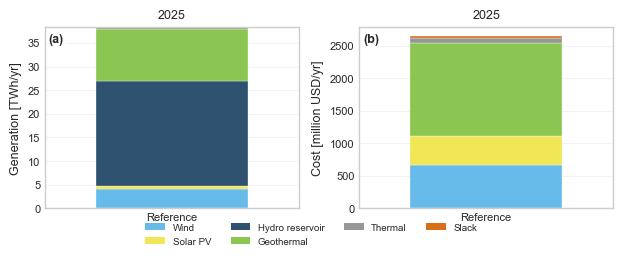

In [41]:
# Cross-scenario generation and cost figure
preferred_comparison_years = [2030, 2050]
comparison_years = [
    year for year in preferred_comparison_years
    if year in years
]
if not comparison_years:
    comparison_years = sorted(years)

def _norm_carrier(x):
    return str(x).strip().lower().replace(" ", "_").replace("-", "_")


def format_scenario_axis(ax, x, labels):
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=0, ha="center", fontsize=7)
    ax.tick_params(axis="x", pad=3)


def build_generation_group_df(df_year):
    """
    Annual electricity generation / dispatch by broad technology group [TWh/yr].

    Reconstructed directly from each optimized PyPSA network.
    """
    out = pd.DataFrame(0.0, index=df_year.index, columns=TECH_GROUPS)

    for idx, row in df_year.iterrows():
        scenario_code = row["scenario"]
        year = int(row["year"])
        net = scenario_results[scenario_code]["results"][year]["network"]

        try:
            weights = pd.Series(net.snapshot_weightings.objective, index=net.snapshots).astype(float)
        except Exception:
            weights = pd.Series(1.0, index=net.snapshots)

        # Generators
        if hasattr(net, "generators") and len(net.generators) > 0:
            p_gen = net.generators_t.p.reindex(columns=net.generators.index, fill_value=0.0).clip(lower=0.0)

            for asset in net.generators.index:
                carrier = _norm_carrier(net.generators.loc[asset, "carrier"]) if "carrier" in net.generators.columns else ""
                group = GENERATOR_CARRIER_GROUP.get(carrier)

                energy_mwh = float((p_gen[asset] * weights).sum())

                if energy_mwh <= 1e-6:
                    continue

                if group is None:
                    group = "Other"

                out.loc[idx, group] += energy_mwh / 1e6

        # Storage-unit discharge
        if hasattr(net, "storage_units") and len(net.storage_units) > 0:
            p_su = net.storage_units_t.p.reindex(columns=net.storage_units.index, fill_value=0.0).clip(lower=0.0)

            for asset in net.storage_units.index:
                carrier = _norm_carrier(net.storage_units.loc[asset, "carrier"]) if "carrier" in net.storage_units.columns else ""
                group = storage_unit_group(net.storage_units, asset)

                energy_mwh = float((p_su[asset] * weights).sum())

                if energy_mwh <= 1e-6:
                    continue

                if group is None:
                    group = "Other"

                out.loc[idx, group] += energy_mwh / 1e6

        # Electricity-producing links
        if hasattr(net, "links") and len(net.links) > 0:
            for asset in net.links.index:
                carrier = _norm_carrier(net.links.loc[asset, "carrier"]) if "carrier" in net.links.columns else ""
                group = ELECTRICITY_OUTPUT_LINK_GROUP.get(carrier)

                if group is None:
                    continue

                # Link outputs are negative at output ports in PyPSA.
                output_candidates = []

                for port in ["p1", "p2", "p3", "p4"]:
                    if hasattr(net.links_t, port):
                        p = getattr(net.links_t, port)
                        if asset in p.columns:
                            s = (-p[asset]).clip(lower=0.0)
                            output_candidates.append(s)

                if not output_candidates:
                    continue

                output = max(output_candidates, key=lambda s: float((s * weights).sum()))
                energy_mwh = float((output * weights).sum())

                if energy_mwh <= 1e-6:
                    continue

                out.loc[idx, group] += energy_mwh / 1e6

    return out[TECH_GROUPS]


def build_cost_group_df(df_year):
    """
    Build system cost by broad technology group [million USD/yr],
    reconstructed directly from scenario_results.
    """
    out = pd.DataFrame(0.0, index=df_year.index, columns=TECH_GROUPS)

    for idx, row in df_year.iterrows():
        scenario_code = row["scenario"]
        year = int(row["year"])

        net = scenario_results[scenario_code]["results"][year]["network"]
        costs = estimate_cost_breakdown_from_network(net)
        if costs.empty:
            continue

        grouped = costs.groupby("group")["total_cost"].sum()

        for group, value in grouped.items():
            if group not in out.columns:
                out.loc[idx, "Other"] += float(value)
            else:
                out.loc[idx, group] += float(value)

    return out[TECH_GROUPS] / 1e6


def plot_stacked_bars(ax, stack_df, groups, colors, labels, ylabel):
    """Plot a stacked bar chart and return the displayed groups."""
    x = np.arange(len(stack_df))
    bottom = np.zeros(len(stack_df))
    plotted_groups = []

    for group in groups:
        if group not in stack_df.columns:
            continue
        values = stack_df[group].fillna(0.0).values
        if np.allclose(values.sum(), 0.0):
            continue
        ax.bar(
            x,
            values,
            bottom=bottom,
            width=0.78,
            color=colors.get(group, "#999999"),
            alpha=0.90,
            label=group,
            edgecolor="white",
            linewidth=0.25,
        )
        bottom += values
        plotted_groups.append(group)

    format_scenario_axis(ax, x, labels)
    finish_axis(ax, ylabel=ylabel)
    ax.grid(False)
    ax.yaxis.grid(True, alpha=0.22)
    ax.set_axisbelow(True)
    ax.set_xlim(-0.65, len(stack_df) - 0.35)
    return plotted_groups


if not comparison_years:
    raise ValueError("None of the requested comparison years are available.")

nrows = len(comparison_years)
fig, axes = plt.subplots(
    nrows,
    2,
    figsize=(WORD_DOUBLE_COL_IN, 2.45 * nrows),
    squeeze=False,
)

used_groups = set()

for row_i, year in enumerate(comparison_years):
    df_y = scenario_comparison[scenario_comparison["year"] == year].copy()

    df_y = df_y[df_y["scenario"].isin(SCENARIO_TECH_LABELS.keys())].copy()

    if df_y.empty:
        raise ValueError(f"No selected scenarios found for year {year}.")

    df_y["_order"] = df_y["scenario"].map(SCENARIO_ORDER_RANK)
    df_y = df_y.sort_values("_order").drop(columns="_order").reset_index(drop=True)

    df_y["label"] = df_y["scenario"].map(SCENARIO_TECH_LABELS).fillna(df_y["scenario"].astype(str))

    generation_group_df = build_generation_group_df(df_y)
    cost_group_df = build_cost_group_df(df_y)

    ax_gen = axes[row_i, 0]
    groups = plot_stacked_bars(
        ax_gen,
        generation_group_df,
        TECH_GROUPS,
        TECH_COLORS_GROUPED,
        df_y["label"].tolist(),
        ylabel="Generation [TWh/yr]",
    )
    used_groups.update(groups)
    panel_label(ax_gen, f"({chr(97 + 2 * row_i)})")
    ax_gen.text(
        0.5,
        1.03,
        str(year),
        transform=ax_gen.transAxes,
        ha="center",
        va="bottom",
        fontsize=9,
        clip_on=False,
    )

    ax_cost = axes[row_i, 1]
    groups = plot_stacked_bars(
        ax_cost,
        cost_group_df,
        TECH_GROUPS,
        TECH_COLORS_GROUPED,
        df_y["label"].tolist(),
        ylabel=COST_AXIS_LABEL,
    )
    used_groups.update(groups)
    panel_label(ax_cost, f"({chr(98 + 2 * row_i)})")
    ax_cost.text(
        0.5,
        1.03,
        str(year),
        transform=ax_cost.transAxes,
        ha="center",
        va="bottom",
        fontsize=9,
        clip_on=False,
    )


# Shared legend
legend_handles = []
legend_labels = []

for group in TECH_GROUPS:
    if group not in used_groups:
        continue

    handle = plt.Rectangle(
        (0, 0),
        1,
        1,
        facecolor=TECH_COLORS_GROUPED.get(group, "#999999"),
        edgecolor="none",
        alpha=0.90,
    )
    legend_handles.append(handle)
    legend_labels.append(group)

fig.legend(
    legend_handles,
    legend_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=4,
    frameon=False,
    fontsize=7,
)

plt.tight_layout()
fig.subplots_adjust(top=0.94, bottom=0.20 if nrows == 1 else 0.14, hspace=0.28, wspace=0.24)

years_tag = "_".join(str(year) for year in comparison_years)
fig_path = save_paper_figure(
    fig,
    f"figure_cross_scenario_generation_cost_{years_tag}.png",
)
plt.show()


Saved figure: output\output_new_zealand\figures\cross_scenario_all_years\figure_supp_cross_scenario_decomposition_2025.png


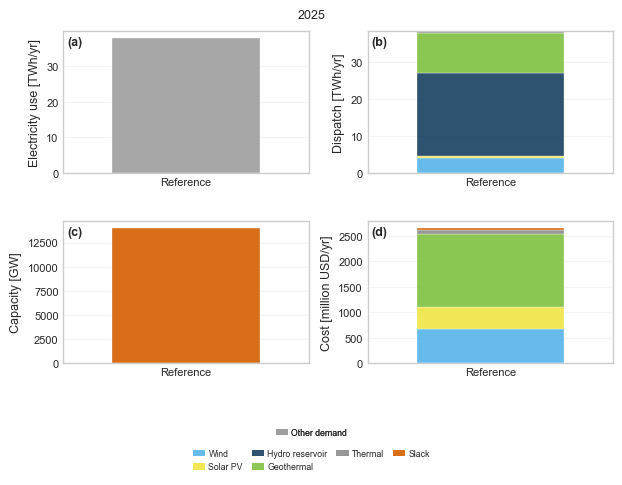

In [42]:
# Supplementary cross-scenario decomposition
required_plot_helpers = [
    "column_or_zero",
    "clean_technology_group",
    "sum_metric_by_group",
]
missing_plot_helpers = [
    name for name in required_plot_helpers
    if name not in globals()
]
if missing_plot_helpers:
    raise RuntimeError(
        "Run the configuration/helper cell before this figure. "
        f"Missing helpers: {missing_plot_helpers}"
    )

cross_scenario_years_to_plot = years
cross_scenario_export_dir = PAPER_FIGURE_DIR / "cross_scenario_all_years"
cross_scenario_export_dir.mkdir(parents=True, exist_ok=True)


def build_demand_group_df(df_year):
    """Build electricity-use decomposition [TWh/yr]."""
    out = pd.DataFrame(index=df_year.index)

    if demand_breakdown_summary.empty:
        raise ValueError("Demand breakdown is empty. Run the previous section first.")

    demand_y = demand_breakdown_summary[
        demand_breakdown_summary["year"] == int(df_year["year"].iloc[0])
    ].copy()
    demand_y = apply_scenario_order(demand_y)
    demand_y = demand_y.set_index("scenario").reindex(df_year["scenario"])

    mapping = {
        "Base load": "demand_base_load_mwh",
        "Heating": "demand_heating_mwh",
        "EVs": "demand_ev_mwh",
        "Cooking": "demand_cooking_mwh",
        "Process electrification": "demand_process_electrification_mwh",
        "Electrolyser": "electrolyser_input_mwh",
        "PtX auxiliaries": "ptx_aux_electricity_mwh",
        "Other local demand": "demand_other_mwh",
    }

    for group, col in mapping.items():
        if col in demand_y.columns:
            out[group] = demand_y[col].fillna(0.0).values / 1e6
        else:
            out[group] = 0.0

    for group in DEMAND_GROUPS:
        if group not in out.columns:
            out[group] = 0.0

    return out[DEMAND_GROUPS]


def _generator_metric_by_group(df_year, prefix, suffix, group):
    """Sum dynamic carrier columns assigned to one NZ technology group."""
    selected = []
    for column in df_year.columns:
        if not (str(column).startswith(prefix) and str(column).endswith(suffix)):
            continue
        carrier = _norm_carrier(
            str(column)[len(prefix):len(column) - len(suffix)]
        )
        mapped_group = clean_technology_group(carrier)
        if mapped_group == group:
            selected.append(column)

    if not selected:
        return pd.Series(0.0, index=df_year.index, dtype=float)

    return (
        df_year[selected]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0.0)
        .sum(axis=1)
    )


def build_dispatch_group_df(df_year):
    """Build annual electricity dispatch by NZ technology [TWh/yr]."""
    out = pd.DataFrame(index=df_year.index)

    for group in ["Wind", "Solar PV", *HYDRO_GROUPS, "Geothermal", "Thermal", "Slack", "Other"]:
        out[group] = (
            _generator_metric_by_group(
                df_year,
                prefix="generation_",
                suffix="_mwh",
                group=group,
            )
            / 1e6
        )

    out["BESS"] = column_or_zero(df_year, "bess_discharge_mwh") / 1e6

    if "h2_to_power_mwh" in df_year.columns:
        out["Hydrogen"] = column_or_zero(df_year, "h2_to_power_mwh") / 1e6
    else:
        out["Hydrogen"] = (
            column_or_zero(df_year, "h2_fuel_cell_output_mwh")
            + column_or_zero(df_year, "h2_turbine_output_mwh")
        ) / 1e6

    for group in TECH_GROUPS:
        if group not in out.columns:
            out[group] = 0.0

    return out[TECH_GROUPS]

def build_capacity_group_df(df_year):
    """Build installed power capacity by NZ technology [GW]."""
    out = pd.DataFrame(index=df_year.index)

    for group in ["Wind", "Solar PV", *HYDRO_GROUPS, "Geothermal", "Thermal", "Slack", "Other"]:
        out[group] = (
            _generator_metric_by_group(
                df_year,
                prefix="cap_",
                suffix="_mw",
                group=group,
            )
            / 1e3
        )

    out["BESS"] = column_or_zero(df_year, "cap_bess_mw") / 1e3

    hydrogen_columns = [
        "linkcap_electrolyzer_mw",
        "linkcap_h2_fuel_cell_mw",
        "linkcap_h2_turbine_mw",
    ]
    valid_hydrogen_columns = [
        column for column in hydrogen_columns if column in df_year.columns
    ]
    out["Hydrogen"] = (
        df_year[valid_hydrogen_columns]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0.0)
        .sum(axis=1)
        / 1e3
        if valid_hydrogen_columns
        else 0.0
    )

    for group in TECH_GROUPS:
        if group not in out.columns:
            out[group] = 0.0

    return out[TECH_GROUPS]

def plot_cross_scenario_supplementary(comparison_year, save_figure=True, show_figure=True):
    df_y = scenario_comparison[scenario_comparison["year"] == comparison_year].copy()

    if df_y.empty:
        raise ValueError(f"No scenario comparison data found for {comparison_year}.")

    df_y = apply_scenario_order(df_y).reset_index(drop=True)
    df_y["label"] = df_y["scenario"].map(SCENARIO_TECH_LABELS).fillna(df_y["scenario"].astype(str))

    demand_group_df = build_demand_group_df(df_y)
    dispatch_group_df = build_dispatch_group_df(df_y)
    capacity_group_df = build_capacity_group_df(df_y)
    cost_group_df = build_cost_group_df(df_y)

    fig, axes = plt.subplots(2, 2, figsize=FIGSIZE_PAPER_2X2)

    used_demand_groups = set()
    used_tech_groups = set()

    used = plot_stacked_bars(
        axes[0, 0],
        demand_group_df,
        DEMAND_GROUPS,
        DEMAND_COLORS_GROUPED,
        df_y["label"].tolist(),
        ylabel="Electricity use [TWh/yr]",
    )
    used_demand_groups.update(used)
    panel_label(axes[0, 0], "(a)")

    used = plot_stacked_bars(
        axes[0, 1],
        dispatch_group_df,
        TECH_GROUPS,
        TECH_COLORS_GROUPED,
        df_y["label"].tolist(),
        ylabel="Dispatch [TWh/yr]",
    )
    used_tech_groups.update(used)
    panel_label(axes[0, 1], "(b)")

    used = plot_stacked_bars(
        axes[1, 0],
        capacity_group_df,
        TECH_GROUPS,
        TECH_COLORS_GROUPED,
        df_y["label"].tolist(),
        ylabel="Capacity [GW]",
    )
    used_tech_groups.update(used)
    panel_label(axes[1, 0], "(c)")

    used = plot_stacked_bars(
        axes[1, 1],
        cost_group_df,
        TECH_GROUPS,
        TECH_COLORS_GROUPED,
        df_y["label"].tolist(),
        ylabel=COST_AXIS_LABEL,
    )
    used_tech_groups.update(used)
    panel_label(axes[1, 1], "(d)")

    fig.text(
        0.5,
        0.975,
        str(comparison_year),
        ha="center",
        va="top",
        fontsize=9,
    )

    # Figure-level legends
    demand_handles = []
    demand_labels = []
    for group in DEMAND_GROUPS:
        if group not in used_demand_groups:
            continue

        demand_handles.append(
            plt.Rectangle(
                (0, 0), 1, 1,
                facecolor=DEMAND_COLORS_GROUPED.get(group, "#999999"),
                edgecolor="none",
                alpha=0.90,
            )
        )
        demand_labels.append(DEMAND_LEGEND_LABELS.get(group, group))

    tech_handles = []
    tech_labels = []

    for group in TECH_GROUPS:
        if group not in used_tech_groups:
            continue

        tech_handles.append(
            plt.Rectangle(
                (0, 0), 1, 1,
                facecolor=TECH_COLORS_GROUPED.get(group, "#999999"),
                edgecolor="none",
                alpha=0.90,
            )
        )
        tech_labels.append(TECH_LEGEND_LABELS.get(group, group))

    leg1 = fig.legend(
        demand_handles,
        demand_labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.095),
        ncol=4,
        frameon=False,
        fontsize=6.3,
        columnspacing=1.0,
        handlelength=1.4,
        handletextpad=0.4,
    )
    fig.add_artist(leg1)

    fig.legend(
        tech_handles,
        tech_labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.025),
        ncol=4,
        frameon=False,
        fontsize=6.3,
        columnspacing=1.0,
        handlelength=1.4,
        handletextpad=0.4,
    )
    plt.tight_layout()
    fig.subplots_adjust(top=0.93, bottom=0.26, hspace=0.34, wspace=0.24)

    out_path = None
    if save_figure:
        out_path = save_paper_figure(
            fig,
            f"figure_supp_cross_scenario_decomposition_{comparison_year}.png",
            folder=cross_scenario_export_dir,
        )

    if show_figure:
        plt.show()
    else:
        plt.close(fig)

    return out_path


for comparison_year in cross_scenario_years_to_plot:
    plot_cross_scenario_supplementary(comparison_year)


In [43]:
# Former Figure 6 retired: retain only reliability indicators
#
# Storage/flexibility capacity and operation are now reported in the table
# exported by Figure 5 and in each scenario's *_bess_by_year.csv file.
comparison_year = detailed_year
df_y = scenario_comparison[scenario_comparison["year"] == comparison_year].copy()
if df_y.empty:
    raise ValueError(f"No scenario comparison data found for {comparison_year}.")
df_y = apply_scenario_order(df_y).reset_index(drop=True)

reliability_check = pd.DataFrame({
    "scenario": df_y["scenario"],
    "paper_id": df_y["paper_id"] if "paper_id" in df_y.columns else "",
    "year": df_y["year"],
    "slack_generation_gwh": df_y["slack_generation_mwh"].fillna(0.0) / 1e3,
    "curtailment_gwh": df_y["curtailment_total_mwh"].fillna(0.0) / 1e3,
})
display(reliability_check.round(3))


,scenario,paper_id,year,slack_generation_gwh,curtailment_gwh
0,reference,Reference,2025,0.384,5.017


Saved figure: output\output_new_zealand\figures\cross_scenario_all_years\figure05_system_design_2025.png
Saved figure: output\output_new_zealand\figures\cross_scenario_all_years\figure05_system_design_2025.svg
Saved figure: output\output_new_zealand\figures\cross_scenario_all_years\figure05_system_design_2025.pdf


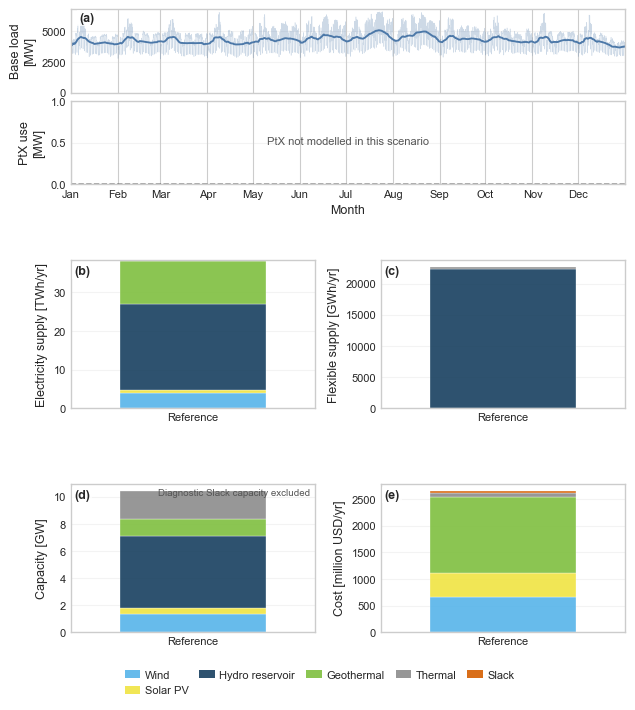

,Scenario,Thermal generation [GWh/yr],BESS discharge [GWh/yr],BESS power capacity [MW],BESS energy capacity [GWh],BESS duration [h],H2-to-power output [GWh/yr],H2 tank/other capacity [GWh],UHS capacity [GWh],BESS equivalent cycles [1/yr]
0,Reference,334.409,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Saved flexibility table to: output\output_new_zealand\tables\table_flexibility_requirements_2025.csv


In [44]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure 5 — Demand, electricity supply, flexibility, capacity, and cost
#
# (a) Hourly local-demand components and PtX electricity use
# (b) Annual electricity supply
# (c) Annual flexible electricity supply
# (d) Installed power capacity
# (e) Annual system cost
#
# The former Figure 6 is exported below as a numerical table.
# ─────────────────────────────────────────────────────────────────────────────

import matplotlib.dates as mdates


# ── Configuration ────────────────────────────────────────────────────────────
comparison_year = detailed_year

figure5_export_dir = (
    PAPER_FIGURE_DIR
    / "cross_scenario_all_years"
)

figure5_export_dir.mkdir(
    parents=True,
    exist_ok=True,
)

# Use a PtX-enabled case when available; otherwise show the active reference case.
profile_scenario = next(
    (
        scenario_code
        for scenario_code, package in scenario_results.items()
        if package.get("metadata", {}).get("enable_ptx", False)
    ),
    active_scenario,
)


# ── Validation and scenario ordering ─────────────────────────────────────────
df_y = scenario_comparison[
    scenario_comparison["year"] == comparison_year
].copy()

if df_y.empty:
    raise ValueError(
        f"No scenario comparison data found for {comparison_year}."
    )

df_y = (
    apply_scenario_order(df_y)
    .reset_index(drop=True)
)

df_y["label"] = (
    df_y["scenario"]
    .map(SCENARIO_TECH_LABELS)
    .fillna(
        df_y["scenario"]
        .astype(str)
        .str.replace("_", " ", regex=False)
    )
)


# ── General helpers ──────────────────────────────────────────────────────────
def column_or_zero(df, column):
    """Return a numeric dataframe column or an aligned zero-valued Series."""
    if column in df.columns:
        return pd.to_numeric(df[column], errors="coerce").fillna(0.0)

    return pd.Series(0.0, index=df.index, dtype=float)


def link_input_series(net, carriers):
    """Aggregate positive p0 electricity input for selected links [MW]."""
    snapshots = pd.Index(net.snapshots)

    if (
        len(net.links) == 0
        or not hasattr(net.links_t, "p0")
    ):
        return pd.Series(
            0.0,
            index=snapshots,
        )

    carriers = set(carriers)

    selected_links = net.links.index[
        net.links["carrier"]
        .astype(str)
        .isin(carriers)
    ]

    if len(selected_links) == 0:
        return pd.Series(
            0.0,
            index=snapshots,
        )

    return (
        net.links_t.p0
        .reindex(
            index=snapshots,
            columns=selected_links,
            fill_value=0.0,
        )
        .clip(lower=0.0)
        .sum(axis=1)
    )


def _generator_metric_by_group(df_year, prefix, suffix, group):
    """Sum dynamic carrier columns assigned to one NZ technology group."""
    selected = []
    for column in df_year.columns:
        if not (str(column).startswith(prefix) and str(column).endswith(suffix)):
            continue
        carrier = _norm_carrier(
            str(column)[len(prefix):len(column) - len(suffix)]
        )
        mapped_group = clean_technology_group(carrier)
        if mapped_group == group:
            selected.append(column)

    if not selected:
        return pd.Series(0.0, index=df_year.index, dtype=float)

    return (
        df_year[selected]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0.0)
        .sum(axis=1)
    )


# ── Annual electricity supply ────────────────────────────────────────────────
def build_dispatch_group_df(df_year):
    """Build annual electricity dispatch by NZ technology [TWh/yr]."""
    out = pd.DataFrame(index=df_year.index)

    for group in ["Wind", "Solar PV", *HYDRO_GROUPS, "Geothermal", "Thermal", "Slack", "Other"]:
        out[group] = (
            _generator_metric_by_group(
                df_year,
                prefix="generation_",
                suffix="_mwh",
                group=group,
            )
            / 1e6
        )

    out["BESS"] = column_or_zero(df_year, "bess_discharge_mwh") / 1e6

    if "h2_to_power_mwh" in df_year.columns:
        out["Hydrogen"] = column_or_zero(df_year, "h2_to_power_mwh") / 1e6
    else:
        out["Hydrogen"] = (
            column_or_zero(df_year, "h2_fuel_cell_output_mwh")
            + column_or_zero(df_year, "h2_turbine_output_mwh")
        ) / 1e6

    for group in TECH_GROUPS:
        if group not in out.columns:
            out[group] = 0.0

    return out[TECH_GROUPS]

# ── Annual flexible electricity supply ──────────────────────────────────────
FLEXIBILITY_GROUPS = [
    "Hydro reservoir",
    "Thermal",
    "BESS",
    "Hydrogen",
]

# Diagnostic Slack has intentionally large nominal capacity and is therefore
# excluded only from the installed-capacity panel. Its generation and cost
# remain visible in the corresponding panels and summary tables.
CAPACITY_GROUPS = [
    group for group in TECH_GROUPS
    if group != "Slack"
]


def build_flexibility_group_df(df_year):
    """Build annual flexible electricity supply [GWh/yr]."""
    out = pd.DataFrame(index=df_year.index)

    out["Hydro reservoir"] = (
        _generator_metric_by_group(
            df_year,
            prefix="generation_",
            suffix="_mwh",
            group="Hydro reservoir",
        )
        / 1e3
    )
    out["Thermal"] = (
        _generator_metric_by_group(
            df_year,
            prefix="generation_",
            suffix="_mwh",
            group="Thermal",
        )
        / 1e3
    )
    out["BESS"] = column_or_zero(df_year, "bess_discharge_mwh") / 1e3
    out["Hydrogen"] = column_or_zero(df_year, "h2_to_power_mwh") / 1e3

    return out[FLEXIBILITY_GROUPS]


# ── Installed capacity ───────────────────────────────────────────────────────
def build_capacity_group_df(df_year):
    """Build installed power capacity by NZ technology [GW]."""
    out = pd.DataFrame(index=df_year.index)

    for group in ["Wind", "Solar PV", *HYDRO_GROUPS, "Geothermal", "Thermal", "Slack", "Other"]:
        out[group] = (
            _generator_metric_by_group(
                df_year,
                prefix="cap_",
                suffix="_mw",
                group=group,
            )
            / 1e3
        )

    out["BESS"] = column_or_zero(df_year, "cap_bess_mw") / 1e3

    hydrogen_columns = [
        "linkcap_electrolyzer_mw",
        "linkcap_h2_fuel_cell_mw",
        "linkcap_h2_turbine_mw",
    ]
    valid_hydrogen_columns = [
        column for column in hydrogen_columns if column in df_year.columns
    ]
    out["Hydrogen"] = (
        df_year[valid_hydrogen_columns]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0.0)
        .sum(axis=1)
        / 1e3
        if valid_hydrogen_columns
        else 0.0
    )

    for group in TECH_GROUPS:
        if group not in out.columns:
            out[group] = 0.0

    return out[TECH_GROUPS]

# Remove diagnostic Slack from the plotted capacity mix while preserving it in
# scenario_comparison and carrier_diagnostic.
def build_capacity_plot_df(df_year):
    return build_capacity_group_df(df_year)[CAPACITY_GROUPS]

# ── Prepare annual panel data ────────────────────────────────────────────────
dispatch_group_df = build_dispatch_group_df(df_y)
flexibility_group_df = build_flexibility_group_df(df_y)
capacity_group_df = build_capacity_plot_df(df_y)
cost_group_df = build_cost_group_df(df_y)


# ── Prepare hourly demand-component and PtX profiles ─────────────────────────
profile_package = scenario_results[profile_scenario]

if comparison_year not in profile_package["results"]:
    raise ValueError(
        f"{profile_scenario} has no result for {comparison_year}."
    )

profile_result = profile_package["results"][comparison_year]
profile_net = profile_result["network"]


def normalise_profile_index(values):
    """Return a timezone-naive DatetimeIndex for profile alignment."""
    index = pd.DatetimeIndex(
        pd.to_datetime(values)
    )

    if index.tz is not None:
        index = index.tz_localize(None)

    return index


profile_snapshots = normalise_profile_index(
    profile_net.snapshots
)

demand_components_df, demand_components_path, _ = (
    load_demand_components_for_scenario(
        profile_scenario,
        package=profile_package,
    )
)

if (
    demand_components_df.empty
    or "timestamp" not in demand_components_df.columns
    or "year" not in demand_components_df.columns
):
    # NZ reference runs may only export the aggregate electricity load.
    # Use it as one Base-load component so Figure 5 remains self-contained.
    aggregate_load = profile_result["load"].load()
    component_profiles = pd.DataFrame(
        {"base_load": aggregate_load.sum(axis=1).to_numpy()},
        index=aggregate_load.index,
    )
    demand_components_path = Path("aggregate load export")
else:
    component_year = demand_components_df[
        pd.to_numeric(demand_components_df["year"], errors="coerce")
        .eq(int(comparison_year))
    ].copy()

    if component_year.empty:
        aggregate_load = profile_result["load"].load()
        component_profiles = pd.DataFrame(
            {"base_load": aggregate_load.sum(axis=1).to_numpy()},
            index=aggregate_load.index,
        )
        demand_components_path = Path("aggregate load export")
    else:
        component_year["component_key"] = (
            component_year["component"]
            .map(_safe_component_name)
        )
        component_profiles = (
            component_year
            .pivot_table(
                index="timestamp",
                columns="component_key",
                values="demand_mw",
                aggfunc="sum",
                fill_value=0.0,
            )
            .sort_index()
        )

component_profiles.index = normalise_profile_index(
    component_profiles.index
)

# Sum duplicated timestamps, if any, after aggregating zones.
component_profiles = (
    component_profiles
    .groupby(level=0)
    .sum()
    .sort_index()
)

# If the CSV uses another calendar year but preserves the hourly sequence,
# align it by position with the solved network.
if not component_profiles.index.equals(profile_snapshots):
    if len(component_profiles) != len(profile_snapshots):
        raise ValueError(
            "Demand-component profiles cannot be aligned with the solved "
            f"network: {len(component_profiles)} component timestamps versus "
            f"{len(profile_snapshots)} network snapshots."
        )

    component_profiles.index = profile_snapshots

component_profiles = (
    component_profiles
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0.0)
    .clip(lower=0.0)
)

# Stable paper order, followed automatically by any future component.
active_components = [
    component
    for component in component_profiles.columns
    if component_profiles[component].abs().max() > 1e-9
]

preferred_component_order = [
    "base_load",
    "heating",
    "ev",
    "cooking",
    "process_electrification",
    "other",
]

profile_component_order = [
    component
    for component in preferred_component_order
    if component in active_components
]

profile_component_order += sorted(
    component
    for component in active_components
    if component not in profile_component_order
)

if not profile_component_order:
    raise ValueError(
        f"No active electricity-demand components were found for "
        f"{comparison_year} in {demand_components_path}."
    )

component_profiles = component_profiles[
    profile_component_order
]

component_rolling = (
    component_profiles
    .rolling(
        window=168,
        center=True,
        min_periods=24,
    )
    .mean()
)

# PtX remains separate because it is optimised flexible electricity use,
# rather than an exogenous component from demand_components_<scenario>.csv.
electrolyser_use = link_input_series(
    profile_net,
    ["electrolyzer"],
)

ptx_aux_use = link_input_series(
    profile_net,
    ["asu", "dac"],
)

ptx_profile = pd.DataFrame(
    {
        "Electrolyser": electrolyser_use.to_numpy(),
        "PtX auxiliaries": ptx_aux_use.to_numpy(),
    },
    index=profile_snapshots,
)

ptx_profile = (
    ptx_profile
    .sort_index()
    .clip(lower=0.0)
)

ptx_rolling = (
    ptx_profile
    .rolling(
        window=168,
        center=True,
        min_periods=24,
    )
    .mean()
)

ptx_total = (
    ptx_profile["Electrolyser"]
    + ptx_profile["PtX auxiliaries"]
)

ptx_total_rolling = (
    ptx_rolling["Electrolyser"]
    + ptx_rolling["PtX auxiliaries"]
)


# ── Figure layout ────────────────────────────────────────────────────────────
n_profile_axes = len(profile_component_order) + 1
additional_profile_axes = max(0, n_profile_axes - 2)

# Increase figure height as new demand components appear.
figure_height = 7.20 + 0.72 * additional_profile_axes
profile_height_ratio = 1.18 * n_profile_axes / 2.0

fig = plt.figure(
    figsize=(
        WORD_DOUBLE_COL_IN,
        figure_height,
    )
)

outer_gs = fig.add_gridspec(
    nrows=3,
    ncols=2,
    height_ratios=[
        profile_height_ratio,
        1.0,
        1.0,
    ],
    hspace=0.48,
    wspace=0.27,
)

# One strip per local-demand component, followed by a separate PtX strip.
profile_gs = outer_gs[0, :].subgridspec(
    nrows=n_profile_axes,
    ncols=1,
    height_ratios=[1.0] * n_profile_axes,
    hspace=0.10,
)

profile_axes = []

for row_index in range(len(profile_component_order)):
    axis = fig.add_subplot(
        profile_gs[row_index, 0],
        sharex=profile_axes[0] if profile_axes else None,
    )
    profile_axes.append(axis)

ax_a_ptx = fig.add_subplot(
    profile_gs[-1, 0],
    sharex=profile_axes[0],
)

ax_b = fig.add_subplot(outer_gs[1, 0])
ax_c = fig.add_subplot(outer_gs[1, 1])
ax_d = fig.add_subplot(outer_gs[2, 0])
ax_e = fig.add_subplot(outer_gs[2, 1])


# ── (a) Hourly local-demand components and PtX electricity use ───────────────
electrolyser_color = DEMAND_COLORS_GROUPED.get(
    "Electrolyser",
    TECH_COLORS.get(
        "electrolyzer",
        "#00897b",
    ),
)

ptx_aux_color = DEMAND_COLORS_GROUPED.get(
    "PtX auxiliaries",
    TECH_COLORS.get(
        "asu",
        "#80cbc4",
    ),
)

fallback_component_colors = plt.get_cmap("tab10")

for component_index, (axis, component) in enumerate(
    zip(
        profile_axes,
        profile_component_order,
    )
):
    component_label = DEMAND_COMPONENT_LABELS.get(
        component,
        component.replace("_", " ").title(),
    )

    component_color = DEMAND_COMPONENT_COLORS.get(
        component,
        fallback_component_colors(
            component_index % 10
        ),
    )

    # Thin line: hourly profile.
    axis.plot(
        component_profiles.index,
        component_profiles[component],
        color=component_color,
        linewidth=0.35,
        alpha=0.28,
    )

    # Thick line: seven-day rolling average.
    axis.plot(
        component_rolling.index,
        component_rolling[component],
        color=component_color,
        linewidth=1.35,
    )

    axis.set_ylabel(
        f"{component_label}\n[MW]"
    )

    axis.set_ylim(bottom=0.0)

    axis.grid(
        axis="y",
        alpha=0.22,
    )

    axis.set_axisbelow(True)

    axis.tick_params(
        axis="x",
        labelbottom=False,
    )

panel_label(
    profile_axes[0],
    "(a)",
)

# PtX electricity use: stacked hourly areas and seven-day total mean.
ax_a_ptx.fill_between(
    ptx_profile.index,
    0.0,
    ptx_profile["Electrolyser"],
    color=electrolyser_color,
    alpha=0.82,
    linewidth=0.0,
    step="mid",
    label="Electrolyser",
)

ax_a_ptx.fill_between(
    ptx_profile.index,
    ptx_profile["Electrolyser"],
    ptx_total,
    color=ptx_aux_color,
    alpha=0.82,
    linewidth=0.0,
    step="mid",
    label="PtX auxiliaries",
)

ax_a_ptx.plot(
    ptx_total_rolling.index,
    ptx_total_rolling,
    color="black",
    linewidth=1.05,
    linestyle="--",
    label="Total PtX: 7-day mean",
)

ax_a_ptx.set_ylabel(
    "PtX use\n[MW]"
)

ax_a_ptx.set_ylim(bottom=0.0)

ax_a_ptx.set_xlabel(
    "Month"
)

ax_a_ptx.grid(
    axis="y",
    alpha=0.22,
)

ax_a_ptx.set_axisbelow(True)

ax_a_ptx.xaxis.set_major_locator(
    mdates.MonthLocator()
)

ax_a_ptx.xaxis.set_major_formatter(
    mdates.DateFormatter("%b")
)

ax_a_ptx.set_xlim(
    profile_snapshots.min(),
    profile_snapshots.max(),
)

if float(ptx_total.max()) > 1e-6:
    ax_a_ptx.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.36),
        ncol=3,
        frameon=False,
        fontsize=FONT_SIZE_SMALL,
        columnspacing=1.1,
        handlelength=1.5,
        handletextpad=0.4,
    )
else:
    # Keep the PtX panel in the workflow, but make the inactive case explicit
    # instead of showing a misleading 0.00–0.04 MW axis and zero-value legend.
    ax_a_ptx.set_ylim(0.0, 1.0)
    ax_a_ptx.text(
        0.5,
        0.52,
        "PtX not modelled in this scenario",
        transform=ax_a_ptx.transAxes,
        ha="center",
        va="center",
        fontsize=FONT_SIZE_SMALL,
        color="#555555",
    )


# ── (b) Annual electricity supply ───────────────────────────────────────────
used_tech_groups = set()

used = plot_stacked_bars(
    ax_b,
    dispatch_group_df,
    TECH_GROUPS,
    TECH_COLORS_GROUPED,
    df_y["label"].tolist(),
    ylabel="Electricity supply [TWh/yr]",
)

used_tech_groups.update(used)

panel_label(
    ax_b,
    "(b)",
)


# ── (c) Annual flexible electricity supply ──────────────────────────────────
used = plot_stacked_bars(
    ax_c,
    flexibility_group_df,
    FLEXIBILITY_GROUPS,
    TECH_COLORS_GROUPED,
    df_y["label"].tolist(),
    ylabel="Flexible supply [GWh/yr]",
)

used_tech_groups.update(used)

panel_label(
    ax_c,
    "(c)",
)


# ── (d) Installed power capacity ─────────────────────────────────────────────
used = plot_stacked_bars(
    ax_d,
    capacity_group_df,
    CAPACITY_GROUPS,
    TECH_COLORS_GROUPED,
    df_y["label"].tolist(),
    ylabel="Capacity [GW]",
)

used_tech_groups.update(used)

panel_label(
    ax_d,
    "(d)",
)
ax_d.text(
    0.98,
    0.97,
    "Diagnostic Slack capacity excluded",
    transform=ax_d.transAxes,
    ha="right",
    va="top",
    fontsize=FONT_SIZE_SMALL - 1,
    color="#555555",
)


# ── (e) Annual system cost ───────────────────────────────────────────────────
used = plot_stacked_bars(
    ax_e,
    cost_group_df,
    TECH_GROUPS,
    TECH_COLORS_GROUPED,
    df_y["label"].tolist(),
    ylabel=COST_AXIS_LABEL,
)

used_tech_groups.update(used)

panel_label(
    ax_e,
    "(e)",
)


# ── Shared technology legend ─────────────────────────────────────────────────
tech_handles = []
tech_labels = []

for group in TECH_GROUPS:
    if group not in used_tech_groups:
        continue

    tech_handles.append(
        plt.Rectangle(
            (0, 0),
            1,
            1,
            facecolor=TECH_COLORS_GROUPED.get(
                group,
                "#999999",
            ),
            edgecolor="none",
            alpha=0.90,
        )
    )

    tech_labels.append(
        TECH_LEGEND_LABELS.get(
            group,
            group,
        )
    )

fig.legend(
    tech_handles,
    tech_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.018),
    ncol=5,
    frameon=False,
    fontsize=FONT_SIZE_SMALL,
    columnspacing=1.0,
    handlelength=1.4,
    handletextpad=0.4,
)


# ── Final figure spacing ─────────────────────────────────────────────────────
fig.subplots_adjust(
    top=0.985,
    bottom=0.12,
    left=0.105,
    right=0.985,
)


# ── Export Figure 5 ──────────────────────────────────────────────────────────
figure5_paths = []

for extension in [
    "png",
    "svg",
    "pdf",
]:
    figure5_paths.append(
        save_paper_figure(
            fig,
            (
                f"figure05_system_design_"
                f"{comparison_year}.{extension}"
            ),
            folder=figure5_export_dir,
        )
    )

plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# Table replacing the former Figure 6
# ─────────────────────────────────────────────────────────────────────────────
bess_power_mw = column_or_zero(
    df_y,
    "cap_bess_mw",
)

bess_energy_mwh = column_or_zero(
    df_y,
    "energy_bess_mwh",
)

bess_duration_h = (
    bess_energy_mwh
    .div(
        bess_power_mw.replace(
            0.0,
            np.nan,
        )
    )
    .fillna(0.0)
)

flexibility_table = pd.DataFrame(
    {
        "Scenario": df_y["label"],
        "Thermal generation [GWh/yr]": (
            column_or_zero(
                df_y,
                "thermal_generation_mwh",
            )
            / 1e3
        ),
        "BESS discharge [GWh/yr]": (
            column_or_zero(
                df_y,
                "bess_discharge_mwh",
            )
            / 1e3
        ),
        "BESS power capacity [MW]": bess_power_mw,
        "BESS energy capacity [GWh]": (
            bess_energy_mwh
            / 1e3
        ),
        "BESS duration [h]": bess_duration_h,
        "H2-to-power output [GWh/yr]": (
            column_or_zero(
                df_y,
                "h2_to_power_mwh",
            )
            / 1e3
        ),
        "H2 tank/other capacity [GWh]": (
            column_or_zero(
                df_y,
                "h2_storage_total_mwh",
            )
            / 1e3
        ),
        "UHS capacity [GWh]": (
            column_or_zero(
                df_y,
                "uhs_storage_total_mwh",
            )
            / 1e3
        ),
    }
)

flexibility_table["BESS equivalent cycles [1/yr]"] = (
    flexibility_table["BESS discharge [GWh/yr]"]
    .div(
        flexibility_table["BESS energy capacity [GWh]"]
        .replace(0.0, np.nan)
    )
    .fillna(0.0)
)

flexibility_table_path = (
    TABLE_EXPORT_DIR
    / f"table_flexibility_requirements_{comparison_year}.csv"
)

flexibility_table.to_csv(
    flexibility_table_path,
    index=False,
)

display(
    flexibility_table.round(3)
)

print(
    f"Saved flexibility table to: "
    f"{flexibility_table_path}"
)

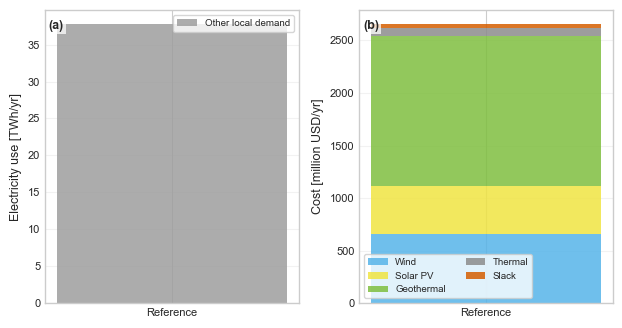

In [45]:
# Demand and cost decomposition figure
if demand_breakdown_summary.empty:
    raise ValueError("Run the demand/cost breakdown cell first.")

demand_y = apply_scenario_order(demand_breakdown_summary[demand_breakdown_summary["year"] == breakdown_year])
demand_y["label"] = [scenario_axis_label(s) for s in demand_y["scenario"]]

x = np.arange(len(demand_y))
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_2COL)

# (a) Electricity-use decomposition from demand_profiles_scenarios + PtX link use
ax = axes[0]
component_stack = [
    ("demand_base_load_mwh", "Base load", DEMAND_COMPONENT_COLORS.get("base_load", "#4c78a8")),
    ("demand_heating_mwh", "Heating", DEMAND_COMPONENT_COLORS.get("heating", "#f58518")),
    ("demand_ev_mwh", "EVs", DEMAND_COMPONENT_COLORS.get("ev", "#54a24b")),
    ("demand_cooking_mwh", "Cooking", DEMAND_COMPONENT_COLORS.get("cooking", "#b279a2")),
    ("demand_process_electrification_mwh", "Process electrification", DEMAND_COMPONENT_COLORS.get("process_electrification", "#e45756")),
    ("demand_other_mwh", "Other local demand", DEMAND_COMPONENT_COLORS.get("other", "#9e9e9e")),
    ("electrolyser_input_mwh", "Electrolyser", DEMAND_COMPONENT_COLORS.get("electrolyser", TECH_COLORS.get("electrolyzer", "#00897b"))),
    ("ptx_aux_electricity_mwh", "PtX auxiliaries", DEMAND_COMPONENT_COLORS.get("ptx_aux", TECH_COLORS.get("asu", "#80cbc4"))),
]
component_stack = [
    item for item in component_stack
    if item[0] in demand_y.columns and demand_y[item[0]].fillna(0).sum() > 1e-6
]

bottom = np.zeros(len(demand_y))
for col, label, color in component_stack:
    vals = demand_y[col].fillna(0).values / 1e6
    ax.bar(x, vals, bottom=bottom, label=label, color=color, alpha=0.85)
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(demand_y["label"], rotation=0, ha="center")
finish_axis(ax, ylabel="Electricity use [TWh/yr]")
ax.legend(frameon=True, ncol=2, fontsize=7)
panel_label(ax, "(a)")

# (b) Approximate cost decomposition
ax = axes[1]
if cost_breakdown_summary.empty:
    ax.text(0.5, 0.5, "No cost breakdown available", ha="center", va="center", transform=ax.transAxes)
else:
    cost_y = cost_breakdown_summary[cost_breakdown_summary["year"] == breakdown_year].copy()
    group_order = TECH_GROUPS
    pivot = (
        cost_y.pivot_table(index="scenario", columns="group", values="total_cost", aggfunc="sum")
        .reindex(demand_y["scenario"])
        .fillna(0.0)
    )
    bottom = np.zeros(len(pivot))
    for group in [g for g in group_order if g in pivot.columns and pivot[g].sum() > 0]:
        vals = pivot[group].values / 1e6
        ax.bar(x, vals, bottom=bottom, label=group, color=TECH_COLORS_GROUPED.get(group, "#999999"), alpha=0.85)
        bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(demand_y["label"], rotation=0, ha="center")
finish_axis(ax, ylabel=COST_AXIS_LABEL)
ax.legend(frameon=True, ncol=2, fontsize=7)
panel_label(ax, "(b)")

plt.tight_layout()
plt.show()


## 7. Renewable scarcity and critical-event dispatch

Daily wind and solar capacity factors identify low-renewable periods and the longest simultaneous scarcity event. Dispatch is then reconstructed from the exported CSV files for the same event window across scenarios.

In [46]:
# Renewable-scarcity helper functions

def _prepare_cf_series(cf_df: pd.DataFrame) -> pd.Series:
    """Average capacity-factor profiles across zones."""
    if cf_df is None or cf_df.empty:
        raise ValueError("No capacity-factor data are available.")

    cf = cf_df.copy()
    if not isinstance(cf.index, pd.DatetimeIndex):
        cf.index = pd.to_datetime(cf.index)

    return cf.mean(axis=1)


def _daily_mean_series(cf_series: pd.Series) -> pd.Series:
    return cf_series.resample("D").mean()


def _monthly_max_consecutive_low_days(
    daily_cf: pd.Series,
    threshold: float,
) -> pd.Series:
    month_labels = [
        "Jan", "Feb", "Mar", "Apr", "May", "Jun",
        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
    ]
    result = pd.Series(0.0, index=month_labels)

    for month_num, month_data in daily_cf.groupby(daily_cf.index.month):
        maximum = 0
        current = 0
        for is_low in month_data.lt(threshold):
            current = current + 1 if is_low else 0
            maximum = max(maximum, current)
        result.iloc[month_num - 1] = maximum

    return result


def _longest_true_run(mask: pd.Series) -> tuple[pd.Timestamp | None, pd.Timestamp | None, int]:
    """Return the start, end, and duration of the longest True run."""
    mask = mask.astype(bool)
    best_start = best_end = current_start = None
    best_length = current_length = 0

    for timestamp, value in mask.items():
        if value:
            if current_start is None:
                current_start = timestamp
            current_length += 1
            if current_length > best_length:
                best_start = current_start
                best_end = timestamp
                best_length = current_length
        else:
            current_start = None
            current_length = 0

    return best_start, best_end, best_length



Plotting combined Figure 4 for reference – 2025...
Saved figure: output\output_new_zealand\figures\figure04_capacity_factor_combined\figure04_combined_reference_2025.png
Saved figure: output\output_new_zealand\figures\figure04_capacity_factor_combined\figure04_combined_reference_2025.svg
Saved figure: output\output_new_zealand\figures\figure04_capacity_factor_combined\figure04_combined_reference_2025.pdf


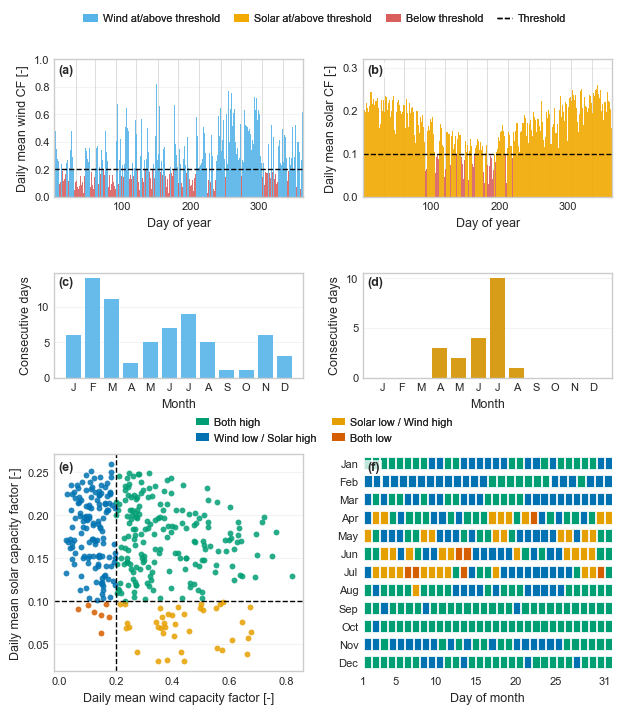

In [47]:
# Combined renewable-scarcity figure
cf_combined_scenario = active_scenario
cf_combined_years = [detailed_year]   # one representative planning year
cf_combined_export_dir = PAPER_FIGURE_DIR / "figure04_capacity_factor_combined"
cf_combined_export_dir.mkdir(parents=True, exist_ok=True)

RESOURCE_LABELS = [
    "Both high",
    "Wind low / Solar high",
    "Solar low / Wind high",
    "Both low",
]
RESOURCE_COLORS = ["#009e73", "#0072b2", "#e69f00", "#d55e00"]


def _resource_calendar_dataframe(wind_daily, solar_daily, wind_threshold, solar_threshold):
    df = pd.DataFrame({"wind": wind_daily, "solar": solar_daily}).dropna().copy()
    df["month"] = df.index.month
    df["day"] = df.index.day
    df["category"] = np.select(
        [
            (df["wind"] >= wind_threshold) & (df["solar"] >= solar_threshold),
            (df["wind"] < wind_threshold) & (df["solar"] >= solar_threshold),
            (df["wind"] >= wind_threshold) & (df["solar"] < solar_threshold),
            (df["wind"] < wind_threshold) & (df["solar"] < solar_threshold),
        ],
        [0, 1, 2, 3],
        default=np.nan,
    )
    return df


def _add_month_separators_embedded(ax, daily_index):
    month_starts = pd.Series(index=daily_index, data=1).resample("MS").first().index
    month_start_days = month_starts.dayofyear.values
    for day in month_start_days:
        ax.axvline(day, color="#bcbcbc", linewidth=0.7, alpha=0.5, zorder=0)
    return ax


def _month_bar_axis(ax, series, color, ylabel, panel):
    month_labels = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]
    month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    x = np.arange(len(month_labels))
    vals = series.reindex(month_order).fillna(0.0).values

    ax.bar(x, vals, color=color, alpha=0.90, width=0.78)
    ax.set_xticks(x)
    ax.set_xticklabels(month_labels, fontsize=7)
    finish_axis(ax, xlabel="Month", ylabel=ylabel)
    ax.grid(False)
    ax.yaxis.grid(True, alpha=0.22)
    ax.xaxis.grid(False)
    ax.set_axisbelow(True)
    panel_label(ax, panel)


def _draw_resource_calendar_blocks(ax, calendar_df, panel):
    """
    Draw daily resource-category blocks month by month.

    Each month row spans the same total width, but daily blocks are wider
    in shorter months, so February/April/June/etc. align with 31-day months.
    """
    month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

    # Use the actual year to handle leap years correctly.
    plot_year = int(calendar_df.index[0].year)

    max_days_axis = 31.0

    ax.set_xlim(0, max_days_axis)
    ax.set_ylim(-0.5, 11.5)
    ax.invert_yaxis()

    for month_idx in range(12):
        month_num = month_idx + 1
        n_days = monthrange(plot_year, month_num)[1]

        # Daily blocks are stretched so each month row spans 31 axis units.
        cell_width = max_days_axis / n_days
        block_width = cell_width * 0.88
        x_pad = (cell_width - block_width) / 2

        month_df = calendar_df[calendar_df["month"] == month_num]

        for _, row in month_df.iterrows():
            day = int(row["day"])
            cat = int(row["category"])

            x0 = (day - 1) * cell_width + x_pad

            rect = Rectangle(
                (x0, month_idx - 0.34),
                block_width,
                0.68,
                facecolor=RESOURCE_COLORS[cat],
                edgecolor="white",
                linewidth=0.55,
            )
            ax.add_patch(rect)

    ax.set_yticks(np.arange(12))
    ax.set_yticklabels(month_labels, fontsize=8)

    # These are approximate day-of-month reference labels on a 31-day axis.
    ax.set_xticks([0, 4, 9, 14, 19, 24, 30])
    ax.set_xticklabels([1, 5, 10, 15, 20, 25, 31], fontsize=7)

    finish_axis(ax, xlabel="Day of month", ylabel=None)
    ax.grid(False)
    ax.tick_params(axis="both", length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)

    panel_label(ax, panel)


def plot_combined_cf_figure(scenario_code, year, save_figure=True, show_figure=True):
    result = scenario_results[scenario_code]["results"][year]
    wind_cf_local = result["wind_cf"]
    solar_cf_local = result["solar_cf"]

    wind_series_local = _prepare_cf_series(wind_cf_local)
    solar_series_local = _prepare_cf_series(solar_cf_local)
    wind_daily_local = _daily_mean_series(wind_series_local)
    solar_daily_local = _daily_mean_series(solar_series_local)

    wind_streak_local = _monthly_max_consecutive_low_days(wind_daily_local, LOW_WIND_THRESHOLD)
    solar_streak_local = _monthly_max_consecutive_low_days(solar_daily_local, LOW_SOLAR_THRESHOLD)

    scatter_df = pd.DataFrame({"wind": wind_daily_local, "solar": solar_daily_local}).dropna()
    calendar_df = _resource_calendar_dataframe(
        wind_daily_local,
        solar_daily_local,
        LOW_WIND_THRESHOLD,
        LOW_SOLAR_THRESHOLD,
    )

    # Slightly tighter figure, but still enough room for shared legends
    fig = plt.figure(figsize=(7.2, 8.5))
    gs = fig.add_gridspec(
        3, 2,
        height_ratios=[1.00, 0.76, 1.58],
        hspace=0.50,
        wspace=0.24,
    )

    ax_a = fig.add_subplot(gs[0, 0])
    ax_b = fig.add_subplot(gs[0, 1])
    ax_c = fig.add_subplot(gs[1, 0])
    ax_d = fig.add_subplot(gs[1, 1])
    ax_e = fig.add_subplot(gs[2, 0])
    ax_f = fig.add_subplot(gs[2, 1])

    # Colors for threshold panels
    wind_high_color = TECH_COLORS.get("wind", "#5bbcff")
    solar_high_color = "#f2a900"
    low_color = "#d95f5f"

    # (a) Daily wind CF
    day_w = wind_daily_local.index.dayofyear
    colors_w = np.where(
        wind_daily_local.values < LOW_WIND_THRESHOLD,
        low_color,
        wind_high_color,
    )
    ax_a.bar(day_w, wind_daily_local.values, color=colors_w, width=1.0, alpha=0.90)
    ax_a.axhline(LOW_WIND_THRESHOLD, color="black", linestyle="--", linewidth=1)
    ax_a.set_xlim(1, int(day_w.max()))
    ax_a.set_ylim(0, 1.0)
    finish_axis(ax_a, xlabel="Day of year", ylabel="Daily mean wind CF [-]")
    ax_a.grid(False)
    ax_a.yaxis.grid(True, alpha=0.22)
    ax_a.xaxis.grid(False)
    _add_month_separators_embedded(ax_a, wind_daily_local.index)
    panel_label(ax_a, "(a)")

    # (b) Daily solar CF
    day_s = solar_daily_local.index.dayofyear
    colors_s = np.where(
        solar_daily_local.values < LOW_SOLAR_THRESHOLD,
        low_color,
        solar_high_color,
    )
    ax_b.bar(day_s, solar_daily_local.values, color=colors_s, width=1.0, alpha=0.90)
    ax_b.axhline(LOW_SOLAR_THRESHOLD, color="black", linestyle="--", linewidth=1)
    ax_b.set_xlim(1, int(day_s.max()))
    ax_b.set_ylim(0, max(0.32, float(solar_daily_local.max()) * 1.15))
    finish_axis(ax_b, xlabel="Day of year", ylabel="Daily mean solar CF [-]")
    ax_b.grid(False)
    ax_b.yaxis.grid(True, alpha=0.22)
    ax_b.xaxis.grid(False)
    _add_month_separators_embedded(ax_b, solar_daily_local.index)
    panel_label(ax_b, "(b)")

    # (c) Longest low-wind streak per month
    _month_bar_axis(
        ax_c,
        wind_streak_local,
        wind_high_color,
        "Consecutive days",
        "(c)",
    )

    # (d) Longest low-solar streak per month
    _month_bar_axis(
        ax_d,
        solar_streak_local,
        "#d39200",
        "Consecutive days",
        "(d)",
    )

    # (e) Scatter of daily wind vs solar CF
    conditions = [
        (scatter_df["wind"] >= LOW_WIND_THRESHOLD) & (scatter_df["solar"] >= LOW_SOLAR_THRESHOLD),
        (scatter_df["wind"] < LOW_WIND_THRESHOLD) & (scatter_df["solar"] >= LOW_SOLAR_THRESHOLD),
        (scatter_df["wind"] >= LOW_WIND_THRESHOLD) & (scatter_df["solar"] < LOW_SOLAR_THRESHOLD),
        (scatter_df["wind"] < LOW_WIND_THRESHOLD) & (scatter_df["solar"] < LOW_SOLAR_THRESHOLD),
    ]

    for mask, lab, col in zip(conditions, RESOURCE_LABELS, RESOURCE_COLORS):
        ax_e.scatter(
            scatter_df.loc[mask, "wind"],
            scatter_df.loc[mask, "solar"],
            s=18,
            alpha=0.85,
            color=col,
            label=lab,
            linewidths=0,
        )

    ax_e.axvline(LOW_WIND_THRESHOLD, color="black", linestyle="--", linewidth=1)
    ax_e.axhline(LOW_SOLAR_THRESHOLD, color="black", linestyle="--", linewidth=1)
    finish_axis(
        ax_e,
        xlabel="Daily mean wind capacity factor [-]",
        ylabel="Daily mean solar capacity factor [-]",
    )
    ax_e.grid(False)
    ax_e.yaxis.grid(True, alpha=0.22)
    ax_e.xaxis.grid(False)
    panel_label(ax_e, "(e)")

    # (f) Resource category calendar
    _draw_resource_calendar_blocks(ax_f, calendar_df, "(f)")

    # Shared legend for panels (a) and (b), above first row
    threshold_legend_items = [
        Patch(facecolor=wind_high_color, label="Wind at/above threshold"),
        Patch(facecolor=solar_high_color, label="Solar at/above threshold"),
        Patch(facecolor=low_color, label="Below threshold"),
        Line2D([0], [0], color="black", linestyle="--", linewidth=1, label="Threshold"),
    ]
    leg_top = fig.legend(
        handles=threshold_legend_items,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.985),
        ncol=4,
        fontsize=7.8,
        frameon=False,
        columnspacing=1.25,
        handlelength=1.4,
        handletextpad=0.5,
    )
    fig.add_artist(leg_top)

    # Shared legend for panels (e) and (f), just above third row
    resource_legend_items = [
        Patch(facecolor=RESOURCE_COLORS[0], label="Both high"),
        Patch(facecolor=RESOURCE_COLORS[1], label="Wind low / Solar high"),
        Patch(facecolor=RESOURCE_COLORS[2], label="Solar low / Wind high"),
        Patch(facecolor=RESOURCE_COLORS[3], label="Both low"),
    ]
    leg_mid = fig.legend(
        handles=resource_legend_items,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.51),
        ncol=2,
        fontsize=7.8,
        frameon=False,
        columnspacing=1.35,
        handlelength=1.2,
        handletextpad=0.5,
    )
    fig.add_artist(leg_mid)

    if not PAPER_MODE:
        fig.suptitle(
            f"{scenario_label(scenario_code)} – renewable scarcity ({year})",
            fontsize=FONT_SIZE_LABEL + 1,
            y=0.997,
        )
        fig.subplots_adjust(top=0.92, bottom=0.07)
    else:
        fig.subplots_adjust(top=0.92, bottom=0.20)

    out_path = None
    if save_figure:
        out_path = save_paper_figure(
            fig,
            f"figure04_combined_{scenario_code}_{year}.png",
            folder=cf_combined_export_dir,
        )
        out_path = save_paper_figure(
            fig,
            f"figure04_combined_{scenario_code}_{year}.svg",
            folder=cf_combined_export_dir,
        )
        out_path = save_paper_figure(
            fig,
            f"figure04_combined_{scenario_code}_{year}.pdf",
            folder=cf_combined_export_dir,
        )

    if show_figure:
        plt.show()
    else:
        plt.close(fig)

    return out_path


for year in cf_combined_years:
    print(f"\nPlotting combined Figure 4 for {cf_combined_scenario} – {year}...")
    plot_combined_cf_figure(cf_combined_scenario, year)


In [48]:
# Longest simultaneous low-wind and low-solar event
def identify_simultaneous_low_event(
    wind_cf,
    solar_cf,
    wind_threshold=LOW_WIND_THRESHOLD,
    solar_threshold=LOW_SOLAR_THRESHOLD,
):
    wind_series = wind_cf.mean(axis=1).copy()
    solar_series = solar_cf.mean(axis=1).copy()

    wind_series.index = pd.to_datetime(wind_series.index)
    solar_series.index = pd.to_datetime(solar_series.index)

    wind_daily = wind_series.resample("D").mean()
    solar_daily = solar_series.resample("D").mean()

    low_event_mask = (wind_daily < wind_threshold) & (solar_daily < solar_threshold)
    start, end, duration_days = _longest_true_run(low_event_mask)

    event_table = pd.DataFrame({
        "wind_daily_cf": wind_daily,
        "solar_daily_cf": solar_daily,
        "simultaneous_low": low_event_mask,
    })

    if start is None:
        raise ValueError("No simultaneous low-wind and low-solar event found with the selected thresholds.")

    return {
        "start_day": start,
        "end_day": end,
        "duration_days": duration_days,
        "start_hour": pd.Timestamp(start),
        "end_hour": pd.Timestamp(end) + pd.Timedelta(hours=23),
        "event_table": event_table,
    }


critical_event = identify_simultaneous_low_event(
    wind_cf,
    solar_cf,
    wind_threshold=LOW_WIND_THRESHOLD,
    solar_threshold=LOW_SOLAR_THRESHOLD,
)

critical_event_start = critical_event["start_hour"]
critical_event_end = critical_event["end_hour"]

print("Critical simultaneous low-renewable event:")
print(f"  Start: {critical_event_start}")
print(f"  End:   {critical_event_end}")
print(f"  Duration: {critical_event['duration_days']} days")

display(
    critical_event["event_table"]
    .loc[critical_event["start_day"]:critical_event["end_day"]]
    .round(3)
)

# Export event table for traceability
critical_event_table_path = TABLE_EXPORT_DIR / f"critical_event_daily_table_{base_case_name}_{active_scenario}_{detailed_year}.csv"
critical_event["event_table"].to_csv(critical_event_table_path)
print(f"Saved daily event table to: {critical_event_table_path}")


Critical simultaneous low-renewable event:
  Start: 2025-06-12 00:00:00
  End:   2025-06-13 23:00:00
  Duration: 2 days


,wind_daily_cf,solar_daily_cf,simultaneous_low
index,,,
2025-06-12,0.149,0.063,True
2025-06-13,0.164,0.097,True


Saved daily event table to: output\output_new_zealand\tables\critical_event_daily_table_new_zealand_reference_2025.csv


Saved figure: output\output_new_zealand\figures\figure_critical_event_dispatch_negative_loads_2025.png


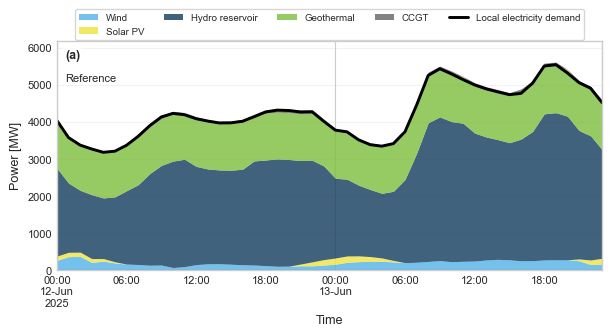

C:\Users\vse23\AppData\Local\Temp\ipykernel_36368\1224707826.py:280: UserWarning:

obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.



,scenario,paper_label,event_start,event_end,event_demand_mwh,event_supply_mwh,event_flexible_electricity_use_mwh,supply_wind_mwh,supply_solar_mwh,supply_hydro_reservoir_mwh,supply_geothermal_mwh,supply_coal_mwh,supply_ccgt_mwh,supply_ocgt_mwh,supply_gas_cogeneration_mwh,supply_gas_peaker_mwh,supply_thermal_other_mwh,supply_slack_mwh
0,reference,Reference,2025-06-12,2025-06-13 23:00:00,204293.018,206900.975,0.0,10005.497,1940.61,131521.37,60446.4,0.0,2987.097,0.0,0.0,0.0,0.0,0.0


Saved event summary to: output\output_new_zealand\tables\critical_event_dispatch_summary_negative_loads_2025.csv


In [49]:
# Dispatch during the critical low-renewable event
selected_scenarios_for_event = list(scenario_results.keys())

event_year = detailed_year


def _series_like_snapshots(net, value=0.0):
    return pd.Series(float(value), index=pd.to_datetime(net.snapshots))


def _link_input_power_by_carrier(net, carrier: str) -> pd.Series:
    """Positive input power at p0 for links of a given carrier [MW]."""
    if len(net.links) == 0 or not hasattr(net.links_t, "p0"):
        return _series_like_snapshots(net)

    links = net.links.index[net.links["carrier"].astype(str) == carrier]
    if len(links) == 0:
        return _series_like_snapshots(net)

    data = net.links_t.p0.reindex(columns=links, fill_value=0.0)
    return data.clip(lower=0.0).sum(axis=1)


def _link_output_power_by_carrier(net, carrier: str) -> pd.Series:
    """Positive useful output power at p1 for links of a given carrier [MW]."""
    if len(net.links) == 0 or not hasattr(net.links_t, "p1"):
        return _series_like_snapshots(net)

    links = net.links.index[net.links["carrier"].astype(str) == carrier]
    if len(links) == 0:
        return _series_like_snapshots(net)

    data = -net.links_t.p1.reindex(columns=links, fill_value=0.0)
    return data.clip(lower=0.0).sum(axis=1)


def _electricity_balance_for_network(net):
    """
    Return positive electricity supply and negative flexible electricity
    consumption. This avoids hiding BESS charging/electrolyser operation inside
    the positive dispatch stack.
    """
    # Positive generator dispatch, normalised to compact plotting keys so
    # spelling variants do not create duplicated legend entries.
    if len(net.generators) > 0:
        gen_dispatch = (
            net.generators_t.p
            .reindex(
                index=net.snapshots,
                columns=net.generators.index,
                fill_value=0.0,
            )
            .clip(lower=0.0)
        )
        gen_plot_key = net.generators["carrier"].map(dispatch_plot_key)
        supply = gen_dispatch.T.groupby(gen_plot_key).sum().T
    else:
        supply = pd.DataFrame(index=pd.to_datetime(net.snapshots))

    # StorageUnits are split explicitly. Reservoir hydro is positive hydro
    # supply; only assets classified as BESS contribute to BESS discharge and
    # BESS charging.
    bess_charge = _series_like_snapshots(net)

    if len(net.storage_units) > 0:
        storage_power = net.storage_units_t.p.reindex(
            index=net.snapshots,
            columns=net.storage_units.index,
            fill_value=0.0,
        )

        for asset in net.storage_units.index:
            group = storage_unit_group(net.storage_units, asset)
            power = storage_power[asset]

            if group == "BESS":
                supply["bess"] = (
                    supply.get("bess", _series_like_snapshots(net))
                    + power.clip(lower=0.0)
                )
                bess_charge = bess_charge + (
                    -power.clip(upper=0.0)
                )
            elif group == "Hydro reservoir":
                supply["hydro_reservoir"] = (
                    supply.get(
                        "hydro_reservoir",
                        _series_like_snapshots(net),
                    )
                    + power.clip(lower=0.0)
                )

    # Hydrogen-to-power output is positive supply on the electricity side.
    for carrier in ["h2_fuel_cell", "h2_turbine"]:
        output = _link_output_power_by_carrier(net, carrier)
        if output.sum() > 1e-6:
            supply[carrier] = output

    # Flexible electricity uses shown below zero.
    consumption = pd.DataFrame(index=supply.index)
    if bess_charge.sum() > 1e-6:
        consumption["bess_charge"] = bess_charge

    for carrier in ["electrolyzer", "asu", "dac"]:
        input_power = _link_input_power_by_carrier(net, carrier)
        if input_power.sum() > 1e-6:
            consumption[carrier] = input_power

    preferred_supply_order = [
        "wind",
        "solar",
        "hydro_run_of_river",
        "hydro_reservoir",
        "geothermal",
        "bess",
        "h2_fuel_cell",
        "h2_turbine",
        "coal",
        "ccgt",
        "ocgt",
        "gas_cogeneration",
        "gas_peaker",
        "thermal_other",
        "diesel",
        "slack",
    ]
    supply_cols = [c for c in preferred_supply_order if c in supply.columns]
    supply_cols += [c for c in supply.columns if c not in supply_cols]
    supply = supply[supply_cols].clip(lower=0.0)

    preferred_consumption_order = ["bess_charge", "electrolyzer", "asu", "dac"]
    cons_cols = [c for c in preferred_consumption_order if c in consumption.columns]
    cons_cols += [c for c in consumption.columns if c not in cons_cols]
    consumption = consumption[cons_cols].clip(lower=0.0)

    return supply, consumption


def _plot_event_balance(ax, supply_event, consumption_event, load_event, scenario_code, panel=None):
    # Positive electricity supply stack
    supply_cols = [c for c in supply_event.columns if supply_event[c].sum() > 1e-6]
    supply_colors = [TECH_COLORS.get(c, "#999999") for c in supply_cols]

    if supply_cols:
        supply_event[supply_cols].plot.area(
            ax=ax,
            stacked=True,
            color=supply_colors,
            alpha=0.82,
            linewidth=0,
        )

    # Negative flexible electricity use, stacked below zero.
    # Matplotlib's area plot often keeps autoscaling from zero upward, so the
    # y-limits are set explicitly after this block.
    negative_stack = pd.Series(0.0, index=consumption_event.index)
    for col in consumption_event.columns:
        s = consumption_event[col].fillna(0.0)
        if s.sum() <= 1e-6:
            continue

        color_key = "bess" if col == "bess_charge" else col
        lower = -negative_stack.values
        upper = -(negative_stack + s).values

        ax.fill_between(
            s.index,
            lower,
            upper,
            step="mid",
            color=TECH_COLORS.get(color_key, "#999999"),
            alpha=0.46,
            linewidth=0,
            label=clean_technology_label(col),
        )
        negative_stack = negative_stack + s

    # Demand lines
    local_load = load_event
    flexible_use = consumption_event.sum(axis=1) if len(consumption_event.columns) > 0 else pd.Series(0.0, index=load_event.index)
    effective_load = local_load + flexible_use

    local_load.plot(ax=ax, color="black", linewidth=2.1, label="Local electricity demand")
    if hasattr(effective_load, "sum") and flexible_use.sum() > 1e-6:
        effective_load.plot(
            ax=ax, color="black", linewidth=1.5, linestyle="--",
            label="Demand + flexible electricity use"
        )

    # Force the negative part to be visible.
    positive_max = max(
        float(supply_event.sum(axis=1).max()) if not supply_event.empty else 0.0,
        float(effective_load.max()) if hasattr(effective_load, "max") else 0.0,
        1.0,
    )
    negative_max = float(negative_stack.max()) if hasattr(negative_stack, "max") else 0.0
    ymin = -1.12 * negative_max if negative_max > 1e-6 else 0.0
    ymax = 1.10 * positive_max
    ax.set_ylim(ymin, ymax)

    ax.axhline(0, color="black", linewidth=0.8)
    finish_axis(ax, ylabel="Power [MW]")
    ax.text(
        0.015, 0.86,
        scenario_label(scenario_code),
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=FONT_SIZE_SMALL,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.5),
    )

    if panel:
        panel_label(ax, panel)

    # Clean legend labels
    handles, labels = ax.get_legend_handles_labels()
    clean_labels = [clean_technology_label(l) for l in labels]
    by_label = dict(zip(clean_labels, handles))
    ax.legend(
        by_label.values(), by_label.keys(),
        loc="upper center", bbox_to_anchor=(0.5, 1.16),
        ncol=5, fontsize=7, frameon=True
    )


missing_scenarios = [s for s in selected_scenarios_for_event if s not in scenario_results]
if missing_scenarios:
    raise ValueError(f"These scenarios are not available in scenario_results: {missing_scenarios}")


nrows = len(selected_scenarios_for_event)
fig, axes = plt.subplots(nrows, 1, figsize=(WORD_DOUBLE_COL_IN, max(2.25 * nrows, 3.5)), sharex=True)

if nrows == 1:
    axes = [axes]

event_rows = []
panel_letters = [f"({chr(97+i)})" for i in range(nrows)]

for ax, scenario_code, letter in zip(axes, selected_scenarios_for_event, panel_letters):
    package = scenario_results[scenario_code]
    result = package["results"][event_year]
    net = result["network"]

    supply, consumption = _electricity_balance_for_network(net)

    supply_event = supply.loc[critical_event_start:critical_event_end]
    consumption_event = consumption.loc[critical_event_start:critical_event_end]
    load_event = result["load"].sum(axis=1).loc[critical_event_start:critical_event_end]

    _plot_event_balance(
        ax, supply_event, consumption_event, load_event,
        scenario_code=scenario_code,
        panel=letter,
    )

    row = {
        "scenario": scenario_code,
        "paper_label": scenario_label(scenario_code),
        "event_start": critical_event_start,
        "event_end": critical_event_end,
        "event_demand_mwh": float(load_event.sum()),
        "event_supply_mwh": float(supply_event.sum().sum()),
        "event_flexible_electricity_use_mwh": float(consumption_event.sum().sum()) if not consumption_event.empty else 0.0,
    }
    for col in supply_event.columns:
        row[f"supply_{col}_mwh"] = float(supply_event[col].sum())
    for col in consumption_event.columns:
        row[f"negative_{col}_mwh"] = float(consumption_event[col].sum())
    event_rows.append(row)

axes[-1].set_xlabel("Time")

plt.tight_layout()

fig_path = save_paper_figure(fig, f"figure_critical_event_dispatch_negative_loads_{event_year}.png")
plt.show()

event_summary = pd.DataFrame(event_rows)
display(event_summary.round(3))

event_summary_path = TABLE_EXPORT_DIR / f"critical_event_dispatch_summary_negative_loads_{event_year}.csv"
event_summary.to_csv(event_summary_path, index=False)
print(f"Saved event summary to: {event_summary_path}")


Favourable summer week selected from reference: 22–29 Dec 2025
Saved figure: output\output_new_zealand\figures\figure_dispatch_critical_event_2025.png


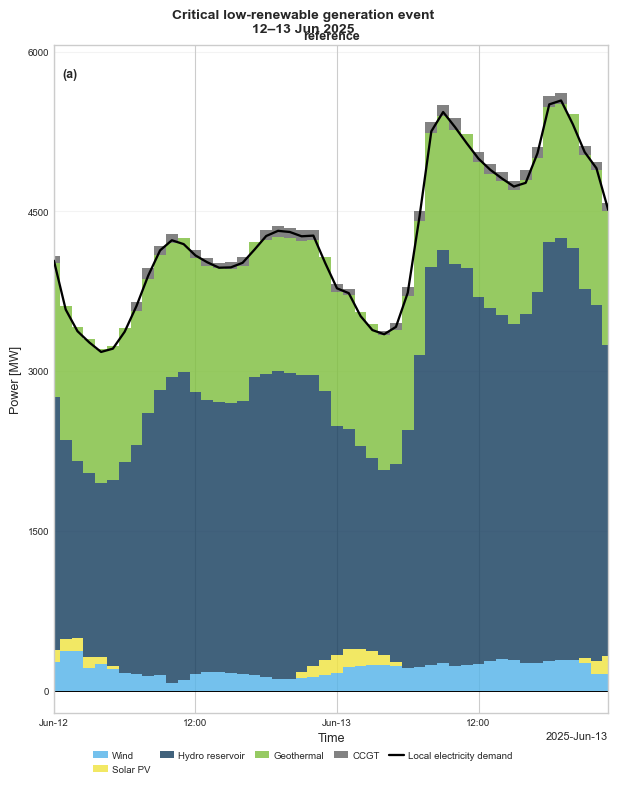

Saved figure to: output\output_new_zealand\figures\figure_dispatch_critical_event_2025.png
  reference: -212.1 to 6059.4 MW
Saved figure: output\output_new_zealand\figures\figure_dispatch_favourable_summer_week_2025.png


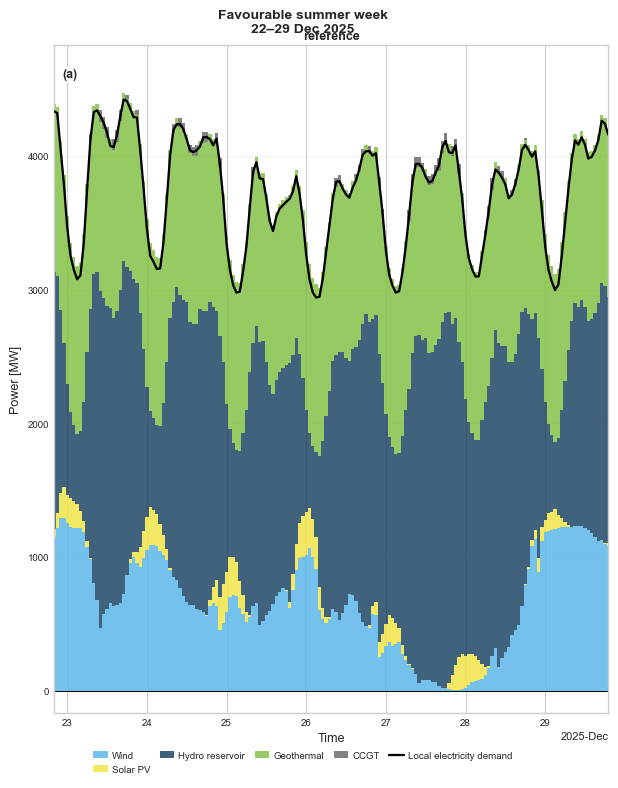

Saved figure to: output\output_new_zealand\figures\figure_dispatch_favourable_summer_week_2025.png
  reference: -169.0 to 4829.9 MW


C:\Users\vse23\AppData\Local\Temp\ipykernel_36368\3888513550.py:1168: UserWarning:

obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.



,scenario,paper_label,period,period_start,period_end,local_demand_mwh,electricity_supply_mwh,flexible_electricity_use_mwh,supply_wind_mwh,supply_solar_mwh,supply_hydro_reservoir_mwh,supply_geothermal_mwh,supply_coal_mwh,supply_ccgt_mwh,supply_ocgt_mwh,supply_gas_cogeneration_mwh,supply_gas_peaker_mwh,supply_thermal_other_mwh,supply_slack_mwh
0,reference,reference,critical_event,2025-06-12 00:00:00,2025-06-13 23:00:00,204293.018,206900.975,0.0,10005.497,1940.610,131521.370,60446.4,0.0,2987.097,0.0,0.0,0.0,0.0,0.0
1,reference,reference,summer_week,2025-12-22 20:00:00,2025-12-29 19:00:00,626927.135,635564.150,0.0,113649.768,13026.528,293950.143,211562.4,0.0,3375.310,0.0,0.0,0.0,0.0,0.0


Saved dispatch comparison summary to: output\output_new_zealand\tables\dispatch_critical_vs_summer_summary_2025.csv


In [50]:
import inspect
# Two separate dispatch figures:
#   1. Critical low-renewable generation event
#   2. Favourable summer week
#
# Each figure contains one panel per scenario.
# Y-axis scales are shared within:
#   BAU–RT, RE–RH, and PtX separately.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator


# ── Configuration ─────────────────────────────────────────────────────────────
dispatch_comparison_year = globals().get(
    "detailed_year",
    2050,
)

SUMMER_MONTHS = (12, 1, 2)
SUMMER_WINDOW_DAYS = 7

# Leave as None for automatic selection.
# Example:
# SUMMER_WEEK_START = f"{dispatch_comparison_year}-01-15 00:00"
SUMMER_WEEK_START = None

figure_width = globals().get(
    "WORD_DOUBLE_COL_IN",
    7.1,
)

small_font = globals().get(
    "FONT_SIZE_SMALL",
    8,
)


# ── Scenario selection and labels ─────────────────────────────────────────────
def _short_scenario_label(scenario_code):
    """Return BAU, RT, RE, RH or PtX without S-number or _base."""
    text = str(scenario_code).upper().replace("-", "_")

    parts = [part for part in text.split("_") if part]

    if "PTX" in parts or "PTX" in text:
        return "PtX"

    for label in [
        "BAU",
        "RT",
        "RE",
        "RH",
    ]:
        if label in parts:
            return label

    return str(scenario_code).replace("_base", "").replace("_BASE", "")


scenario_order = [
    "BAU",
    "RT",
    "RE",
    "RH",
    "PtX",
]

available_scenarios = list(scenario_results.keys())

dispatch_comparison_scenarios = []

for desired_label in scenario_order:
    matching_scenarios = [
        scenario_code for scenario_code in available_scenarios if _short_scenario_label(scenario_code) == desired_label
    ]

    if not matching_scenarios:
        continue

    # Prefer the base pathway if more than one variant exists.
    matching_scenarios.sort(
        key=lambda scenario_code: (
            not str(scenario_code).upper().endswith("_BASE"),
            str(scenario_code),
        )
    )

    dispatch_comparison_scenarios.append(matching_scenarios[0])


if not dispatch_comparison_scenarios:
    # A single NZ reference export is a valid dispatch-analysis case.
    dispatch_comparison_scenarios = [
        active_scenario if active_scenario in available_scenarios else available_scenarios[0]
    ]


def _scale_group_label(scenario_code):
    label = _short_scenario_label(scenario_code)

    if label in {
        "BAU",
        "RT",
    }:
        return "BAU–RT"

    if label in {
        "RE",
        "RH",
    }:
        return "RE–RH"

    if label == "PtX":
        return "PtX"

    return label


# ── General helpers ───────────────────────────────────────────────────────────
def _naive_datetime_index(values):
    index = pd.DatetimeIndex(pd.to_datetime(values))

    if index.tz is not None:
        index = index.tz_localize(None)

    return index


def _naive_timestamp(value):
    timestamp = pd.Timestamp(value)

    if timestamp.tz is not None:
        timestamp = timestamp.tz_localize(None)

    return timestamp


def _normalise_timeseries_index(values):
    out = values.copy()

    out.index = _naive_datetime_index(out.index)

    return out.sort_index()


def _total_local_load(result):
    load = result["load"]

    if isinstance(
        load,
        pd.Series,
    ):
        return load.copy()

    return load.sum(axis=1)


def _format_period(start, end):
    start = pd.Timestamp(start)
    end = pd.Timestamp(end)

    if start.year == end.year and start.month == end.month:
        return f"{start.day}–{end.day} {start:%b %Y}"

    if start.year == end.year:
        return f"{start.day} {start:%b}–{end.day} {end:%b %Y}"

    return f"{start.day} {start:%b %Y}–{end.day} {end:%b %Y}"


def _snapshot_hours(index):
    index = pd.DatetimeIndex(index)

    if len(index) == 0:
        return pd.Series(
            dtype=float,
            index=index,
        )

    timestamp_series = pd.Series(
        index,
        index=index,
    )

    durations = timestamp_series.shift(-1) - timestamp_series

    typical_duration = durations.dropna().median()

    if pd.isna(typical_duration):
        typical_duration = pd.Timedelta(hours=1)

    durations.iloc[-1] = typical_duration

    return durations.dt.total_seconds().div(3600.0)


# ── Renewable potential for summer-week selection ────────────────────────────
def _renewable_potential_and_load(
    scenario_code,
    model_year,
):
    """
    Return available wind + solar generation and local load [MW].

    Renewable potential is based on installed capacity multiplied
    by p_max_pu, rather than realised dispatch.
    """
    result = scenario_results[scenario_code]["results"][model_year]

    net = result["network"]

    generator_carriers = net.generators["carrier"].astype(str)

    renewable_generators = net.generators.index[
        generator_carriers.str.contains(
            r"wind|solar|pv",
            case=False,
            regex=True,
        )
    ]

    if len(renewable_generators) == 0:
        return None, None

    p_nom_fallback = pd.to_numeric(
        net.generators.get(
            "p_nom",
            pd.Series(
                0.0,
                index=net.generators.index,
            ),
        ),
        errors="coerce",
    ).fillna(0.0)

    p_nom = pd.to_numeric(
        net.generators.get(
            "p_nom_opt",
            pd.Series(
                np.nan,
                index=net.generators.index,
            ),
        ),
        errors="coerce",
    ).fillna(p_nom_fallback)

    p_nom = p_nom.reindex(renewable_generators).fillna(0.0)

    static_p_max_pu = pd.to_numeric(
        net.generators.get(
            "p_max_pu",
            pd.Series(
                1.0,
                index=net.generators.index,
            ),
        ),
        errors="coerce",
    ).fillna(1.0)

    dynamic_p_max_pu = getattr(
        net.generators_t,
        "p_max_pu",
        pd.DataFrame(index=net.snapshots),
    )

    p_max_pu = dynamic_p_max_pu.reindex(
        index=net.snapshots,
        columns=renewable_generators,
    ).copy()

    for generator in renewable_generators:
        p_max_pu[generator] = pd.to_numeric(
            p_max_pu[generator],
            errors="coerce",
        ).fillna(
            float(
                static_p_max_pu.get(
                    generator,
                    1.0,
                )
            )
        )

    renewable_potential = p_max_pu.multiply(
        p_nom,
        axis=1,
    ).sum(axis=1)

    renewable_potential.index = _naive_datetime_index(renewable_potential.index)

    local_load = _total_local_load(result)

    local_load.index = _naive_datetime_index(local_load.index)

    local_load = local_load.reindex(renewable_potential.index).fillna(0.0)

    return (
        renewable_potential.sort_index(),
        local_load.sort_index(),
    )


# Prefer RE for selecting the weather period.
summer_reference_rank = {
    "RE": 0,
    "RH": 1,
    "PtX": 2,
    "RT": 3,
    "BAU": 4,
}

summer_reference_preferences = sorted(
    dispatch_comparison_scenarios,
    key=lambda scenario_code: summer_reference_rank.get(
        _short_scenario_label(scenario_code),
        99,
    ),
)

summer_reference_scenario = None
reference_renewable_potential = None
reference_local_load = None

for candidate in summer_reference_preferences:
    if dispatch_comparison_year not in scenario_results[candidate]["results"]:
        continue

    candidate_potential, candidate_load = _renewable_potential_and_load(
        candidate,
        dispatch_comparison_year,
    )

    if candidate_potential is not None and candidate_potential.max() > 1e-6:
        summer_reference_scenario = candidate

        reference_renewable_potential = candidate_potential

        reference_local_load = candidate_load

        break


if summer_reference_scenario is None:
    raise ValueError("No scenario with wind or solar capacity was found to identify the favourable summer week.")


# ── Select the favourable summer week ────────────────────────────────────────
reference_index = reference_renewable_potential.index

if len(reference_index) < 2:
    raise ValueError("Not enough snapshots to select a summer week.")

snapshot_interval = reference_index.to_series().diff().dropna().median()

if pd.isna(snapshot_interval) or snapshot_interval <= pd.Timedelta(0):
    raise ValueError("Could not determine the snapshot interval.")

summer_window_steps = int(round(pd.Timedelta(days=SUMMER_WINDOW_DAYS) / snapshot_interval))

summer_window_steps = max(
    summer_window_steps,
    1,
)


if SUMMER_WEEK_START is not None:
    summer_week_start = _naive_timestamp(SUMMER_WEEK_START)

    matching_positions = np.flatnonzero(reference_index == summer_week_start)

    if len(matching_positions) == 0:
        raise ValueError(f"SUMMER_WEEK_START={SUMMER_WEEK_START} is not a model snapshot.")

    start_position = int(matching_positions[0])

    end_position = start_position + summer_window_steps - 1

    if end_position >= len(reference_index):
        raise ValueError("The manually selected summer week extends beyond the available snapshots.")

    summer_week_end = reference_index[end_position]

else:
    summer_snapshot_mask = pd.Series(
        reference_index.month.isin(SUMMER_MONTHS).astype(float),
        index=reference_index,
    )

    complete_summer_window = (
        summer_snapshot_mask.rolling(
            window=summer_window_steps,
            min_periods=summer_window_steps,
        )
        .sum()
        .eq(float(summer_window_steps))
    )

    rolling_renewable_potential = reference_renewable_potential.rolling(
        window=summer_window_steps,
        min_periods=summer_window_steps,
    ).sum()

    rolling_local_load = reference_local_load.rolling(
        window=summer_window_steps,
        min_periods=summer_window_steps,
    ).sum()

    favourable_week_score = rolling_renewable_potential.div(
        rolling_local_load.replace(
            0.0,
            np.nan,
        )
    ).where(complete_summer_window)

    valid_scores = favourable_week_score.dropna()

    if valid_scores.empty:
        raise ValueError("No complete seven-day summer window was found.")

    summer_week_end = valid_scores.idxmax()

    end_position = int(reference_index.get_loc(summer_week_end))

    start_position = end_position - summer_window_steps + 1

    summer_week_start = reference_index[start_position]


print(
    "Favourable summer week selected from "
    f"{_short_scenario_label(summer_reference_scenario)}: "
    f"{_format_period(summer_week_start, summer_week_end)}"
)


# ── Period definitions ────────────────────────────────────────────────────────
period_definitions = [
    {
        "key": "critical_event",
        "title": ("Critical low-renewable generation event"),
        "file_stub": "critical_event",
        "start": _naive_timestamp(critical_event_start),
        "end": _naive_timestamp(critical_event_end),
    },
    {
        "key": "summer_week",
        "title": ("Favourable summer week"),
        "file_stub": "favourable_summer_week",
        "start": summer_week_start,
        "end": summer_week_end,
    },
]


# ── Prepare dispatch data ─────────────────────────────────────────────────────
dispatch_period_data = {}
dispatch_comparison_rows = []

for scenario_code in dispatch_comparison_scenarios:
    package = scenario_results[scenario_code]

    if dispatch_comparison_year not in package["results"]:
        raise ValueError(f"{scenario_code} has no result for {dispatch_comparison_year}.")

    result = package["results"][dispatch_comparison_year]

    net = result["network"]

    supply, consumption = _electricity_balance_for_network(net)

    supply = _normalise_timeseries_index(supply).fillna(0.0)

    consumption = _normalise_timeseries_index(consumption).fillna(0.0)

    local_load = _normalise_timeseries_index(_total_local_load(result)).fillna(0.0)

    consumption = consumption.reindex(
        supply.index,
        fill_value=0.0,
    ).fillna(0.0)

    local_load = local_load.reindex(supply.index).fillna(0.0)

    for period in period_definitions:
        period_mask = (supply.index >= period["start"]) & (supply.index <= period["end"])

        supply_period = supply.loc[period_mask].copy()

        consumption_period = consumption.loc[period_mask].copy()

        load_period = local_load.loc[period_mask].copy()

        if supply_period.empty:
            raise ValueError(
                f"No snapshots found for {scenario_code}, {period['title']}: {period['start']} to {period['end']}."
            )

        dispatch_period_data[
            (
                scenario_code,
                period["key"],
            )
        ] = {
            "supply": supply_period,
            "consumption": consumption_period,
            "load": load_period,
        }

        snapshot_hours = _snapshot_hours(supply_period.index)

        supply_energy = supply_period.mul(
            snapshot_hours,
            axis=0,
        )

        consumption_energy = consumption_period.mul(
            snapshot_hours,
            axis=0,
        )

        load_energy = load_period * snapshot_hours

        summary_row = {
            "scenario": scenario_code,
            "paper_label": (_short_scenario_label(scenario_code)),
            "period": period["key"],
            "period_start": (supply_period.index.min()),
            "period_end": (supply_period.index.max()),
            "local_demand_mwh": float(load_energy.sum()),
            "electricity_supply_mwh": float(supply_energy.sum().sum()),
            "flexible_electricity_use_mwh": float(consumption_energy.sum().sum()),
        }

        for column in supply_energy.columns:
            summary_row[f"supply_{column}_mwh"] = float(supply_energy[column].sum())

        for column in consumption_energy.columns:
            summary_row[f"negative_{column}_mwh"] = float(consumption_energy[column].sum())

        dispatch_comparison_rows.append(summary_row)


# ── Period-specific grouped y-axis limits ─────────────────────────────────────
scale_group_members = {}

for scenario_code in dispatch_comparison_scenarios:
    group_label = _scale_group_label(scenario_code)

    scale_group_members.setdefault(
        group_label,
        [],
    ).append(scenario_code)


def _calculate_group_ylim(
    period_key,
    scenario_codes,
):
    positive_max = 1.0
    negative_max = 0.0

    for scenario_code in scenario_codes:
        data = dispatch_period_data[
            (
                scenario_code,
                period_key,
            )
        ]

        supply_period = data["supply"].clip(lower=0.0)

        consumption_period = data["consumption"].clip(lower=0.0)

        load_period = data["load"].clip(lower=0.0)

        flexible_use = consumption_period.sum(axis=1)

        total_supply = supply_period.sum(axis=1)

        total_electricity_use = load_period + flexible_use

        positive_max = max(
            positive_max,
            float(total_supply.max()),
            float(load_period.max()),
            float(total_electricity_use.max()),
        )

        negative_max = max(
            negative_max,
            float(flexible_use.max()),
        )

    upper_limit = 1.08 * positive_max

    if negative_max > 1e-6:
        lower_limit = -1.08 * negative_max
    else:
        # Retain a small margin below zero without
        # forcing zero to the centre of the panel.
        lower_limit = -0.035 * upper_limit

    return (
        lower_limit,
        upper_limit,
    )


period_group_y_limits = {}

for period in period_definitions:
    for (
        group_label,
        scenario_codes,
    ) in scale_group_members.items():
        period_group_y_limits[
            (
                period["key"],
                group_label,
            )
        ] = _calculate_group_ylim(
            period["key"],
            scenario_codes,
        )


# ── Plotting colours and labels ───────────────────────────────────────────────
fallback_colors = {
    "wind": "#56B4E9",
    "solar": "#F0E442",
    "hydro_run_of_river": "#0072B2",
    "hydro_reservoir": "#173F5F",
    "geothermal": "#7FBF3F",
    "bess": "#9C6ADE",
    "h2_fuel_cell": "#E69F00",
    "h2_turbine": "#A65E2E",
    "coal": "#3D3D3D",
    "ccgt": "#666666",
    "ocgt": "#8C8C8C",
    "gas_cogeneration": "#B0B0B0",
    "gas_peaker": "#737373",
    "thermal_other": "#A1887F",
    "diesel": "#8D6E63",
    "slack": "#D55E00",
    "electrolyzer": "#009E73",
    "electrolyser": "#009E73",
    "asu": "#80CBC4",
    "dac": "#4DB6AC",
}

plot_colors = fallback_colors.copy()

plot_colors.update(
    globals().get(
        "TECH_COLORS",
        {},
    )
)


def _dispatch_color(carrier):
    color_key = "bess" if carrier == "bess_charge" else carrier

    return plot_colors.get(
        color_key,
        "#999999",
    )


def _dispatch_legend_label(carrier):
    label_overrides = {
        "bess": "BESS discharge",
        "bess_charge": "BESS charge",
        "electrolyzer": "Electrolyser",
        "electrolyser": "Electrolyser",
        "asu": "ASU",
        "dac": "DAC",
        "h2_fuel_cell": (r"H$_2$ fuel cell"),
        "h2_turbine": (r"H$_2$ turbine"),
        "hydro_run_of_river": "Hydro run-of-river",
        "hydro_reservoir": "Hydro reservoir",
        "geothermal": "Geothermal",
        "coal": "Coal",
        "ccgt": "CCGT",
        "ocgt": "OCGT",
        "gas_cogeneration": "Gas cogeneration",
        "gas_peaker": "Gas peaker",
        "thermal_other": "Other thermal",
        "slack": "Slack",
    }

    if carrier in label_overrides:
        return label_overrides[carrier]

    if callable(globals().get("clean_technology_label")):
        return clean_technology_label(carrier)

    return str(carrier).replace("_", " ").title()


def _finish_dispatch_axis(
    ax,
    ylabel,
):
    if callable(globals().get("finish_axis")):
        finish_axis(
            ax,
            ylabel=ylabel,
        )

    else:
        ax.set_ylabel(ylabel)

        ax.spines["top"].set_visible(False)

        ax.spines["right"].set_visible(False)

    ax.grid(
        axis="y",
        alpha=0.22,
    )

    ax.set_axisbelow(True)

    ax.tick_params(
        labelsize=small_font - 1,
    )


def _add_panel_label(
    ax,
    text,
):
    if callable(globals().get("panel_label")):
        panel_label(
            ax,
            text,
        )

    else:
        ax.text(
            0.01,
            0.97,
            text,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=small_font,
            fontweight="bold",
        )


# ── Individual panel ──────────────────────────────────────────────────────────
def _plot_dispatch_panel(
    ax,
    supply_period,
    consumption_period,
    load_period,
    y_limits,
    scenario_title,
    panel_text,
):
    active_supply_columns = [
        column for column in supply_period.columns if (supply_period[column].clip(lower=0.0).sum() > 1e-6)
    ]

    if active_supply_columns:
        ax.stackplot(
            supply_period.index,
            *[(supply_period[column].fillna(0.0).clip(lower=0.0).to_numpy()) for column in active_supply_columns],
            colors=[_dispatch_color(column) for column in active_supply_columns],
            alpha=0.82,
            linewidth=0.0,
            step="mid",
        )

    negative_stack = np.zeros(
        len(consumption_period),
        dtype=float,
    )

    for column in consumption_period.columns:
        values = consumption_period[column].fillna(0.0).clip(lower=0.0).to_numpy()

        if values.sum() <= 1e-6:
            continue

        previous_stack = negative_stack.copy()

        negative_stack += values

        ax.fill_between(
            consumption_period.index,
            -previous_stack,
            -negative_stack,
            step="mid",
            color=_dispatch_color(column),
            alpha=0.46,
            linewidth=0.0,
        )

    flexible_use = consumption_period.clip(lower=0.0).sum(axis=1)

    total_electricity_use = load_period + flexible_use

    ax.plot(
        load_period.index,
        load_period,
        color="black",
        linewidth=1.65,
        zorder=5,
    )

    if flexible_use.sum() > 1e-6:
        ax.plot(
            total_electricity_use.index,
            total_electricity_use,
            color="black",
            linewidth=1.20,
            linestyle="--",
            zorder=5,
        )

    ax.axhline(
        0.0,
        color="black",
        linewidth=0.70,
    )

    ax.set_xlim(
        supply_period.index.min(),
        supply_period.index.max(),
    )

    ax.set_ylim(y_limits)

    ax.yaxis.set_major_locator(
        MaxNLocator(
            nbins=5,
        )
    )

    ax.margins(x=0.0)

    _finish_dispatch_axis(
        ax,
        ylabel="Power [MW]",
    )

    ax.set_title(
        scenario_title,
        fontsize=small_font + 1,
        fontweight="semibold",
        pad=4,
    )

    _add_panel_label(
        ax,
        panel_text,
    )

    if ax.get_legend() is not None:
        ax.get_legend().remove()


# ── Legend for each period ────────────────────────────────────────────────────
def _period_legend(
    period_key,
):
    used_supply_carriers = set()
    used_consumption_carriers = set()
    has_flexible_use = False

    for scenario_code in dispatch_comparison_scenarios:
        data = dispatch_period_data[
            (
                scenario_code,
                period_key,
            )
        ]

        for column in data["supply"].columns:
            if data["supply"][column].clip(lower=0.0).sum() > 1e-6:
                used_supply_carriers.add(column)

        for column in data["consumption"].columns:
            if data["consumption"][column].clip(lower=0.0).sum() > 1e-6:
                used_consumption_carriers.add(column)

                has_flexible_use = True

    preferred_supply_order = [
        "wind",
        "solar",
        "hydro_run_of_river",
        "hydro_reservoir",
        "geothermal",
        "bess",
        "h2_fuel_cell",
        "h2_turbine",
        "coal",
        "ccgt",
        "ocgt",
        "gas_cogeneration",
        "gas_peaker",
        "thermal_other",
        "diesel",
        "slack",
    ]

    ordered_supply_carriers = [carrier for carrier in preferred_supply_order if carrier in used_supply_carriers]

    ordered_supply_carriers += sorted(
        carrier for carrier in used_supply_carriers if carrier not in ordered_supply_carriers
    )

    preferred_consumption_order = [
        "bess_charge",
        "electrolyzer",
        "electrolyser",
        "asu",
        "dac",
    ]

    ordered_consumption_carriers = [
        carrier for carrier in preferred_consumption_order if carrier in used_consumption_carriers
    ]

    ordered_consumption_carriers += sorted(
        carrier for carrier in used_consumption_carriers if carrier not in ordered_consumption_carriers
    )

    handles = []
    labels = []
    seen_labels = set()

    for carrier in ordered_supply_carriers:
        label = _dispatch_legend_label(carrier)

        if label in seen_labels:
            continue

        handles.append(
            Patch(
                facecolor=_dispatch_color(carrier),
                edgecolor="none",
                alpha=0.82,
            )
        )

        labels.append(label)

        seen_labels.add(label)

    for carrier in ordered_consumption_carriers:
        label = _dispatch_legend_label(carrier)

        if label in seen_labels:
            continue

        handles.append(
            Patch(
                facecolor=_dispatch_color(carrier),
                edgecolor="none",
                alpha=0.46,
            )
        )

        labels.append(label)

        seen_labels.add(label)

    handles.append(
        Line2D(
            [0],
            [0],
            color="black",
            linewidth=1.65,
        )
    )

    labels.append("Local electricity demand")

    if has_flexible_use:
        handles.append(
            Line2D(
                [0],
                [0],
                color="black",
                linewidth=1.20,
                linestyle="--",
            )
        )

        labels.append("Demand + flexible electricity use")

    return (
        handles,
        labels,
    )


# ── Create one figure per period ──────────────────────────────────────────────
def _make_dispatch_period_figure(
    period,
):
    nrows = len(dispatch_comparison_scenarios)

    figure_height = max(
        2 * nrows + 1.5,
        8,
    )

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=1,
        figsize=(
            figure_width,
            figure_height,
        ),
        sharex=True,
        squeeze=False,
    )

    axes = axes[:, 0]

    for row_index, scenario_code in enumerate(dispatch_comparison_scenarios):
        data = dispatch_period_data[
            (
                scenario_code,
                period["key"],
            )
        ]

        group_label = _scale_group_label(scenario_code)

        y_limits = period_group_y_limits[
            (
                period["key"],
                group_label,
            )
        ]

        _plot_dispatch_panel(
            ax=axes[row_index],
            supply_period=data["supply"],
            consumption_period=data["consumption"],
            load_period=data["load"],
            y_limits=y_limits,
            scenario_title=(_short_scenario_label(scenario_code)),
            panel_text=(f"({chr(97 + row_index)})"),
        )

    for ax in axes[:-1]:
        ax.tick_params(
            axis="x",
            labelbottom=False,
        )

    date_locator = mdates.AutoDateLocator(
        minticks=4,
        maxticks=7,
    )

    axes[-1].xaxis.set_major_locator(date_locator)

    axes[-1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(date_locator))

    axes[-1].set_xlabel("Time")

    legend_handles, legend_labels = _period_legend(period["key"])

    legend_ncol = min(
        5,
        max(
            1,
            len(legend_labels),
        ),
    )

    legend_rows = int(np.ceil(len(legend_labels) / legend_ncol))

    fig.legend(
        legend_handles,
        legend_labels,
        loc="lower center",
        bbox_to_anchor=(
            0.5,
            0.018,  # sube ligeramente la leyenda
        ),
        ncol=legend_ncol,
        frameon=False,
        fontsize=small_font - 1,
        columnspacing=1.0,
        handlelength=1.5,
        handletextpad=0.4,
    )

    fig.suptitle(
        (f"{period['title']}\n{_format_period(period['start'], period['end'])}"),
        x=0.5,
        y=0.985,
        ha="center",
        va="top",
        fontsize=small_font + 2,
        fontweight="semibold",
    )

    fig.subplots_adjust(
        top=0.94,  # acerca el primer panel al título
        bottom=0.105,  # acerca el último panel a la leyenda
        left=0.105,
        right=0.985,
        hspace=0.25,
    )

    figure_filename = f"figure_dispatch_{period['file_stub']}_{dispatch_comparison_year}.png"

    if callable(globals().get("save_paper_figure")):
        figure_path = save_paper_figure(
            fig,
            figure_filename,
        )

    else:
        figure_path = Path(figure_filename)

        fig.savefig(
            figure_path,
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()

    print(f"Saved figure to: {figure_path}")

    for group_label in scale_group_members:
        limits = period_group_y_limits[
            (
                period["key"],
                group_label,
            )
        ]

        print(f"  {group_label}: {limits[0]:.1f} to {limits[1]:.1f} MW")

    return figure_path


dispatch_figure_paths = {}

for period in period_definitions:
    dispatch_figure_paths[period["key"]] = _make_dispatch_period_figure(period)


# ── Export comparison summary ─────────────────────────────────────────────────
dispatch_comparison_summary = pd.DataFrame(dispatch_comparison_rows)

display(dispatch_comparison_summary.round(3))

table_export_dir = Path(
    globals().get(
        "TABLE_EXPORT_DIR",
        ".",
    )
)

table_export_dir.mkdir(
    parents=True,
    exist_ok=True,
)

dispatch_comparison_summary_path = table_export_dir / (
    f"dispatch_critical_vs_summer_summary_{dispatch_comparison_year}.csv"
)

dispatch_comparison_summary.to_csv(
    dispatch_comparison_summary_path,
    index=False,
)

print(f"Saved dispatch comparison summary to: {dispatch_comparison_summary_path}")

## 8. Curtailment

Curtailment is calculated as available wind and solar generation minus dispatched generation, using optimized capacities and exported time-dependent availability.

In [51]:
# Curtailment calculation

def _get_nominal_capacity_for_curtailment(net, gen_ids):
    """
    Return optimized capacity when available, otherwise nominal capacity.
    Works for both expansion runs and fixed-capacity re-operation.
    """
    gens = net.generators.loc[gen_ids].copy()

    if "p_nom_opt" in gens.columns:
        p_nom = gens["p_nom_opt"].copy()
        p_nom = p_nom.fillna(gens["p_nom"])
    else:
        p_nom = gens["p_nom"].copy()

    return p_nom.astype(float).fillna(0.0)


def build_vre_curtailment_table(net, freq="YS"):
    """
    Build a wind and solar curtailment table.

    Curtailment is calculated as:
        available VRE = p_nom * p_max_pu
        curtailed VRE = max(available VRE - dispatched VRE, 0)

    Parameters
    ----------
    net : pypsa.Network
    freq : str
        "YS" for annual, "MS" for monthly, "D" for daily, "h" for hourly.
    """
    if len(net.generators) == 0:
        return pd.DataFrame()

    rows = []

    vre_carriers = ["wind", "solar"]

    for carrier in vre_carriers:
        gen_ids = net.generators.index[
            net.generators["carrier"].astype(str).str.lower() == carrier
        ].tolist()

        if not gen_ids:
            continue

        # Safer check: do not silently assume p_max_pu = 1 if missing.
        missing_profiles = [g for g in gen_ids if g not in net.generators_t.p_max_pu.columns]
        if missing_profiles:
            raise ValueError(
                f"Missing p_max_pu profiles for {carrier}: {missing_profiles}. "
                "Do not calculate curtailment with assumed p_max_pu = 1.0."
            )

        p_nom = _get_nominal_capacity_for_curtailment(net, gen_ids)

        available = net.generators_t.p_max_pu[gen_ids].clip(lower=0.0).multiply(p_nom, axis=1)
        dispatch = net.generators_t.p[gen_ids].fillna(0.0).clip(lower=0.0)

        curtailed = (available - dispatch).clip(lower=0.0)

        for gen_id in gen_ids:
            bus = net.generators.loc[gen_id, "bus"]

            tmp = pd.DataFrame({
                "available_mwh": available[gen_id],
                "dispatch_mwh": dispatch[gen_id],
                "curtailment_mwh": curtailed[gen_id],
            })

            if freq is not None:
                tmp = tmp.resample(freq).sum()

            for ts, r in tmp.iterrows():
                rows.append({
                    "period": ts,
                    "carrier": carrier,
                    "generator": gen_id,
                    "bus": bus,
                    "available_mwh": float(r["available_mwh"]),
                    "dispatch_mwh": float(r["dispatch_mwh"]),
                    "curtailment_mwh": float(r["curtailment_mwh"]),
                })

    out = pd.DataFrame(rows)

    if out.empty:
        return out

    out["curtailment_share_available_pct"] = np.where(
        out["available_mwh"] > 0,
        100 * out["curtailment_mwh"] / out["available_mwh"],
        np.nan,
    )

    return out


In [52]:
# Curtailment summary tables
curtailment_selection = "all"   # "all", one scenario code, or a list


def _resolve_selection(selection):
    if selection == "all":
        return list(scenario_results.keys())
    if isinstance(selection, str):
        return [selection]
    return list(selection)


curtailment_annual_tables = []
curtailment_monthly_tables = []

for scenario_code in _resolve_selection(curtailment_selection):
    package = scenario_results[scenario_code]
    paper_id = package["metadata"].get("paper_id", "")
    label = scenario_label(scenario_code, paper_id=paper_id)

    for year in years:
        net = package["results"][year]["network"]

        annual_df = build_vre_curtailment_table(net, freq="YS")
        if not annual_df.empty:
            annual_df = annual_df.copy()
            annual_df["scenario"] = scenario_code
            annual_df["paper_id"] = paper_id
            annual_df["scenario_label"] = label
            annual_df["year"] = year
            curtailment_annual_tables.append(annual_df)

        monthly_df = build_vre_curtailment_table(net, freq="MS")
        if not monthly_df.empty:
            monthly_df = monthly_df.copy()
            monthly_df["scenario"] = scenario_code
            monthly_df["paper_id"] = paper_id
            monthly_df["scenario_label"] = label
            monthly_df["year"] = year
            monthly_df["month_num"] = monthly_df["period"].dt.month
            monthly_df["month"] = monthly_df["period"].dt.strftime("%b")
            curtailment_monthly_tables.append(monthly_df)

curtailment_annual_all = pd.concat(curtailment_annual_tables, ignore_index=True) if curtailment_annual_tables else pd.DataFrame()
curtailment_monthly_all = pd.concat(curtailment_monthly_tables, ignore_index=True) if curtailment_monthly_tables else pd.DataFrame()

if not curtailment_annual_all.empty:
    curtailment_annual_summary = (
        curtailment_annual_all
        .groupby(["scenario", "paper_id", "scenario_label", "year", "carrier"], as_index=False)
        [["available_mwh", "dispatch_mwh", "curtailment_mwh"]]
        .sum()
    )
    curtailment_annual_summary["curtailment_share_available_pct"] = np.where(
        curtailment_annual_summary["available_mwh"] > 0,
        100 * curtailment_annual_summary["curtailment_mwh"] / curtailment_annual_summary["available_mwh"],
        np.nan,
    )

    curtailment_annual_total = (
        curtailment_annual_summary
        .groupby(["scenario", "paper_id", "scenario_label", "year"], as_index=False)
        [["available_mwh", "dispatch_mwh", "curtailment_mwh"]]
        .sum()
    )
    curtailment_annual_total["curtailment_share_available_pct"] = np.where(
        curtailment_annual_total["available_mwh"] > 0,
        100 * curtailment_annual_total["curtailment_mwh"] / curtailment_annual_total["available_mwh"],
        np.nan,
    )
else:
    curtailment_annual_summary = pd.DataFrame()
    curtailment_annual_total = pd.DataFrame()

if not curtailment_monthly_all.empty:
    curtailment_monthly_summary = (
        curtailment_monthly_all
        .groupby(["scenario", "paper_id", "scenario_label", "year", "month_num", "month", "carrier"], as_index=False)
        [["available_mwh", "dispatch_mwh", "curtailment_mwh"]]
        .sum()
    )
    curtailment_monthly_summary["curtailment_share_available_pct"] = np.where(
        curtailment_monthly_summary["available_mwh"] > 0,
        100 * curtailment_monthly_summary["curtailment_mwh"] / curtailment_monthly_summary["available_mwh"],
        np.nan,
    )
else:
    curtailment_monthly_summary = pd.DataFrame()

print("Curtailment annual summary rows:", len(curtailment_annual_summary))
print("Curtailment monthly summary rows:", len(curtailment_monthly_summary))
if not curtailment_annual_total.empty:
    display(curtailment_annual_total.head())


Curtailment annual summary rows: 2
Curtailment monthly summary rows: 24


,scenario,paper_id,scenario_label,year,available_mwh,dispatch_mwh,curtailment_mwh,curtailment_share_available_pct
0,reference,Reference,Reference,2025,4.685747e+06,4.680730e+06,5017.393079,0.107078


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

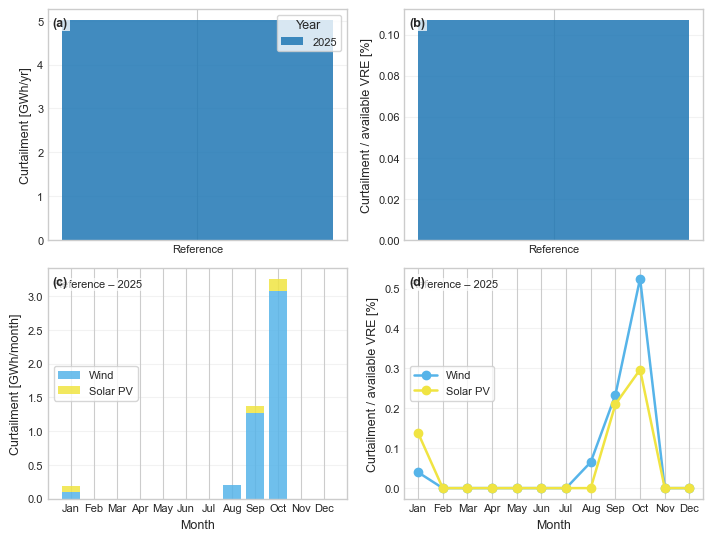

In [53]:
# Curtailment figures
curtailment_focus_scenario = active_scenario
curtailment_focus_year = detailed_year

if curtailment_annual_total.empty:
    raise ValueError("No curtailment summary available. Run the previous cell first.")

# Ordered labels for the annual plots
scenario_order = [s for s in SCENARIO_PLOT_ORDER if s in curtailment_annual_total["scenario"].unique()]
plot_df = curtailment_annual_total.copy()
plot_df["scenario"] = pd.Categorical(plot_df["scenario"], categories=scenario_order, ordered=True)
plot_df = plot_df.sort_values(["scenario", "year"]).copy()
plot_df["x_label"] = [scenario_axis_label(s) for s in plot_df["scenario"]]

unique_scenarios = plot_df[["scenario", "paper_id", "x_label"]].drop_duplicates().sort_values("scenario")
scenario_codes = unique_scenarios["scenario"].tolist()
xlabels = [scenario_axis_label(s) for s in unique_scenarios["scenario"].tolist()]
unique_years = sorted(plot_df["year"].unique())
x = np.arange(len(scenario_codes))
bar_width = 0.8 / max(len(unique_years), 1)

fig, axes = plt.subplots(2, 2, figsize=FIGSIZE_2COL_LARGE)

# (a) Total annual curtailment [GWh/yr]
ax = axes[0, 0]
for i, year in enumerate(unique_years):
    tmp = plot_df[plot_df["year"] == year].set_index("scenario").reindex(scenario_codes)
    values = tmp["curtailment_mwh"].fillna(0).values / 1e3
    ax.bar(x + (i - (len(unique_years)-1)/2) * bar_width, values, width=bar_width, label=str(year), alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(xlabels, rotation=0, ha="center")
finish_axis(ax, ylabel="Curtailment [GWh/yr]")
ax.legend(title="Year", ncol=2, frameon=True)
panel_label(ax, "(a)")

# (b) Curtailment share of available VRE [%]
ax = axes[0, 1]
for i, year in enumerate(unique_years):
    tmp = plot_df[plot_df["year"] == year].set_index("scenario").reindex(scenario_codes)
    values = tmp["curtailment_share_available_pct"].fillna(0).values
    ax.bar(x + (i - (len(unique_years)-1)/2) * bar_width, values, width=bar_width, label=str(year), alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(xlabels, rotation=0, ha="center")
finish_axis(ax, ylabel="Curtailment / available VRE [%]")
panel_label(ax, "(b)")

# Monthly deep-dive for a selected scenario/year
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly_focus = curtailment_monthly_summary[
    (curtailment_monthly_summary["scenario"] == curtailment_focus_scenario) &
    (curtailment_monthly_summary["year"] == curtailment_focus_year)
].copy()
monthly_focus["month"] = pd.Categorical(monthly_focus["month"], categories=month_order, ordered=True)
monthly_focus = monthly_focus.sort_values(["month", "carrier"])

# (c) Monthly curtailment [GWh/month]
ax = axes[1, 0]
if not monthly_focus.empty:
    pivot_gwh = monthly_focus.pivot_table(index="month", columns="carrier", values="curtailment_mwh", aggfunc="sum").fillna(0) / 1e3
    bottom = np.zeros(len(pivot_gwh))
    for carrier in [c for c in ["wind", "solar"] if c in pivot_gwh.columns]:
        vals = pivot_gwh[carrier].values
        ax.bar(pivot_gwh.index.astype(str), vals, bottom=bottom, color=TECH_COLORS.get(carrier, "#999999"), alpha=0.85, label=clean_technology_label(carrier))
        bottom += vals
    ax.legend(frameon=True)
finish_axis(ax, xlabel="Month", ylabel="Curtailment [GWh/month]")
ax.tick_params(axis="x", rotation=0)
ax.text(0.02, 0.95, f"{scenario_label(curtailment_focus_scenario)} – {curtailment_focus_year}", transform=ax.transAxes, ha="left", va="top", fontsize=FONT_SIZE_SMALL, bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.2))
panel_label(ax, "(c)")

# (d) Monthly curtailment share [%]
ax = axes[1, 1]
if not monthly_focus.empty:
    pivot_pct = monthly_focus.pivot_table(index="month", columns="carrier", values="curtailment_share_available_pct", aggfunc="sum").fillna(0)
    for carrier in [c for c in ["wind", "solar"] if c in pivot_pct.columns]:
        ax.plot(pivot_pct.index.astype(str), pivot_pct[carrier].values, marker="o", linewidth=1.8, label=clean_technology_label(carrier), color=TECH_COLORS.get(carrier, "#999999"))
    ax.legend(frameon=True)
finish_axis(ax, xlabel="Month", ylabel="Curtailment / available VRE [%]")
ax.tick_params(axis="x", rotation=0)
ax.text(0.02, 0.95, f"{scenario_label(curtailment_focus_scenario)} – {curtailment_focus_year}", transform=ax.transAxes, ha="left", va="top", fontsize=FONT_SIZE_SMALL, bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.2))
panel_label(ax, "(d)")

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


## 9. Monthly system operation, emissions, and hydro reservoirs

This section complements the annual and critical-event figures with monthly
electricity supply, CO₂ emissions, reservoir inflow/generation/spill, and
reservoir state of charge. All panels are optional: missing reservoirs, BESS,
or hydrogen assets produce an informative note instead of stopping execution.


C:\Users\vse23\AppData\Local\Temp\ipykernel_36368\3285991032.py:584: UserWarning:

Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.



Saved figure: output\output_new_zealand\figures\figure_monthly_system_hydro_reference_2025.png


c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.



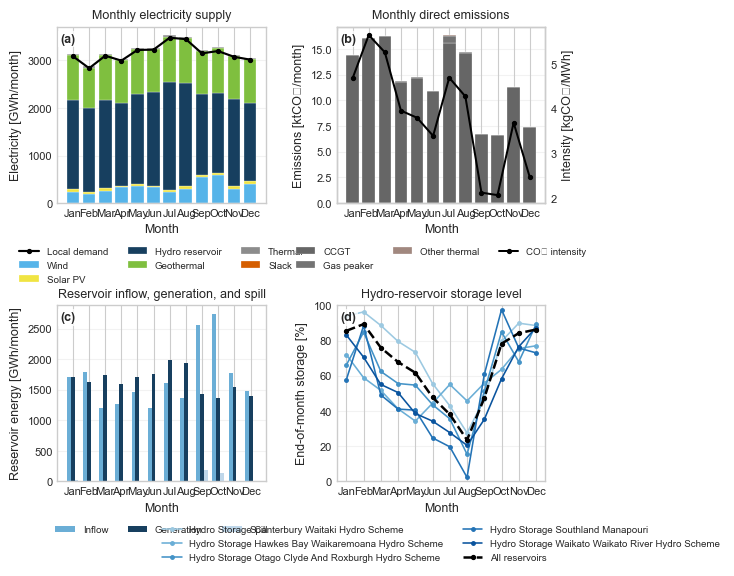

Saved monthly supply table: output\output_new_zealand\tables\monthly\new_zealand_reference_monthly_supply_2025.csv
Saved monthly emissions table: output\output_new_zealand\tables\monthly\new_zealand_reference_monthly_emissions_2025.csv
Saved monthly reservoir table: output\output_new_zealand\tables\monthly\new_zealand_reference_monthly_reservoirs_2025.csv
Saved monthly reservoir SOC table: output\output_new_zealand\tables\monthly\new_zealand_reference_monthly_reservoir_soc_2025.csv


In [54]:
# Monthly system operation and hydro-reservoir diagnostics
monthly_scenario = active_scenario
monthly_year = detailed_year
monthly_result = scenario_results[monthly_scenario]["results"][monthly_year]
monthly_net = monthly_result["network"]


def _materialise_table(value) -> pd.DataFrame:
    """Load a disk-backed table or copy an in-memory DataFrame."""
    if value is None:
        return pd.DataFrame()
    if hasattr(value, "load"):
        return value.load()
    if isinstance(value, pd.DataFrame):
        return value.copy()
    return pd.DataFrame(value)


def _dynamic_table_or_zero(
    namespace,
    attribute: str,
    snapshots: pd.Index,
    columns: pd.Index,
) -> pd.DataFrame:
    """Load an optional dynamic table and align it to snapshots/assets."""
    try:
        value = getattr(namespace, attribute)
        table = _materialise_table(value)
    except Exception:
        table = pd.DataFrame()

    return table.reindex(
        index=snapshots,
        columns=columns,
        fill_value=0.0,
    ).fillna(0.0)


def _monthly_weights(net) -> pd.Series:
    """Return hourly-equivalent snapshot weights used for energy totals."""
    snapshots = pd.DatetimeIndex(pd.to_datetime(net.snapshots))
    try:
        weight_table = _materialise_table(net.snapshot_weightings)
        for column in ("generators", "objective", "stores"):
            if column in weight_table.columns:
                return (
                    pd.to_numeric(
                        weight_table[column],
                        errors="coerce",
                    )
                    .reindex(snapshots)
                    .fillna(1.0)
                )
    except Exception:
        pass
    return pd.Series(1.0, index=snapshots, dtype=float)


def _monthly_sum(
    values: pd.DataFrame | pd.Series,
    weights: pd.Series,
) -> pd.DataFrame | pd.Series:
    """Convert MW snapshots to weighted monthly MWh."""
    aligned = values.copy()
    aligned.index = pd.DatetimeIndex(pd.to_datetime(aligned.index))
    weighted = aligned.mul(
        weights.reindex(aligned.index).fillna(1.0),
        axis=0,
    )
    return weighted.groupby(weighted.index.month).sum().reindex(
        range(1, 13),
        fill_value=0.0,
    )


def _effective_storage_energy_capacity(
    storage_units: pd.DataFrame,
    assets: pd.Index,
) -> pd.Series:
    """Return energy capacity [MWh] for BESS or hydro StorageUnits."""
    if len(assets) == 0:
        return pd.Series(dtype=float)

    table = storage_units.loc[assets]
    power = _nominal_capacity(
        table,
        "p_nom_opt",
        "p_nom",
    )
    fallback = (
        power
        * pd.to_numeric(
            table.get(
                "max_hours",
                pd.Series(0.0, index=assets),
            ),
            errors="coerce",
        ).fillna(0.0)
    )

    if "hydro_energy_capacity_mwh" in table.columns:
        explicit = pd.to_numeric(
            table["hydro_energy_capacity_mwh"],
            errors="coerce",
        )
        return explicit.where(
            explicit > 0.0,
            fallback,
        ).fillna(fallback)

    return fallback


monthly_snapshots = pd.DatetimeIndex(
    pd.to_datetime(monthly_net.snapshots)
)
monthly_weights = _monthly_weights(monthly_net)

generators_monthly = _materialise_table(monthly_net.generators)
storage_units_monthly = _materialise_table(monthly_net.storage_units)
links_monthly = _materialise_table(monthly_net.links)
carriers_monthly = _materialise_table(monthly_net.carriers)

# ── Monthly electricity supply ────────────────────────────────────────────────
monthly_supply_hourly = pd.DataFrame(
    index=monthly_snapshots,
    dtype=float,
)

if not generators_monthly.empty:
    generator_dispatch_monthly = _dynamic_table_or_zero(
        monthly_net.generators_t,
        "p",
        monthly_snapshots,
        generators_monthly.index,
    ).clip(lower=0.0)

    generator_groups = generators_monthly["carrier"].map(
        clean_technology_group
    )
    monthly_supply_hourly = (
        generator_dispatch_monthly.T
        .groupby(generator_groups)
        .sum()
        .T
    )

bess_assets_monthly = storage_unit_assets(
    monthly_net,
    "BESS",
)
reservoir_assets_monthly = storage_unit_assets(
    monthly_net,
    "Hydro reservoir",
)

storage_power_monthly = _dynamic_table_or_zero(
    monthly_net.storage_units_t,
    "p",
    monthly_snapshots,
    storage_units_monthly.index,
)

for group, assets in [
    ("BESS", bess_assets_monthly),
    ("Hydro reservoir", reservoir_assets_monthly),
]:
    if len(assets) == 0:
        continue
    monthly_supply_hourly[group] = (
        monthly_supply_hourly.get(
            group,
            pd.Series(0.0, index=monthly_snapshots),
        )
        + storage_power_monthly[assets]
        .clip(lower=0.0)
        .sum(axis=1)
    )

# Electricity produced by hydrogen conversion links.
if not links_monthly.empty:
    for carrier, group in [
        ("h2_fuel_cell", "Hydrogen"),
        ("h2_turbine", "Hydrogen"),
    ]:
        selected = links_monthly.index[
            links_monthly["carrier"].astype(str).eq(carrier)
        ]
        if len(selected) == 0:
            continue
        output = (
            -_dynamic_table_or_zero(
                monthly_net.links_t,
                "p1",
                monthly_snapshots,
                selected,
            )
        ).clip(lower=0.0).sum(axis=1)
        monthly_supply_hourly[group] = (
            monthly_supply_hourly.get(
                group,
                pd.Series(0.0, index=monthly_snapshots),
            )
            + output
        )

monthly_supply_gwh = (
    _monthly_sum(
        monthly_supply_hourly,
        monthly_weights,
    )
    / 1e3
)

load_monthly_table = _materialise_table(
    monthly_result["load"]
)
load_monthly_table = load_monthly_table.reindex(
    monthly_snapshots,
    fill_value=0.0,
)
local_load_hourly = load_monthly_table.sum(axis=1)
monthly_local_load_gwh = (
    _monthly_sum(
        local_load_hourly,
        monthly_weights,
    )
    / 1e3
)

monthly_bess_charge_gwh = pd.Series(
    0.0,
    index=range(1, 13),
    dtype=float,
)
if len(bess_assets_monthly) > 0:
    monthly_bess_charge_gwh = (
        _monthly_sum(
            -storage_power_monthly[
                bess_assets_monthly
            ].clip(upper=0.0).sum(axis=1),
            monthly_weights,
        )
        / 1e3
    )

monthly_flexible_use_hourly = pd.Series(
    0.0,
    index=monthly_snapshots,
    dtype=float,
)
if not links_monthly.empty:
    for carrier in [
        "electrolyzer",
        "electrolyser",
        "asu",
        "dac",
    ]:
        selected = links_monthly.index[
            links_monthly["carrier"].astype(str).eq(carrier)
        ]
        if len(selected) == 0:
            continue
        monthly_flexible_use_hourly = (
            monthly_flexible_use_hourly
            + _dynamic_table_or_zero(
                monthly_net.links_t,
                "p0",
                monthly_snapshots,
                selected,
            )
            .clip(lower=0.0)
            .sum(axis=1)
        )

monthly_flexible_use_gwh = (
    _monthly_sum(
        monthly_flexible_use_hourly,
        monthly_weights,
    )
    / 1e3
)
monthly_total_electricity_use_gwh = (
    monthly_local_load_gwh
    + monthly_flexible_use_gwh
    + monthly_bess_charge_gwh
)

# ── Monthly CO2 emissions ─────────────────────────────────────────────────────
monthly_emissions_kt = pd.DataFrame(
    index=range(1, 13),
    dtype=float,
)

if (
    not generators_monthly.empty
    and "co2_emissions" in carriers_monthly.columns
):
    generator_dispatch_for_emissions = _dynamic_table_or_zero(
        monthly_net.generators_t,
        "p",
        monthly_snapshots,
        generators_monthly.index,
    ).clip(lower=0.0)

    carrier_factor = (
        generators_monthly["carrier"]
        .map(
            pd.to_numeric(
                carriers_monthly["co2_emissions"],
                errors="coerce",
            )
        )
        .fillna(0.0)
    )
    efficiency = pd.to_numeric(
        generators_monthly.get(
            "efficiency",
            pd.Series(1.0, index=generators_monthly.index),
        ),
        errors="coerce",
    ).replace(0.0, np.nan).fillna(1.0)

    emissions_by_generator = (
        generator_dispatch_for_emissions
        .multiply(
            carrier_factor / efficiency,
            axis=1,
        )
    )

    emission_plot_keys = []
    for asset in generators_monthly.index:
        key = dispatch_plot_key(
            generators_monthly.loc[asset, "carrier"]
        )
        if key in {
            "coal",
            "diesel",
            "ccgt",
            "ocgt",
            "gas_cogeneration",
            "gas_peaker",
            "thermal_other",
        }:
            emission_plot_keys.append(key)
        else:
            emission_plot_keys.append("other")

    emissions_grouped_hourly = (
        emissions_by_generator.T
        .groupby(pd.Index(emission_plot_keys))
        .sum()
        .T
    )
    monthly_emissions_kt = (
        _monthly_sum(
            emissions_grouped_hourly,
            monthly_weights,
        )
        / 1e3
    )

monthly_total_emissions_t = (
    monthly_emissions_kt.sum(axis=1) * 1e3
)
monthly_emissions_intensity = (
    1e3
    * monthly_total_emissions_t
    .div(
        (
            monthly_local_load_gwh
            * 1e3
        ).replace(0.0, np.nan)
    )
).fillna(0.0)

# ── Monthly reservoir operation and state of charge ───────────────────────────
reservoir_monthly_long = pd.DataFrame()
reservoir_soc_monthly = pd.DataFrame(
    index=range(1, 13),
)

if len(reservoir_assets_monthly) > 0:
    reservoir_inflow = _dynamic_table_or_zero(
        monthly_net.storage_units_t,
        "inflow",
        monthly_snapshots,
        reservoir_assets_monthly,
    ).clip(lower=0.0)
    reservoir_spill = _dynamic_table_or_zero(
        monthly_net.storage_units_t,
        "spill",
        monthly_snapshots,
        reservoir_assets_monthly,
    ).clip(lower=0.0)
    reservoir_generation = storage_power_monthly[
        reservoir_assets_monthly
    ].clip(lower=0.0)
    reservoir_soc_mwh = _dynamic_table_or_zero(
        monthly_net.storage_units_t,
        "state_of_charge",
        monthly_snapshots,
        reservoir_assets_monthly,
    )

    reservoir_energy_capacity = (
        _effective_storage_energy_capacity(
            storage_units_monthly,
            reservoir_assets_monthly,
        )
    )

    reservoir_inflow_gwh = (
        _monthly_sum(
            reservoir_inflow,
            monthly_weights,
        )
        / 1e3
    )
    reservoir_generation_gwh = (
        _monthly_sum(
            reservoir_generation,
            monthly_weights,
        )
        / 1e3
    )
    reservoir_spill_gwh = (
        _monthly_sum(
            reservoir_spill,
            monthly_weights,
        )
        / 1e3
    )

    reservoir_soc_pct_hourly = (
        100.0
        * reservoir_soc_mwh
        .divide(
            reservoir_energy_capacity.replace(
                0.0,
                np.nan,
            ),
            axis=1,
        )
    )
    reservoir_soc_monthly = (
        reservoir_soc_pct_hourly
        .groupby(
            reservoir_soc_pct_hourly.index.month
        )
        .last()
        .reindex(range(1, 13))
    )

    aggregate_reservoir_soc = (
        100.0
        * reservoir_soc_mwh.sum(axis=1)
        .div(
            float(reservoir_energy_capacity.sum())
            if reservoir_energy_capacity.sum() > 0.0
            else np.nan
        )
    )
    reservoir_soc_monthly["All reservoirs"] = (
        aggregate_reservoir_soc
        .groupby(
            aggregate_reservoir_soc.index.month
        )
        .last()
        .reindex(range(1, 13))
    )

    long_rows = []
    for asset in reservoir_assets_monthly:
        for month in range(1, 13):
            long_rows.append({
                "scenario": monthly_scenario,
                "year": int(monthly_year),
                "month": int(month),
                "asset_id": str(asset),
                "zone": str(
                    storage_units_monthly.loc[asset].get(
                        "bus",
                        "",
                    )
                ).replace("elec_", "", 1),
                "power_capacity_mw": float(
                    _nominal_capacity(
                        storage_units_monthly.loc[[asset]],
                        "p_nom_opt",
                        "p_nom",
                    ).sum()
                ),
                "energy_capacity_mwh": float(
                    reservoir_energy_capacity.get(
                        asset,
                        0.0,
                    )
                ),
                "inflow_gwh": float(
                    reservoir_inflow_gwh.loc[
                        month,
                        asset,
                    ]
                ),
                "generation_gwh": float(
                    reservoir_generation_gwh.loc[
                        month,
                        asset,
                    ]
                ),
                "spill_gwh": float(
                    reservoir_spill_gwh.loc[
                        month,
                        asset,
                    ]
                ),
                "end_soc_pct": float(
                    reservoir_soc_monthly.loc[
                        month,
                        asset,
                    ]
                ),
            })
    reservoir_monthly_long = pd.DataFrame(long_rows)

# ── Export monthly tables ──────────────────────────────────────────────────────
monthly_output_dir = TABLE_EXPORT_DIR / "monthly"
monthly_output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

monthly_supply_export = monthly_supply_gwh.copy()
monthly_supply_export.insert(
    0,
    "local_load_gwh",
    monthly_local_load_gwh,
)
monthly_supply_export.insert(
    1,
    "total_electricity_use_gwh",
    monthly_total_electricity_use_gwh,
)
monthly_supply_export.insert(
    2,
    "bess_charge_gwh",
    monthly_bess_charge_gwh,
)
monthly_supply_export.index.name = "month"
monthly_supply_path = (
    monthly_output_dir
    / f"{base_case_name}_{monthly_scenario}_monthly_supply_{monthly_year}.csv"
)
monthly_supply_export.to_csv(monthly_supply_path)

monthly_emissions_export = monthly_emissions_kt.copy()
monthly_emissions_export["total_emissions_ktco2"] = (
    monthly_emissions_kt.sum(axis=1)
)
monthly_emissions_export["emissions_intensity_kgco2_per_mwh"] = (
    monthly_emissions_intensity
)
monthly_emissions_export.index.name = "month"
monthly_emissions_path = (
    monthly_output_dir
    / f"{base_case_name}_{monthly_scenario}_monthly_emissions_{monthly_year}.csv"
)
monthly_emissions_export.to_csv(monthly_emissions_path)

if not reservoir_monthly_long.empty:
    reservoir_monthly_path = (
        monthly_output_dir
        / f"{base_case_name}_{monthly_scenario}_monthly_reservoirs_{monthly_year}.csv"
    )
    reservoir_monthly_long.to_csv(
        reservoir_monthly_path,
        index=False,
    )

    reservoir_soc_export = reservoir_soc_monthly.copy()
    reservoir_soc_export.index.name = "month"
    reservoir_soc_path = (
        monthly_output_dir
        / f"{base_case_name}_{monthly_scenario}_monthly_reservoir_soc_{monthly_year}.csv"
    )
    reservoir_soc_export.to_csv(
        reservoir_soc_path,
    )

# ── Four-panel monthly figure ─────────────────────────────────────────────────
month_numbers = np.arange(1, 13)
month_labels = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]

fig_monthly, axes_monthly = plt.subplots(
    2,
    2,
    figsize=(WORD_DOUBLE_COL_IN, 6.4),
)
ax_dispatch, ax_emissions, ax_hydro, ax_soc = (
    axes_monthly.ravel()
)

# (a) Monthly electricity supply
monthly_plot_groups = [
    group
    for group in TECH_GROUPS
    if group in monthly_supply_gwh.columns
    and monthly_supply_gwh[group].sum() > 1e-6
]
bottom = np.zeros(12)
for group in monthly_plot_groups:
    values = monthly_supply_gwh[group].to_numpy()
    ax_dispatch.bar(
        month_numbers,
        values,
        bottom=bottom,
        width=0.78,
        color=TECH_COLORS_GROUPED.get(
            group,
            "#999999",
        ),
        label=TECH_LEGEND_LABELS.get(
            group,
            group,
        ),
        edgecolor="white",
        linewidth=0.2,
    )
    bottom += values

ax_dispatch.plot(
    month_numbers,
    monthly_local_load_gwh.to_numpy(),
    color="black",
    linewidth=1.55,
    marker="o",
    markersize=2.8,
    label="Local demand",
)
if (
    monthly_total_electricity_use_gwh
    - monthly_local_load_gwh
).abs().sum() > 1e-6:
    ax_dispatch.plot(
        month_numbers,
        monthly_total_electricity_use_gwh.to_numpy(),
        color="black",
        linewidth=1.25,
        linestyle="--",
        label="Demand + flexible use",
    )
finish_axis(
    ax_dispatch,
    xlabel="Month",
    ylabel="Electricity [GWh/month]",
)
ax_dispatch.set_xticks(
    month_numbers,
    month_labels,
)
ax_dispatch.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.20),
    ncol=3,
    frameon=False,
    fontsize=FONT_SIZE_SMALL - 1,
)
panel_label(ax_dispatch, "(a)")
ax_dispatch.set_title(
    "Monthly electricity supply",
    fontsize=FONT_SIZE_BASE,
)

# (b) Monthly emissions and intensity
emission_order = [
    "coal",
    "ccgt",
    "ocgt",
    "gas_cogeneration",
    "gas_peaker",
    "thermal_other",
    "diesel",
    "other",
]
emission_labels = {
    "coal": "Coal",
    "ccgt": "CCGT",
    "ocgt": "OCGT",
    "gas_cogeneration": "Gas cogeneration",
    "gas_peaker": "Gas peaker",
    "thermal_other": "Other thermal",
    "diesel": "Diesel",
    "other": "Other",
}
emission_bottom = np.zeros(12)
used_emission_keys = []

for key in emission_order:
    if (
        key not in monthly_emissions_kt.columns
        or monthly_emissions_kt[key].sum() <= 1e-9
    ):
        continue
    values = monthly_emissions_kt[key].to_numpy()
    ax_emissions.bar(
        month_numbers,
        values,
        bottom=emission_bottom,
        width=0.78,
        color=TECH_COLORS.get(
            key,
            "#999999",
        ),
        label=emission_labels.get(
            key,
            key,
        ),
        edgecolor="white",
        linewidth=0.2,
    )
    emission_bottom += values
    used_emission_keys.append(key)

ax_emissions_intensity = ax_emissions.twinx()
ax_emissions_intensity.plot(
    month_numbers,
    monthly_emissions_intensity.to_numpy(),
    color="black",
    linewidth=1.45,
    marker="o",
    markersize=2.8,
    label="CO₂ intensity",
)
finish_axis(
    ax_emissions,
    xlabel="Month",
    ylabel="Emissions [ktCO₂/month]",
)
ax_emissions_intensity.set_ylabel(
    "Intensity [kgCO₂/MWh]",
)
ax_emissions_intensity.grid(False)
ax_emissions.set_xticks(
    month_numbers,
    month_labels,
)
if used_emission_keys:
    handles_left, labels_left = (
        ax_emissions.get_legend_handles_labels()
    )
    handles_right, labels_right = (
        ax_emissions_intensity.get_legend_handles_labels()
    )
    ax_emissions.legend(
        handles_left + handles_right,
        labels_left + labels_right,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.20),
        ncol=3,
        frameon=False,
        fontsize=FONT_SIZE_SMALL - 1,
    )
else:
    ax_emissions.text(
        0.5,
        0.5,
        "No direct generator CO₂ emissions",
        transform=ax_emissions.transAxes,
        ha="center",
        va="center",
        fontsize=FONT_SIZE_SMALL,
        color="#555555",
    )
panel_label(ax_emissions, "(b)")
ax_emissions.set_title(
    "Monthly direct emissions",
    fontsize=FONT_SIZE_BASE,
)

# (c) Monthly reservoir water-energy balance
if len(reservoir_assets_monthly) > 0:
    total_inflow = reservoir_inflow_gwh.sum(axis=1)
    total_generation = reservoir_generation_gwh.sum(axis=1)
    total_spill = reservoir_spill_gwh.sum(axis=1)
    width = 0.24

    ax_hydro.bar(
        month_numbers - width,
        total_inflow.to_numpy(),
        width=width,
        color=TECH_COLORS["hydro_inflow"],
        label="Inflow",
    )
    ax_hydro.bar(
        month_numbers,
        total_generation.to_numpy(),
        width=width,
        color=TECH_COLORS["hydro_reservoir"],
        label="Generation",
    )
    ax_hydro.bar(
        month_numbers + width,
        total_spill.to_numpy(),
        width=width,
        color=TECH_COLORS["hydro_spill"],
        label="Spill",
    )
    ax_hydro.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.20),
        ncol=3,
        frameon=False,
        fontsize=FONT_SIZE_SMALL - 1,
    )
else:
    ax_hydro.text(
        0.5,
        0.5,
        "No hydro-reservoir StorageUnits",
        transform=ax_hydro.transAxes,
        ha="center",
        va="center",
        fontsize=FONT_SIZE_SMALL,
        color="#555555",
    )
finish_axis(
    ax_hydro,
    xlabel="Month",
    ylabel="Reservoir energy [GWh/month]",
)
ax_hydro.set_xticks(
    month_numbers,
    month_labels,
)
panel_label(ax_hydro, "(c)")
ax_hydro.set_title(
    "Reservoir inflow, generation, and spill",
    fontsize=FONT_SIZE_BASE,
)

# (d) End-of-month reservoir state of charge
if len(reservoir_assets_monthly) > 0:
    reservoir_colormap = plt.get_cmap("Blues")
    n_reservoirs = max(
        len(reservoir_assets_monthly),
        1,
    )
    for index, asset in enumerate(
        reservoir_assets_monthly
    ):
        label = (
            str(asset)
            .replace("hydro_reservoir_", "")
            .replace("_", " ")
            .title()
        )
        ax_soc.plot(
            month_numbers,
            reservoir_soc_monthly[asset],
            color=reservoir_colormap(
                0.38
                + 0.48
                * (index / max(n_reservoirs - 1, 1))
            ),
            linewidth=1.15,
            marker="o",
            markersize=2.5,
            label=label,
        )

    ax_soc.plot(
        month_numbers,
        reservoir_soc_monthly["All reservoirs"],
        color="black",
        linewidth=1.8,
        linestyle="--",
        marker="o",
        markersize=2.8,
        label="All reservoirs",
    )
    ax_soc.set_ylim(
        0.0,
        100.0,
    )
    ax_soc.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.20),
        ncol=2,
        frameon=False,
        fontsize=FONT_SIZE_SMALL - 1,
    )
else:
    ax_soc.text(
        0.5,
        0.5,
        "Reservoir state of charge unavailable",
        transform=ax_soc.transAxes,
        ha="center",
        va="center",
        fontsize=FONT_SIZE_SMALL,
        color="#555555",
    )
finish_axis(
    ax_soc,
    xlabel="Month",
    ylabel="End-of-month storage [%]",
)
ax_soc.set_xticks(
    month_numbers,
    month_labels,
)
panel_label(ax_soc, "(d)")
ax_soc.set_title(
    "Hydro-reservoir storage level",
    fontsize=FONT_SIZE_BASE,
)

fig_monthly.subplots_adjust(
    top=0.93,
    bottom=0.22,
    hspace=0.58,
    wspace=0.34,
)
monthly_figure_path = save_paper_figure(
    fig_monthly,
    f"figure_monthly_system_hydro_{monthly_scenario}_{monthly_year}.png",
)
plt.show()

print(f"Saved monthly supply table: {monthly_supply_path}")
print(f"Saved monthly emissions table: {monthly_emissions_path}")
if not reservoir_monthly_long.empty:
    print(f"Saved monthly reservoir table: {reservoir_monthly_path}")
    print(f"Saved monthly reservoir SOC table: {reservoir_soc_path}")


## 10. Hydrogen and UHS operation

This section reports hydrogen conversion, storage inventories, installed capacities, and annual operation for the active scenario and detailed year.

In [55]:
# Hydrogen and UHS operation
analysis_year = detailed_year
hydrogen_link_carriers = ["electrolyzer", "h2_fuel_cell", "h2_turbine", "uhs_injection", "uhs_withdrawal"]
hydrogen_store_carriers = ["hydrogen_storage", "uhs_storage"]

hydrogen_links = n.links[n.links["carrier"].isin(hydrogen_link_carriers)].copy()
hydrogen_stores = n.stores[n.stores["carrier"].isin(hydrogen_store_carriers)].copy()

if hydrogen_links.empty and hydrogen_stores.empty:
    print(
        f"No hydrogen/UHS assets in the network for {analysis_year}. "
        f"enable_hydrogen="
        f"{scenario_results[active_scenario]['metadata'].get('enable_hydrogen', False)}. "
        "Hydrogen figures are skipped and the notebook continues."
    )
else:

    def _zero_series() -> pd.Series:
        """Return a zero-valued series aligned with the network snapshots."""
        return pd.Series(0.0, index=n.snapshots)

    def _link_input_series(link_index: pd.Index) -> pd.Series:
        """Aggregate electricity input (p0) for the given link indices."""
        if len(link_index) == 0:
            return _zero_series()
        return n.links_t.p0[link_index].clip(lower=0).sum(axis=1)

    def _link_output_series(link_index: pd.Index) -> pd.Series:
        """Aggregate useful output (p0 * efficiency) for the given link indices."""
        if len(link_index) == 0:
            return _zero_series()
        efficiency = n.links.loc[link_index, 'efficiency'].fillna(1.0)
        dispatch = n.links_t.p0[link_index].clip(lower=0)
        return dispatch.multiply(efficiency, axis=1).sum(axis=1)

    electrolyzer_links = hydrogen_links.index[hydrogen_links["carrier"] == "electrolyzer"]
    fuel_cell_links = hydrogen_links.index[hydrogen_links["carrier"] == "h2_fuel_cell"]
    turbine_links = hydrogen_links.index[hydrogen_links["carrier"] == "h2_turbine"]
    uhs_injection_links = hydrogen_links.index[hydrogen_links["carrier"] == "uhs_injection"]
    uhs_withdrawal_links = hydrogen_links.index[hydrogen_links["carrier"] == "uhs_withdrawal"]

    electrolyzer_power = _link_input_series(electrolyzer_links)
    hydrogen_production = _link_output_series(electrolyzer_links)
    fuel_cell_power = _link_output_series(fuel_cell_links)
    turbine_power = _link_output_series(turbine_links)
    hydrogen_to_power = fuel_cell_power + turbine_power
    hydrogen_reconversion_input = _link_input_series(fuel_cell_links) + _link_input_series(turbine_links)

    uhs_injection_power = _link_input_series(uhs_injection_links)
    uhs_withdrawal_power = _link_output_series(uhs_withdrawal_links)

    tank_stores = hydrogen_stores.index[hydrogen_stores["carrier"] == "hydrogen_storage"]
    uhs_stores = hydrogen_stores.index[hydrogen_stores["carrier"] == "uhs_storage"]

    tank_inventory = _zero_series() if len(tank_stores) == 0 else n.stores_t.e[tank_stores].sum(axis=1)
    uhs_inventory = _zero_series() if len(uhs_stores) == 0 else n.stores_t.e[uhs_stores].sum(axis=1)
    hydrogen_inventory = tank_inventory + uhs_inventory

    tank_inventory_ton = tank_inventory / H2_LHV_MWH_PER_TON
    uhs_inventory_ton = uhs_inventory / H2_LHV_MWH_PER_TON
    hydrogen_inventory_ton = hydrogen_inventory / H2_LHV_MWH_PER_TON

    fig, axes = plt.subplots(4, 1, figsize=(WORD_DOUBLE_COL_IN, 8.5), sharex=True)

    axes[0].fill_between(
        electrolyzer_power.index, 0, electrolyzer_power,
        color=TECH_COLORS.get("electrolyzer", '#00897b'), alpha=0.65,
        label="Electrolyser electricity input", step="mid"
    )
    axes[0].plot(
        hydrogen_production.index, hydrogen_production,
        color=TECH_COLORS.get("hydrogen_storage", '#26a69a'), linewidth=1.8,
        label='Hydrogen production',
    )
    axes[0].fill_between(
        uhs_injection_power.index, 0, uhs_injection_power,
        color=TECH_COLORS.get("uhs_injection", '#1e88e5'), alpha=0.35,
        label='UHS injection (H2 -> UHS)', step="mid"
    )
    axes[0].set_title(f'Hydrogen/UHS operation {analysis_year}: production and UHS injection', fontsize=12, pad=15)
    axes[0].set_ylabel("Power [MW]", fontsize=11)
    axes[0].legend(loc="best", fontsize=9)
    axes[0].grid(True, alpha=0.3)

    axes[1].fill_between(
        fuel_cell_power.index, 0, fuel_cell_power,
        color=TECH_COLORS.get("h2_fuel_cell", '#ff8f00'), alpha=0.65,
        label='Fuel cell electricity output', step="mid"
    )
    axes[1].fill_between(
        turbine_power.index, fuel_cell_power, hydrogen_to_power,
        color=TECH_COLORS.get("h2_turbine", '#6d4c41'), alpha=0.65,
        label='H2 turbine electricity output', step="mid"
    )
    axes[1].plot(
        hydrogen_reconversion_input.index, hydrogen_reconversion_input,
        color="black", linewidth=1.5, linestyle="--",
        label='Hydrogen input to reconversion'
    )
    axes[1].plot(
        uhs_withdrawal_power.index, uhs_withdrawal_power,
        color=TECH_COLORS.get("uhs_withdrawal", '#3949ab'), linewidth=1.7,
        label='UHS withdrawal (UHS -> H2)'
    )
    axes[1].set_title(f'Hydrogen/UHS operation {analysis_year}: power reconversion and UHS withdrawal', fontsize=12, pad=15)
    axes[1].set_ylabel("Power [MW]", fontsize=11)
    axes[1].legend(loc="best", fontsize=9)
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(
        tank_inventory.index, tank_inventory,
        color=TECH_COLORS.get("hydrogen_storage", '#26a69a'), linewidth=2,
        label='Tank inventory'
    )
    axes[2].plot(
        uhs_inventory.index, uhs_inventory,
        color=TECH_COLORS.get("uhs_storage", '#8e24aa'), linewidth=2,
        label='UHS inventory'
    )
    axes[2].plot(
        hydrogen_inventory.index, hydrogen_inventory,
        color="black", linewidth=1.4, linestyle="--",
        label='Total H2 inventory'
    )
    axes[2].fill_between(
        tank_inventory.index, 0, tank_inventory,
        color=TECH_COLORS.get("hydrogen_storage", '#26a69a'), alpha=0.2
    )
    axes[2].fill_between(
        uhs_inventory.index, 0, uhs_inventory,
        color=TECH_COLORS.get("uhs_storage", '#8e24aa'), alpha=0.15
    )
    axes[2].set_title(f'Hydrogen/UHS operation {analysis_year}: storage inventory', fontsize=12, pad=15)
    axes[2].set_ylabel("Stored energy [MWh]", fontsize=11)
    axes[2].legend(loc="best", fontsize=9)
    axes[2].grid(True, alpha=0.3)

    axes[3].plot(
        tank_inventory_ton.index, tank_inventory_ton,
        color=TECH_COLORS.get("hydrogen_storage", '#26a69a'), linewidth=2,
        label='Tank inventory'
    )
    axes[3].plot(
        uhs_inventory_ton.index, uhs_inventory_ton,
        color=TECH_COLORS.get("uhs_storage", '#8e24aa'), linewidth=2,
        label='UHS inventory'
    )
    axes[3].plot(
        hydrogen_inventory_ton.index, hydrogen_inventory_ton,
        color="black", linewidth=1.4, linestyle="--",
        label='Total H2 inventory'
    )
    axes[3].fill_between(
        tank_inventory_ton.index, 0, tank_inventory_ton,
        color=TECH_COLORS.get("hydrogen_storage", '#26a69a'), alpha=0.2
    )
    axes[3].fill_between(
        uhs_inventory_ton.index, 0, uhs_inventory_ton,
        color=TECH_COLORS.get("uhs_storage", '#8e24aa'), alpha=0.15
    )
    axes[3].set_title(f'Hydrogen/UHS operation {analysis_year}: storage inventory (LHV = {H2_LHV_MWH_PER_TON} MWh/t)', fontsize=12, pad=15)
    axes[3].set_ylabel("Stored hydrogen [t]", fontsize=11)
    axes[3].set_xlabel("Time", fontsize=11)
    axes[3].legend(loc="best", fontsize=9)
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    link_capacity_column = "p_nom_opt" if "p_nom_opt" in hydrogen_links.columns else "p_nom"
    link_caps = hydrogen_links[["carrier", "bus0", "bus1", "efficiency"]].copy()
    link_caps["capacity_mw"] = hydrogen_links[link_capacity_column]

    store_caps = pd.DataFrame()
    if not hydrogen_stores.empty:
        store_capacity_column = "e_nom_opt" if "e_nom_opt" in hydrogen_stores.columns else "e_nom"
        store_caps = hydrogen_stores[["carrier", "bus", "standing_loss"]].copy()
        store_caps["energy_capacity_mwh"] = hydrogen_stores[store_capacity_column]

    operation_summary = pd.Series({
        "electrolyser_input_mwh": electrolyzer_power.sum(),
        "hydrogen_production_mwh": hydrogen_production.sum(),
        "uhs_injection_mwh": uhs_injection_power.sum(),
        "uhs_withdrawal_mwh": uhs_withdrawal_power.sum(),
        "hydrogen_reconversion_input_mwh": hydrogen_reconversion_input.sum(),
        "fuel_cell_output_mwh": fuel_cell_power.sum(),
        "h2_turbine_output_mwh": turbine_power.sum(),
        "peak_tank_inventory_mwh": tank_inventory.max(),
        "peak_uhs_inventory_mwh": uhs_inventory.max(),
        "peak_total_h2_inventory_mwh": hydrogen_inventory.max(),
        "peak_tank_inventory_ton": tank_inventory_ton.max(),
        "peak_uhs_inventory_ton": uhs_inventory_ton.max(),
        "peak_total_h2_inventory_ton": hydrogen_inventory_ton.max(),
    }, name="value").to_frame()

    display(link_caps.sort_values(["carrier", "capacity_mw"], ascending=[True, False]))
    if not store_caps.empty:
        display(store_caps.sort_values(["carrier", "energy_capacity_mwh"], ascending=[True, False]))
    display(operation_summary.round(3))


KeyError: 'carrier'

In [ ]:
# Multiscale BESS and hydrogen/UHS operation panel
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ── Configuration ─────────────────────────────────────────────────────────────
operation_year = detailed_year

BESS_SCENARIO = active_scenario
H2_SCENARIO = active_scenario

# Analyse BESS and H2 within the same NZ reference system.
n_bess = scenario_results[BESS_SCENARIO]["results"][operation_year]["network"]
n_h2 = scenario_results[H2_SCENARIO]["results"][operation_year]["network"]

event_start = pd.Timestamp(critical_event_start)
event_end = pd.Timestamp(critical_event_end)

if event_start.tz is not None:
    event_start = event_start.tz_localize(None)

if event_end.tz is not None:
    event_end = event_end.tz_localize(None)

tech_colors = globals().get("TECH_COLORS", {})
small_font = globals().get("FONT_SIZE_SMALL", 8)
figure_width = globals().get("WORD_DOUBLE_COL_IN", 7.2)

colors = {
    "BESS discharge": tech_colors.get("bess", "#8e5cc7"),
    "BESS charge": tech_colors.get("bess", "#8e5cc7"),
    "BESS SOC": "#4a2373",
    "H2 production": tech_colors.get("electrolyzer", "#00897b"),
    "Tank withdrawal": tech_colors.get("hydrogen_storage", "#26a69a"),
    "UHS withdrawal": tech_colors.get("uhs_withdrawal", "#3949ab"),
    "H2-to-power input": tech_colors.get("h2_fuel_cell", "#ff8f00"),
    "Tank charging": "#80cbc4",
    "UHS injection": tech_colors.get("uhs_injection", "#64b5f6"),
    "Tank inventory": tech_colors.get("hydrogen_storage", "#00897b"),
    "UHS inventory": tech_colors.get("uhs_storage", "#8e24aa"),
}


# ── Extraction helpers ────────────────────────────────────────────────────────
def _normalise(values):
    out = values.copy()
    out.index = pd.DatetimeIndex(
        pd.to_datetime(out.index)
    )

    if out.index.tz is not None:
        out.index = out.index.tz_localize(None)

    return out.sort_index()


def _zero(net):
    return _normalise(
        pd.Series(
            0.0,
            index=net.snapshots,
        )
    )


def _link_flow(
    net,
    carriers,
    port,
):
    """
    Return positive link input at p0 or useful output at p1 [MW].
    """
    links = net.links.index[
        net.links["carrier"]
        .astype(str)
        .isin(carriers)
    ]

    if len(links) == 0:
        return _zero(net)

    values = getattr(
        net.links_t,
        port,
    ).reindex(
        index=net.snapshots,
        columns=links,
        fill_value=0.0,
    )

    # PyPSA p1 is negative when energy leaves the link.
    if port == "p1":
        values = -values

    return _normalise(
        values.clip(lower=0.0).sum(axis=1)
    )


def _effective_capacity(
    table,
    index,
    optimised_column,
    fixed_column,
):
    fixed = pd.to_numeric(
        table.loc[index, fixed_column],
        errors="coerce",
    ).fillna(0.0)

    if optimised_column not in table.columns:
        return fixed

    optimised = pd.to_numeric(
        table.loc[index, optimised_column],
        errors="coerce",
    )

    return optimised.fillna(fixed)


def _store_data(
    net,
    carrier,
):
    """
    Return discharge, charging, inventory percentage, and capacity.

    Store p > 0: discharge.
    Store p < 0: charging.
    """
    stores = net.stores.index[
        net.stores["carrier"].astype(str) == carrier
    ]

    if len(stores) == 0:
        zero = _zero(net)

        return (
            zero,
            zero.copy(),
            zero * np.nan,
            0.0,
        )

    power = net.stores_t.p.reindex(
        index=net.snapshots,
        columns=stores,
        fill_value=0.0,
    )

    inventory = (
        net.stores_t.e
        .reindex(
            index=net.snapshots,
            columns=stores,
            fill_value=0.0,
        )
        .sum(axis=1)
    )

    energy_capacity = _effective_capacity(
        net.stores,
        stores,
        "e_nom_opt",
        "e_nom",
    ).sum()

    discharge = (
        power
        .clip(lower=0.0)
        .sum(axis=1)
    )

    charging = -(
        power
        .clip(upper=0.0)
        .sum(axis=1)
    )

    if energy_capacity > 0.0:
        inventory_pct = (
            100.0
            * inventory
            / energy_capacity
        )
    else:
        inventory_pct = inventory * np.nan

    return (
        _normalise(discharge),
        _normalise(charging),
        _normalise(inventory_pct),
        float(energy_capacity),
    )


# ── BESS operation ────────────────────────────────────────────────────────────
bess_units = storage_unit_assets(
    n_bess,
    "BESS",
)
bess_available = False

if len(bess_units) > 0:
    bess_power_by_unit = (
        n_bess.storage_units_t.p
        .reindex(
            index=n_bess.snapshots,
            columns=bess_units,
            fill_value=0.0,
        )
    )

    bess_soc_mwh = (
        n_bess.storage_units_t.state_of_charge
        .reindex(
            index=n_bess.snapshots,
            columns=bess_units,
            fill_value=0.0,
        )
        .sum(axis=1)
    )

    bess_p_nom = _effective_capacity(
        n_bess.storage_units,
        bess_units,
        "p_nom_opt",
        "p_nom",
    )

    bess_max_hours = pd.to_numeric(
        n_bess.storage_units.loc[
            bess_units,
            "max_hours",
        ],
        errors="coerce",
    ).fillna(0.0)

    bess_energy_mwh = float(
        (
            bess_p_nom
            * bess_max_hours
        ).sum()
    )

    bess_available = (
        bess_energy_mwh > 0.0
        and bess_p_nom.sum() > 0.0
    )
else:
    bess_power_by_unit = pd.DataFrame(
        index=n_bess.snapshots,
    )
    bess_soc_mwh = pd.Series(
        0.0,
        index=n_bess.snapshots,
    )
    bess_p_nom = pd.Series(
        dtype=float,
    )
    bess_energy_mwh = 0.0

# Separate charging and discharging before aggregation. Empty BESS selections
# become zero profiles instead of falling back to hydro StorageUnits.
if bess_available:
    bess_flow = _normalise(
        pd.DataFrame(
            {
                "BESS discharge": (
                    bess_power_by_unit
                    .clip(lower=0.0)
                    .sum(axis=1)
                ),
                "BESS charge": (
                    bess_power_by_unit
                    .clip(upper=0.0)
                    .sum(axis=1)
                ),
            }
        )
    )

    bess_soc = _normalise(
        100.0
        * bess_soc_mwh
        / bess_energy_mwh
    )
else:
    zero_bess = _zero(n_bess)
    bess_flow = _normalise(
        pd.DataFrame(
            {
                "BESS discharge": zero_bess,
                "BESS charge": zero_bess,
            }
        )
    )
    bess_soc = _normalise(
        zero_bess * np.nan
    )
    print(
        f"No installed BESS assets in {BESS_SCENARIO}, "
        f"{operation_year}. BESS panels are retained as optional placeholders."
    )


# ── Hydrogen/UHS operation ────────────────────────────────────────────────────
(
    tank_withdrawal,
    tank_charging,
    tank_inventory,
    tank_capacity_mwh,
) = _store_data(
    n_h2,
    "hydrogen_storage",
)

(
    _,
    _,
    uhs_inventory,
    uhs_capacity_mwh,
) = _store_data(
    n_h2,
    "uhs_storage",
)

# All flows are expressed on the H2-energy side:
# sources positive; storage/reconversion uses negative.
h2_flow = _normalise(
    pd.DataFrame(
        {
            "H2 production": _link_flow(
                n_h2,
                [
                    "electrolyzer",
                    "electrolyser",
                ],
                "p1",
            ),
            "Tank withdrawal": tank_withdrawal,
            "UHS withdrawal": _link_flow(
                n_h2,
                ["uhs_withdrawal"],
                "p1",
            ),
            "H2-to-power input": -(
                _link_flow(
                    n_h2,
                    ["h2_fuel_cell"],
                    "p0",
                )
                + _link_flow(
                    n_h2,
                    ["h2_turbine"],
                    "p0",
                )
            ),
            "Tank charging": -tank_charging,
            "UHS injection": -_link_flow(
                n_h2,
                ["uhs_injection"],
                "p0",
            ),
        }
    ).fillna(0.0)
)

h2_inventory = _normalise(
    pd.DataFrame(
        {
            "Tank inventory": tank_inventory,
            "UHS inventory": uhs_inventory,
        }
    )
)

h2_asset_carriers = {
    "electrolyzer",
    "electrolyser",
    "h2_fuel_cell",
    "h2_turbine",
    "uhs_injection",
    "uhs_withdrawal",
}
h2_store_carriers = {
    "hydrogen_storage",
    "uhs_storage",
}

h2_available = bool(
    (
        not n_h2.links.empty
        and n_h2.links["carrier"].astype(str).isin(
            h2_asset_carriers
        ).any()
    )
    or (
        not n_h2.stores.empty
        and n_h2.stores["carrier"].astype(str).isin(
            h2_store_carriers
        ).any()
    )
)

if not h2_available:
    print(
        f"No hydrogen/UHS assets in {H2_SCENARIO}, {operation_year}. "
        "Hydrogen panels are retained as optional placeholders."
    )
elif h2_flow.abs().sum().sum() <= 1e-6:
    print(
        f"Hydrogen/UHS assets exist in {H2_SCENARIO}, {operation_year}, "
        "but their operation is zero."
    )


# ── Mean daily BESS profile ───────────────────────────────────────────────────
bess_daily = bess_flow.copy()
bess_daily["SOC"] = bess_soc
bess_daily["hour"] = (
    bess_daily.index.hour
    + bess_daily.index.minute / 60.0
)

bess_mean = (
    bess_daily
    .groupby("hour")
    .mean()
)

bess_soc_q25 = (
    bess_daily
    .groupby("hour")["SOC"]
    .quantile(0.25)
)

bess_soc_q75 = (
    bess_daily
    .groupby("hour")["SOC"]
    .quantile(0.75)
)


# ── Monthly hydrogen flows ────────────────────────────────────────────────────
snapshot_duration = (
    h2_flow.index.to_series().shift(-1)
    - h2_flow.index.to_series()
)

typical_duration = (
    snapshot_duration
    .dropna()
    .median()
)

if pd.isna(typical_duration):
    typical_duration = pd.Timedelta(hours=1)

snapshot_duration.iloc[-1] = typical_duration

snapshot_hours = (
    snapshot_duration
    .dt.total_seconds()
    / 3600.0
)

h2_monthly = (
    h2_flow
    .mul(
        snapshot_hours,
        axis=0,
    )
    .groupby(
        h2_flow.index.month
    )
    .sum()
    .reindex(
        range(1, 13),
        fill_value=0.0,
    )
    / 1e3
)

h2_inventory_monthly = (
    h2_inventory
    .groupby(
        h2_inventory.index.month
    )
    .last()
    .reindex(range(1, 13))
    .ffill()
)


# ── Critical-event data ───────────────────────────────────────────────────────
bess_event_mask = (
    (bess_flow.index >= event_start)
    & (bess_flow.index <= event_end)
)

h2_event_mask = (
    (h2_flow.index >= event_start)
    & (h2_flow.index <= event_end)
)

bess_event = bess_flow.loc[
    bess_event_mask
]

bess_soc_event = bess_soc.loc[
    bess_event_mask
]

h2_event = h2_flow.loc[
    h2_event_mask
]

h2_inventory_event = h2_inventory.loc[
    h2_event_mask
]

if bess_event.empty:
    fallback_steps = min(
        168,
        len(bess_flow),
    )
    bess_event = bess_flow.iloc[:fallback_steps].copy()
    bess_soc_event = bess_soc.reindex(
        bess_event.index,
    )
    print(
        "The selected critical-event dates do not overlap the BESS network. "
        "The first available seven-day window is shown instead."
    )

if h2_event.empty:
    fallback_steps = min(
        168,
        len(h2_flow),
    )
    h2_event = h2_flow.iloc[:fallback_steps].copy()
    h2_inventory_event = h2_inventory.reindex(
        h2_event.index,
    )
    print(
        "The selected critical-event dates do not overlap the hydrogen network. "
        "The first available seven-day window is shown instead."
    )


# ── Plot helpers ──────────────────────────────────────────────────────────────
def _stack_signed(
    ax,
    frame,
    bars=False,
):
    """
    Stack positive and negative flows independently.

    Positive: production, discharge, withdrawal.
    Negative: charging, injection, reconversion input.
    """
    x = (
        np.arange(1, 13)
        if bars
        else frame.index
    )

    positive_bottom = np.zeros(
        len(frame)
    )

    negative_bottom = np.zeros(
        len(frame)
    )

    for column in frame.columns:
        raw = (
            frame[column]
            .fillna(0.0)
            .to_numpy()
        )

        positive = raw.sum() >= 0.0

        values = np.clip(
            raw if positive else -raw,
            0.0,
            None,
        )

        if values.sum() <= 1e-9:
            continue

        bottom = (
            positive_bottom
            if positive
            else negative_bottom
        )

        alpha = (
            0.82
            if positive
            else 0.55
        )

        if bars:
            ax.bar(
                x,
                values if positive else -values,
                bottom=(
                    bottom
                    if positive
                    else -bottom
                ),
                width=0.76,
                color=colors[column],
                alpha=alpha,
                linewidth=0.0,
            )
        else:
            ax.fill_between(
                x,
                (
                    bottom
                    if positive
                    else -bottom
                ),
                (
                    bottom + values
                    if positive
                    else -(bottom + values)
                ),
                step="mid",
                color=colors[column],
                alpha=alpha,
                linewidth=0.0,
            )

        if positive:
            positive_bottom += values
        else:
            negative_bottom += values

    # Symmetric primary axis: zero remains at the vertical centre.
    limit = max(
        positive_bottom.max(),
        negative_bottom.max(),
        1e-6,
    )

    ax.set_ylim(
        -1.10 * limit,
        1.10 * limit,
    )


def _format_percentage_axis(
    ax,
    ylabel,
):
    """
    Align 0% with 0 on the symmetric primary axis.

    The negative half is retained internally for alignment but
    negative percentage ticks are not displayed.
    """
    ax.set_ylim(
        -105.0,
        105.0,
    )

    ax.set_yticks(
        [0, 20, 40, 60, 80, 100]
    )

    ax.set_ylabel(
        ylabel,
        fontsize=small_font,
    )

    ax.grid(False)


def _plot_inventory(
    ax,
    inventory,
    x=None,
):
    active = []

    for column, linestyle in [
        ("Tank inventory", "--"),
        ("UHS inventory", "-"),
    ]:
        if inventory[column].notna().sum() == 0:
            continue

        xx = (
            inventory.index
            if x is None
            else x
        )

        ax.plot(
            xx,
            inventory[column],
            color=colors[column],
            linestyle=linestyle,
            linewidth=1.35,
            marker=(
                "o"
                if x is not None
                else None
            ),
            markersize=2.5,
        )

        active.append(column)

    _format_percentage_axis(
        ax,
        "Inventory [%]",
    )

    return active


def _scenario_label(code):
    if callable(
        globals().get("scenario_label")
    ):
        return scenario_label(code)

    return code.replace(
        "_base",
        "",
    )


def _add_panel_label(
    ax,
    text,
):
    if callable(
        globals().get("panel_label")
    ):
        panel_label(
            ax,
            text,
        )
    else:
        ax.text(
            0.01,
            0.98,
            text,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontweight="bold",
        )


# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    2,
    2,
    figsize=(
        figure_width,
        7.0,
    ),
)

ax_a, ax_b, ax_c, ax_d = axes.ravel()


# (a) Mean daily BESS operation
_stack_signed(
    ax_a,
    bess_mean[
        [
            "BESS discharge",
            "BESS charge",
        ]
    ],
)

ax_a_soc = ax_a.twinx()

ax_a_soc.fill_between(
    bess_mean.index,
    bess_soc_q25,
    bess_soc_q75,
    color=colors["BESS SOC"],
    alpha=0.10,
    linewidth=0.0,
)

ax_a_soc.plot(
    bess_mean.index,
    bess_mean["SOC"],
    color=colors["BESS SOC"],
    linewidth=1.35,
)

_format_percentage_axis(
    ax_a_soc,
    "SOC [%]",
)

ax_a.set_xlim(
    0.0,
    23.0,
)

ax_a.set_xticks(
    [0, 4, 8, 12, 16, 20, 23]
)

ax_a.set_xlabel(
    "Hour of day"
)

ax_a.set_ylabel(
    r"Power [MW$_e$]"
)

ax_a.set_title(
    (
        "Mean daily BESS operation — "
        f"{_scenario_label(BESS_SCENARIO)}"
    ),
    fontsize=small_font + 1,
)

_add_panel_label(
    ax_a,
    "(a)",
)
if not bess_available:
    ax_a.text(
        0.5,
        0.5,
        "BESS not installed",
        transform=ax_a.transAxes,
        ha="center",
        va="center",
        fontsize=small_font,
        color="#555555",
    )


# (b) Monthly hydrogen/UHS operation
_stack_signed(
    ax_b,
    h2_monthly,
    bars=True,
)

ax_b_inventory = ax_b.twinx()

active_inventory = _plot_inventory(
    ax_b_inventory,
    h2_inventory_monthly,
    x=np.arange(1, 13),
)

ax_b.set_xticks(
    np.arange(1, 13),
    [
        "Jan", "Feb", "Mar",
        "Apr", "May", "Jun",
        "Jul", "Aug", "Sep",
        "Oct", "Nov", "Dec",
    ],
)

ax_b.set_xlim(
    0.45,
    12.55,
)

ax_b.set_xlabel(
    "Month"
)

ax_b.set_ylabel(
    r"H$_2$ flow [GWh$_{H2}$/month]"
)

ax_b.set_title(
    (
        "Monthly hydrogen/UHS operation — "
        f"{_scenario_label(H2_SCENARIO)}"
    ),
    fontsize=small_font + 1,
)

_add_panel_label(
    ax_b,
    "(b)",
)
if not h2_available:
    ax_b.text(
        0.5,
        0.5,
        "Hydrogen/UHS not modelled",
        transform=ax_b.transAxes,
        ha="center",
        va="center",
        fontsize=small_font,
        color="#555555",
    )


# (c) BESS during the critical event
_stack_signed(
    ax_c,
    bess_event,
)

ax_c_soc = ax_c.twinx()

ax_c_soc.plot(
    bess_soc_event.index,
    bess_soc_event,
    color=colors["BESS SOC"],
    linewidth=1.35,
)

_format_percentage_axis(
    ax_c_soc,
    "SOC [%]",
)

ax_c.set_xlabel(
    "Time"
)

ax_c.set_ylabel(
    r"Power [MW$_e$]"
)

ax_c.set_title(
    (
        "BESS during critical event — "
        f"{event_start:%d %b}–{event_end:%d %b %Y}"
    ),
    fontsize=small_font + 1,
)

_add_panel_label(
    ax_c,
    "(c)",
)
if not bess_available:
    ax_c.text(
        0.5,
        0.5,
        "BESS not installed",
        transform=ax_c.transAxes,
        ha="center",
        va="center",
        fontsize=small_font,
        color="#555555",
    )


# (d) Hydrogen/UHS during the same critical event
_stack_signed(
    ax_d,
    h2_event,
)

ax_d_inventory = ax_d.twinx()

_plot_inventory(
    ax_d_inventory,
    h2_inventory_event,
)

ax_d.set_xlabel(
    "Time"
)

ax_d.set_ylabel(
    r"H$_2$ flow [MW$_{H2}$]"
)

ax_d.set_title(
    (
        "Hydrogen/UHS during the same event — "
        f"{_scenario_label(H2_SCENARIO)}"
    ),
    fontsize=small_font + 1,
)

_add_panel_label(
    ax_d,
    "(d)",
)
if not h2_available:
    ax_d.text(
        0.5,
        0.5,
        "Hydrogen/UHS not modelled",
        transform=ax_d.transAxes,
        ha="center",
        va="center",
        fontsize=small_font,
        color="#555555",
    )


# Shared axis formatting
for ax in axes.ravel():
    ax.axhline(
        0.0,
        color="black",
        linewidth=0.7,
    )

    ax.grid(
        axis="y",
        alpha=0.22,
    )

    ax.set_axisbelow(True)

    ax.tick_params(
        labelsize=small_font - 1,
    )

    ax.margins(
        x=0.0,
    )


# Critical-event date formatting
for ax in [
    ax_c,
    ax_d,
]:
    locator = mdates.AutoDateLocator(
        minticks=3,
        maxticks=5,
    )

    ax.xaxis.set_major_locator(
        locator
    )

    ax.xaxis.set_major_formatter(
        mdates.ConciseDateFormatter(
            locator
        )
    )


# ── Shared legend ─────────────────────────────────────────────────────────────
legend_handles = []

if bess_available:
    legend_handles.extend([
        Patch(
            facecolor=colors["BESS discharge"],
            edgecolor="none",
            alpha=0.82,
            label="BESS discharge (+)",
        ),
        Patch(
            facecolor=colors["BESS charge"],
            edgecolor="none",
            alpha=0.38,
            label="BESS charge (−)",
        ),
        Line2D(
            [0],
            [0],
            color=colors["BESS SOC"],
            linewidth=1.35,
            label="BESS SOC",
        ),
    ])

for column in h2_flow.columns:
    if h2_flow[column].abs().sum() <= 1e-6:
        continue

    positive = h2_flow[column].sum() >= 0.0

    legend_handles.append(
        Patch(
            facecolor=colors[column],
            edgecolor="none",
            alpha=(
                0.82
                if positive
                else 0.55
            ),
            label=(
                f"{column} "
                f"({'+' if positive else '−'})"
            ),
        )
    )

for column, linestyle in [
    ("Tank inventory", "--"),
    ("UHS inventory", "-"),
]:
    if column not in active_inventory:
        continue

    legend_handles.append(
        Line2D(
            [0],
            [0],
            color=colors[column],
            linestyle=linestyle,
            linewidth=1.35,
            label=column,
        )
    )

if legend_handles:
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(
            0.5,
            0.012,
        ),
        ncol=4,
        frameon=False,
        fontsize=small_font - 1,
        columnspacing=1.0,
        handlelength=1.5,
        handletextpad=0.4,
    )

fig.subplots_adjust(
    top=0.94,
    bottom=0.19,
    left=0.10,
    right=0.90,
    hspace=0.42,
    wspace=0.48,
)


# ── Export ────────────────────────────────────────────────────────────────────
if callable(
    globals().get("save_paper_figure")
):
    figure_path = save_paper_figure(
        fig,
        (
            "figure_storage_operation_multiscale_"
            f"{operation_year}.png"
        ),
    )

    print(
        f"Saved figure to: {figure_path}"
    )

plt.show()

if bess_available:
    print(
        f"BESS: {bess_p_nom.sum():.2f} MW / "
        f"{bess_energy_mwh:.2f} MWh"
    )
else:
    print("BESS: not installed")

if h2_available:
    print(
        f"H2 storage: tank={tank_capacity_mwh / 1e3:.3f} GWh_H2; "
        f"UHS={uhs_capacity_mwh / 1e3:.3f} GWh_H2"
    )
else:
    print("Hydrogen/UHS: not modelled")


No installed BESS assets in reference, 2025. BESS panels are retained as optional placeholders.


KeyError: 'carrier'

## 11. Weather-year robustness (optional)

Set `RUN_ROBUSTNESS=True` to re-operate the fixed RH design across available meteorological years. This section loads the exported `network.nc` for the selected design; all standard analysis above remains CSV-based.

In [56]:
RUN_ROBUSTNESS = False

def run_weather_year_robustness():
    """Re-operate a fixed optimized design across alternative weather years."""
    robustness_scenario_code = active_scenario
    robustness_target_year = detailed_year
    robustness_weather_years = list(range(2016, 2026))

    robustness_cutout_base_dir = Path("data")
    robustness_cutout_prefix = "new_zealand"

    solver_name_robustness = solver_name
    time_limit_robustness = time_limit
    mip_gap_robustness = mip_gap
    threads_robustness = threads
    fallback_to_highs_robustness = fallback_to_highs

    missing_cutouts = []

    for wy in robustness_weather_years:
        p = robustness_cutout_base_dir / f"{robustness_cutout_prefix}_{wy}.nc"
        if not p.exists():
            missing_cutouts.append(p)

    if missing_cutouts:
        raise FileNotFoundError(
            "Some robustness cutouts are missing. Check the folder/path before running:\n"
            + "\n".join(str(p.resolve()) for p in missing_cutouts)
        )

    if robustness_scenario_code not in scenario_results:
        raise KeyError(
            f"{robustness_scenario_code} not found in scenario_results. "
            "Run the selected robustness scenario before running this section."
        )

    base_package = scenario_results[robustness_scenario_code]
    base_result = base_package["results"][robustness_target_year]

    network_netcdf = base_result.get("network_netcdf")
    if network_netcdf is None or not Path(network_netcdf).exists():
        raise FileNotFoundError(
            "The robustness run requires the exported network.nc file. "
            "Set EXPORT_NETWORK_NETCDF=True and rerun the selected base scenario."
        )

    base_net = pypsa.Network(network_netcdf)
    base_nodes = base_result["nodes"].load()

    critical_weather_year_used = base_result.get("weather_year", critical_weather_year)

    print(
        "\nUsing fixed capacities from "
        f"scenario {robustness_scenario_code}, "
        f"model year {robustness_target_year}, "
        f"optimised with weather year {critical_weather_year_used}."
    )

    def _copy_optimized_capacities_to_nominal(net):
        """
        Convert an optimised expansion network into a fixed-capacity operation network.

        This avoids deepcopy errors caused by solver/linopy/Gurobi objects stored
        inside net.model after optimisation.
        """
        with tempfile.TemporaryDirectory() as tmpdir:
            tmp_path = Path(tmpdir) / "fixed_capacity_template.nc"
            exported_path = export_network_netcdf_safe(net, tmp_path, strict=True)
            net_fixed = pypsa.Network(exported_path)

        net = net_fixed

        # Generators
        if len(net.generators) > 0:
            if "p_nom_opt" in net.generators.columns:
                mask = net.generators["p_nom_opt"].notna()
                net.generators.loc[mask, "p_nom"] = net.generators.loc[mask, "p_nom_opt"]

            if "p_nom_extendable" in net.generators.columns:
                net.generators["p_nom_extendable"] = False

        # StorageUnits, e.g. BESS
        if len(net.storage_units) > 0:
            if "p_nom_opt" in net.storage_units.columns:
                mask = net.storage_units["p_nom_opt"].notna()
                net.storage_units.loc[mask, "p_nom"] = net.storage_units.loc[mask, "p_nom_opt"]

            if "p_nom_extendable" in net.storage_units.columns:
                net.storage_units["p_nom_extendable"] = False

        # Links, e.g. transmission, electrolysers, fuel cells, H2 turbines
        if len(net.links) > 0:
            if "p_nom_opt" in net.links.columns:
                mask = net.links["p_nom_opt"].notna()
                net.links.loc[mask, "p_nom"] = net.links.loc[mask, "p_nom_opt"]

            if "p_nom_extendable" in net.links.columns:
                net.links["p_nom_extendable"] = False

        # Stores, e.g. H2 tank / UHS
        if len(net.stores) > 0:
            if "e_nom_opt" in net.stores.columns:
                mask = net.stores["e_nom_opt"].notna()
                net.stores.loc[mask, "e_nom"] = net.stores.loc[mask, "e_nom_opt"]

            if "e_nom_extendable" in net.stores.columns:
                net.stores["e_nom_extendable"] = False

        # Remove any old optimisation model if present
        if hasattr(net, "model"):
            try:
                delattr(net, "model")
            except Exception:
                pass

        return net

    def _replace_vre_profiles_for_weather_year(net, weather_year):
        """
        Replace wind and solar p_max_pu using an existing cutout:
        data/new_zealand_{weather_year}.nc

        This bypasses config.get_case_cutout to avoid creating/downloading new cutouts.
        """
        cutout_path = robustness_cutout_base_dir / f"{robustness_cutout_prefix}_{weather_year}.nc"

        if not cutout_path.exists():
            raise FileNotFoundError(
                f"Cutout not found: {cutout_path.resolve()}\n"
                "Check robustness_cutout_base_dir and robustness_cutout_prefix."
            )

        print(f"Using existing cutout: {cutout_path}")

        cutout = atlite.Cutout(str(cutout_path))

        wind_cf_hist, solar_cf_hist = config.get_vre_profiles_from_cutout(
            cutout=cutout,
            nodes_df=base_nodes,
            method=vre_profile_method,
            wind_turbine=wind_turbine,
            solar_panel=solar_panel,
            solar_orientation=solar_orientation,
        )

        wind_cf = config.map_weather_year(wind_cf_hist, target_year=robustness_target_year)
        solar_cf = config.map_weather_year(solar_cf_hist, target_year=robustness_target_year)

        # Ensure all generator columns exist in p_max_pu
        if net.generators_t.p_max_pu.empty:
            net.generators_t.p_max_pu = pd.DataFrame(
                1.0,
                index=net.snapshots,
                columns=net.generators.index,
            )
        else:
            net.generators_t.p_max_pu = net.generators_t.p_max_pu.reindex(
                index=net.snapshots,
                columns=net.generators.index,
                fill_value=1.0,
            )

        # Replace only VRE profiles
        replaced = []

        for gen_id, row in net.generators.iterrows():
            carrier = str(row.get("carrier", "")).lower()
            zone = str(row.get("bus", "")).replace("elec_", "")

            if carrier == "wind" and zone in wind_cf.columns:
                net.generators_t.p_max_pu[gen_id] = (
                    wind_cf[zone].reindex(net.snapshots).fillna(0.0)
                )
                replaced.append(gen_id)

            elif carrier == "solar" and zone in solar_cf.columns:
                net.generators_t.p_max_pu[gen_id] = (
                    solar_cf[zone].reindex(net.snapshots).fillna(0.0)
                )
                replaced.append(gen_id)

        print(f"Updated VRE profiles for {len(replaced)} generators.")

        return net, wind_cf, solar_cf

    def _build_solver_options_for_robustness(target_solver):
        opts = {}

        if target_solver == "gurobi":
            if time_limit_robustness is not None:
                opts["TimeLimit"] = float(time_limit_robustness)
            if mip_gap_robustness is not None:
                opts["MIPGap"] = float(mip_gap_robustness)
            if threads_robustness is not None:
                opts["Threads"] = int(threads_robustness)

            opts["OutputFlag"] = 0
            opts["LogToConsole"] = 0

        elif target_solver == "highs":
            if time_limit_robustness is not None:
                opts["time_limit"] = float(time_limit_robustness)
            if mip_gap_robustness is not None:
                opts["mip_rel_gap"] = float(mip_gap_robustness)
            if threads_robustness is not None:
                opts["threads"] = int(threads_robustness)

        return opts

    def _run_fixed_capacity_operation(net):
        """
        Optimise operation only, with all capacities fixed.
        """
        opts = _build_solver_options_for_robustness(solver_name_robustness)

        optimize_kwargs = {"solver_name": solver_name_robustness}
        if opts:
            optimize_kwargs["solver_options"] = opts

        extra_fun = getattr(config, "add_custom_constraints", None)

        try:
            if extra_fun is not None:
                status, condition = net.optimize(
                    extra_functionality=extra_fun,
                    **optimize_kwargs,
                )
            else:
                status, condition = net.optimize(**optimize_kwargs)

            used_solver = solver_name_robustness

        except Exception as exc:
            if fallback_to_highs_robustness and solver_name_robustness == "gurobi":
                print(f"Gurobi failed during robustness run: {exc}. Trying HiGHS.")

                fallback_kwargs = {"solver_name": "highs"}
                fallback_opts = _build_solver_options_for_robustness("highs")
                if fallback_opts:
                    fallback_kwargs["solver_options"] = fallback_opts

                if extra_fun is not None:
                    status, condition = net.optimize(
                        extra_functionality=extra_fun,
                        **fallback_kwargs,
                    )
                else:
                    status, condition = net.optimize(**fallback_kwargs)

                used_solver = "highs"
            else:
                raise

        return status, condition, used_solver

    def _generation_by_carrier(net):
        if len(net.generators) == 0:
            return pd.Series(dtype=float)

        gen = (
            net.generators_t.p
            .reindex(columns=net.generators.index, fill_value=0.0)
            .clip(lower=0.0)
        )
        carriers = net.generators["carrier"].astype(str)

        return gen.T.groupby(carriers).sum().T.sum().sort_values(ascending=False)

    def _vre_curtailment_mwh(net):
        if len(net.generators) == 0:
            return 0.0

        total_curtailment = 0.0

        for carrier in ["wind", "solar"]:
            gens = net.generators.index[
                net.generators["carrier"].astype(str).str.lower() == carrier
            ]

            for gen_id in gens:
                p_nom = float(net.generators.loc[gen_id, "p_nom"])
                available = (
                    net.generators_t.p_max_pu[gen_id]
                    .fillna(0.0)
                    .clip(lower=0.0)
                    * p_nom
                )
                actual = net.generators_t.p[gen_id].fillna(0.0).clip(lower=0.0)
                total_curtailment += float((available - actual).clip(lower=0.0).sum())

        return total_curtailment

    def _storage_metrics(net):
        """
        Separate electrochemical batteries from reservoir hydro.

        A StorageUnit is not automatically a BESS: classification is based on
        carrier/source metadata through storage_unit_group().
        """
        metrics = {
            "bess_charge_mwh": 0.0,
            "bess_discharge_mwh": 0.0,
            "bess_energy_capacity_mwh": 0.0,
            "hydro_reservoir_generation_mwh": 0.0,
            "hydro_reservoir_pumping_mwh": 0.0,
            "hydro_reservoir_energy_capacity_mwh": 0.0,
            "hydro_reservoir_inflow_mwh": 0.0,
            "hydro_reservoir_spill_mwh": 0.0,
            "hydro_reservoir_end_soc_pct": np.nan,
            "h2_store_energy_mwh": 0.0,
            "uhs_store_energy_mwh": 0.0,
        }

        if len(net.storage_units) > 0:
            p_table = getattr(net.storage_units_t, "p", pd.DataFrame(index=net.snapshots))
            p_table = p_table.reindex(
                index=net.snapshots,
                columns=net.storage_units.index,
                fill_value=0.0,
            )

            bess_assets = storage_unit_assets(net, "BESS")
            reservoir_assets = storage_unit_assets(net, "Hydro reservoir")

            if len(bess_assets) > 0:
                bess_p = p_table.reindex(columns=bess_assets, fill_value=0.0)
                metrics["bess_charge_mwh"] = float(
                    (-bess_p.clip(upper=0.0)).sum().sum()
                )
                metrics["bess_discharge_mwh"] = float(
                    bess_p.clip(lower=0.0).sum().sum()
                )
                bess_table = net.storage_units.loc[bess_assets]
                bess_power = _nominal_capacity(
                    bess_table,
                    "p_nom_opt",
                    "p_nom",
                )
                metrics["bess_energy_capacity_mwh"] = float(
                    _storage_unit_energy_capacity_mwh(
                        bess_table,
                        bess_power,
                    ).sum()
                )

            if len(reservoir_assets) > 0:
                reservoir_p = p_table.reindex(
                    columns=reservoir_assets,
                    fill_value=0.0,
                )
                metrics["hydro_reservoir_generation_mwh"] = float(
                    reservoir_p.clip(lower=0.0).sum().sum()
                )
                metrics["hydro_reservoir_pumping_mwh"] = float(
                    (-reservoir_p.clip(upper=0.0)).sum().sum()
                )
                reservoir_table = net.storage_units.loc[
                    reservoir_assets
                ]
                reservoir_power = _nominal_capacity(
                    reservoir_table,
                    "p_nom_opt",
                    "p_nom",
                )
                metrics["hydro_reservoir_energy_capacity_mwh"] = float(
                    _storage_unit_energy_capacity_mwh(
                        reservoir_table,
                        reservoir_power,
                    ).sum()
                )

                inflow_table = getattr(
                    net.storage_units_t,
                    "inflow",
                    pd.DataFrame(index=net.snapshots),
                ).reindex(
                    index=net.snapshots,
                    columns=reservoir_assets,
                    fill_value=0.0,
                )
                spill_table = getattr(
                    net.storage_units_t,
                    "spill",
                    pd.DataFrame(index=net.snapshots),
                ).reindex(
                    index=net.snapshots,
                    columns=reservoir_assets,
                    fill_value=0.0,
                )
                soc_table = getattr(
                    net.storage_units_t,
                    "state_of_charge",
                    pd.DataFrame(index=net.snapshots),
                ).reindex(
                    index=net.snapshots,
                    columns=reservoir_assets,
                    fill_value=np.nan,
                )

                metrics["hydro_reservoir_inflow_mwh"] = float(
                    inflow_table.fillna(0.0).sum().sum()
                )
                metrics["hydro_reservoir_spill_mwh"] = float(
                    spill_table.fillna(0.0).sum().sum()
                )

                total_energy = metrics[
                    "hydro_reservoir_energy_capacity_mwh"
                ]
                if total_energy > 0 and not soc_table.empty:
                    final_soc = float(
                        soc_table.iloc[-1].fillna(0.0).sum()
                    )
                    metrics["hydro_reservoir_end_soc_pct"] = (
                        100.0 * final_soc / total_energy
                    )

        if len(net.stores) > 0:
            for _, row in net.stores.iterrows():
                carrier = str(row.get("carrier", "")).lower()
                e_nom = float(row.get("e_nom", 0.0))

                if carrier == "hydrogen_storage":
                    metrics["h2_store_energy_mwh"] += e_nom
                elif carrier == "uhs_storage":
                    metrics["uhs_store_energy_mwh"] += e_nom

        return metrics

    def _h2_link_metrics(net):
        """
        Annual operation of hydrogen-related links.
        Positive p0 is input at bus0. Positive p1 is usually output at bus1
        with sign convention depending on PyPSA. We use p0 for consumption-side
        technologies and -p1 where useful for output-side energy.
        """
        out = {
            "electrolyzer_input_gwh": 0.0,
            "h2_fuel_cell_output_gwh": 0.0,
            "h2_turbine_output_gwh": 0.0,
            "uhs_injection_gwh": 0.0,
            "uhs_withdrawal_gwh": 0.0,
        }

        if len(net.links) == 0:
            return out

        p0 = net.links_t.p0.reindex(columns=net.links.index, fill_value=0.0)
        p1 = net.links_t.p1.reindex(columns=net.links.index, fill_value=0.0)

        for link_id, row in net.links.iterrows():
            carrier = str(row.get("carrier", "")).lower()

            if carrier == "electrolyzer":
                out["electrolyzer_input_gwh"] += float(p0[link_id].clip(lower=0.0).sum() / 1e3)

            elif carrier == "h2_fuel_cell":
                out["h2_fuel_cell_output_gwh"] += float((-p1[link_id]).clip(lower=0.0).sum() / 1e3)

            elif carrier == "h2_turbine":
                out["h2_turbine_output_gwh"] += float((-p1[link_id]).clip(lower=0.0).sum() / 1e3)

            elif carrier == "uhs_injection":
                out["uhs_injection_gwh"] += float(p0[link_id].clip(lower=0.0).sum() / 1e3)

            elif carrier == "uhs_withdrawal":
                out["uhs_withdrawal_gwh"] += float((-p1[link_id]).clip(lower=0.0).sum() / 1e3)

        return out

    def _transmission_metrics(net):
        if len(net.links) == 0:
            return {
                "tx_capacity_mw": 0.0,
                "tx_gross_flow_mwh": 0.0,
                "tx_net_abs_flow_mwh": 0.0,
            }

        tx = net.links[
            (net.links["carrier"].astype(str) == "electricity")
            & net.links["bus0"].astype(str).str.startswith("elec_")
            & net.links["bus1"].astype(str).str.startswith("elec_")
        ]

        if tx.empty:
            return {
                "tx_capacity_mw": 0.0,
                "tx_gross_flow_mwh": 0.0,
                "tx_net_abs_flow_mwh": 0.0,
            }

        p0 = net.links_t.p0.reindex(columns=tx.index, fill_value=0.0)

        # Avoid double-counting fwd/rev pair capacity
        counted_links = []
        for link_id in tx.index:
            name = str(link_id)
            if name.endswith("_rev") and f"{name[:-4]}_fwd" in tx.index:
                continue
            counted_links.append(link_id)

        tx_capacity = float(tx.loc[counted_links, "p_nom"].sum())

        # Gross flow counts all directed flows
        gross_flow = float(p0.clip(lower=0.0).sum().sum())

        # Net absolute flow for fwd/rev pairs where possible
        used = set()
        net_abs_flow = 0.0

        for link_id in tx.index:
            name = str(link_id)

            if name in used:
                continue

            if name.endswith("_fwd") and f"{name[:-4]}_rev" in tx.index:
                rev = f"{name[:-4]}_rev"
                net = p0[link_id].clip(lower=0.0) - p0[rev].clip(lower=0.0)
                net_abs_flow += float(net.abs().sum())
                used.add(link_id)
                used.add(rev)

            elif name.endswith("_rev") and f"{name[:-4]}_fwd" in tx.index:
                continue

            else:
                net_abs_flow += float(p0[link_id].clip(lower=0.0).sum())
                used.add(link_id)

        return {
            "tx_capacity_mw": tx_capacity,
            "tx_gross_flow_mwh": gross_flow,
            "tx_net_abs_flow_mwh": net_abs_flow,
        }

    def _summarise_robustness_result(net, weather_year, status, condition, used_solver):
        load_mwh = float(base_result["load"].sum().sum())

        gen_by_carrier = _generation_by_carrier(net)

        slack_mwh = float(
            gen_by_carrier[
                gen_by_carrier.index.astype(str).str.contains("slack", case=False)
            ].sum()
        )

        thermal_mwh = float(
            gen_by_carrier[
                gen_by_carrier.index.astype(str).str.lower().isin(
                    ["ocgt", "gas", "natural_gas", "diesel"]
                )
            ].sum()
        )

        wind_mwh = float(
            gen_by_carrier[
                gen_by_carrier.index.astype(str).str.lower() == "wind"
            ].sum()
        )

        solar_mwh = float(
            gen_by_carrier[
                gen_by_carrier.index.astype(str).str.lower() == "solar"
            ].sum()
        )

        curtailment_mwh = _vre_curtailment_mwh(net)
        vre_available_mwh = wind_mwh + solar_mwh + curtailment_mwh

        storage = _storage_metrics(net)
        h2_links = _h2_link_metrics(net)
        tx = _transmission_metrics(net)

        objective = float(net.objective) if net.objective is not None else np.nan

        return {
            "weather_year": weather_year,
            "model_year": robustness_target_year,
            "status": status,
            "condition": condition,
            "solver": used_solver,
            "objective": objective,
            "demand_gwh": load_mwh / 1e3,
            "wind_generation_gwh": wind_mwh / 1e3,
            "solar_generation_gwh": solar_mwh / 1e3,
            "thermal_generation_gwh": thermal_mwh / 1e3,
            "slack_gwh": slack_mwh / 1e3,
            "slack_share_pct": 100.0 * slack_mwh / load_mwh if load_mwh > 0 else np.nan,
            "curtailment_gwh": curtailment_mwh / 1e3,
            "curtailment_share_vre_available_pct": (
                100.0 * curtailment_mwh / vre_available_mwh
                if vre_available_mwh > 0 else np.nan
            ),
            "bess_charge_gwh": storage["bess_charge_mwh"] / 1e3,
            "bess_discharge_gwh": storage["bess_discharge_mwh"] / 1e3,
            "bess_energy_capacity_gwh": storage["bess_energy_capacity_mwh"] / 1e3,
            "hydro_reservoir_generation_gwh": (
                storage["hydro_reservoir_generation_mwh"] / 1e3
            ),
            "hydro_reservoir_pumping_gwh": (
                storage["hydro_reservoir_pumping_mwh"] / 1e3
            ),
            "hydro_reservoir_energy_capacity_gwh": (
                storage["hydro_reservoir_energy_capacity_mwh"] / 1e3
            ),
            "hydro_reservoir_inflow_gwh": (
                storage["hydro_reservoir_inflow_mwh"] / 1e3
            ),
            "hydro_reservoir_spill_gwh": (
                storage["hydro_reservoir_spill_mwh"] / 1e3
            ),
            "hydro_reservoir_end_soc_pct": storage[
                "hydro_reservoir_end_soc_pct"
            ],
            "h2_store_energy_gwh": storage["h2_store_energy_mwh"] / 1e3,
            "uhs_store_energy_gwh": storage["uhs_store_energy_mwh"] / 1e3,
            "electrolyzer_input_gwh": h2_links["electrolyzer_input_gwh"],
            "h2_fuel_cell_output_gwh": h2_links["h2_fuel_cell_output_gwh"],
            "h2_turbine_output_gwh": h2_links["h2_turbine_output_gwh"],
            "uhs_injection_gwh": h2_links["uhs_injection_gwh"],
            "uhs_withdrawal_gwh": h2_links["uhs_withdrawal_gwh"],
            "tx_capacity_mw": tx["tx_capacity_mw"],
            "tx_gross_flow_gwh": tx["tx_gross_flow_mwh"] / 1e3,
            "tx_net_abs_flow_gwh": tx["tx_net_abs_flow_mwh"] / 1e3,
        }

    weather_robustness_results = {}
    weather_robustness_summary_rows = []

    for wy in robustness_weather_years:
        print(
            f"\nRobustness run: {robustness_scenario_code}, "
            f"model year {robustness_target_year}, weather year {wy}"
        )

        net_wy = _copy_optimized_capacities_to_nominal(base_net)
        net_wy, wind_cf_wy, solar_cf_wy = _replace_vre_profiles_for_weather_year(net_wy, wy)

        status, condition, used_solver = _run_fixed_capacity_operation(net_wy)

        weather_robustness_results[wy] = {
            "network": net_wy,
            "wind_cf": wind_cf_wy,
            "solar_cf": solar_cf_wy,
            "status": status,
            "condition": condition,
            "solver": used_solver,
        }

        summary_row = _summarise_robustness_result(
            net=net_wy,
            weather_year=wy,
            status=status,
            condition=condition,
            used_solver=used_solver,
        )
        weather_robustness_summary_rows.append(summary_row)

    weather_robustness_summary = (
        pd.DataFrame(weather_robustness_summary_rows)
        .sort_values("weather_year")
        .reset_index(drop=True)
    )

    display(weather_robustness_summary.round(3))

    robustness_output_csv = ROBUSTNESS_EXPORT_DIR / (
        f"weather_robustness_{robustness_scenario_code}_{robustness_target_year}.csv"
    )
    weather_robustness_summary.to_csv(robustness_output_csv, index=False)
    print(f"Saved robustness summary: {robustness_output_csv}")

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.bar(
        weather_robustness_summary["weather_year"].astype(str),
        weather_robustness_summary["slack_share_pct"],
    )
    ax.set_title(f"Unserved energy under fixed {robustness_scenario_code} design - {robustness_target_year}")
    ax.set_xlabel("Meteorological year")
    ax.set_ylabel("Slack / demand [%]")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.bar(
        weather_robustness_summary["weather_year"].astype(str),
        weather_robustness_summary["curtailment_share_vre_available_pct"],
    )
    ax.set_title(f"Renewable curtailment under fixed {robustness_scenario_code} design - {robustness_target_year}")
    ax.set_xlabel("Meteorological year")
    ax.set_ylabel("Curtailment / available VRE [%]")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(
        weather_robustness_summary["weather_year"].astype(str),
        weather_robustness_summary["wind_generation_gwh"],
        marker="o",
        label="Wind",
        color=TECH_COLORS["wind"],
    )
    ax.plot(
        weather_robustness_summary["weather_year"].astype(str),
        weather_robustness_summary["solar_generation_gwh"],
        marker="o",
        label="Solar",
        color=TECH_COLORS["solar"],
    )
    ax.plot(
        weather_robustness_summary["weather_year"].astype(str),
        weather_robustness_summary["hydro_reservoir_generation_gwh"],
        marker="o",
        label="Hydro reservoir",
        color=TECH_COLORS["hydro_reservoir"],
    )
    ax.set_title(f"Renewable generation under fixed {robustness_scenario_code} design - {robustness_target_year}")
    ax.set_xlabel("Meteorological year")
    ax.set_ylabel("Generation [GWh]")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(
        weather_robustness_summary["weather_year"].astype(str),
        weather_robustness_summary["bess_discharge_gwh"],
        marker="o",
        label="BESS discharge",
        color=TECH_COLORS["bess"],
    )
    ax.plot(
        weather_robustness_summary["weather_year"].astype(str),
        weather_robustness_summary["hydro_reservoir_generation_gwh"],
        marker="o",
        label="Hydro reservoir generation",
        color=TECH_COLORS["hydro_reservoir"],
    )
    ax.plot(
        weather_robustness_summary["weather_year"].astype(str),
        weather_robustness_summary["h2_fuel_cell_output_gwh"]
        + weather_robustness_summary["h2_turbine_output_gwh"],
        marker="o",
        label="H2-to-power",
        color=TECH_COLORS["h2_fuel_cell"],
    )
    ax.plot(
        weather_robustness_summary["weather_year"].astype(str),
        weather_robustness_summary["uhs_withdrawal_gwh"],
        marker="o",
        label="UHS withdrawal",
        color=TECH_COLORS["uhs_withdrawal"],
    )
    ax.set_title(f"Flexibility use under fixed {robustness_scenario_code} design - {robustness_target_year}")
    ax.set_xlabel("Meteorological year")
    ax.set_ylabel("Annual operation [GWh]")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(
        weather_robustness_summary["weather_year"].astype(str),
        weather_robustness_summary["tx_net_abs_flow_gwh"],
        marker="o",
        label="Net absolute flow",
    )
    ax.plot(
        weather_robustness_summary["weather_year"].astype(str),
        weather_robustness_summary["tx_gross_flow_gwh"],
        marker="o",
        label="Gross flow",
    )
    ax.set_title(f"Transmission use under fixed {robustness_scenario_code} design - {robustness_target_year}")
    ax.set_xlabel("Meteorological year")
    ax.set_ylabel("Flow [GWh]")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
    return weather_robustness_results, weather_robustness_summary

if RUN_ROBUSTNESS:
    weather_robustness_results, weather_robustness_summary = run_weather_year_robustness()
else:
    print(
        "Weather-year robustness is disabled. Set RUN_ROBUSTNESS = True to run it."
    )


Weather-year robustness is disabled. Set RUN_ROBUSTNESS = True to run it.


,scenario,paper_label,model_year,model_objective_usd,local_demand_mwh,flexible_final_use_mwh,total_final_electricity_use_mwh,slack_energy_mwh,slack_cost_usd,slack_cost_share_pct,asce_local_demand_usd_per_mwh,asce_total_final_use_usd_per_mwh,asce_local_excluding_slack_usd_per_mwh,asce_total_excluding_slack_usd_per_mwh
0,reference,reference,2025,112582740.0,37795935.35,0.0,37795935.35,383.68,38368378.0,34.08,2.98,2.98,1.96,1.96


Saved figure: output\output_new_zealand\figures\figure_average_system_cost_2025.png


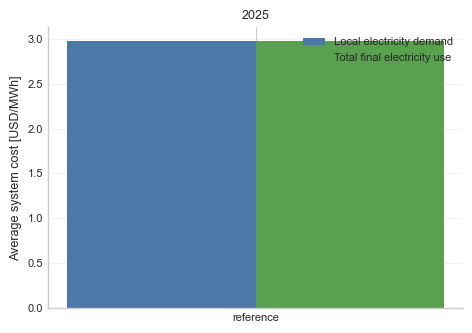

Saved system-cost summary to: output\output_new_zealand\tables\average_system_cost_by_scenario.csv


In [57]:
# Average system cost of electricity by scenario and model year
#
# Indicators:
#   1. ASCE – local demand:
#      model objective / local electricity demand
#
#   2. ASCE – total final electricity use:
#      model objective / (local demand + PtX/flexible final uses)
#
# BESS/storage charging is excluded from final electricity use.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from matplotlib.ticker import FuncFormatter


# ── Configuration ─────────────────────────────────────────────────────────────
COST_CURRENCY = "USD"

# Flexible electricity uses counted as final consumption.
# Add another carrier here if necessary.
FINAL_USE_PATTERN = (
    r"electroly[sz]er|electrolysis|asu|dac|"
    r"ammonia|methanol|heat_pump|electric_heating"
)

# Storage charging is deliberately excluded from the denominator.
STORAGE_CHARGE_PATTERN = (
    r"bess|battery|storage|store|charge|pumped"
)

cost_plot_year = globals().get(
    "detailed_year",
    2050,
)


# ── Helpers ───────────────────────────────────────────────────────────────────
def _cost_scenario_label(scenario_code):
    if callable(
        globals().get(
            "_short_scenario_label"
        )
    ):
        return _short_scenario_label(
            scenario_code
        )

    text = (
        str(scenario_code)
        .upper()
        .replace("-", "_")
    )

    if "REFERENCE" in text:
        return "Reference"

    if "PTX" in text:
        return "PtX"

    for label in ["BAU", "RT", "RE", "RH"]:
        if label in text.split("_"):
            return label

    return (
        str(scenario_code)
        .replace("_base", "")
        .replace("_BASE", "")
    )


def _annual_snapshot_weights(net, index):
    """Return strictly one-dimensional objective weights."""

    snapshot_weightings = net.snapshot_weightings

    # Extract only the objective column
    try:
        raw_weights = snapshot_weightings["objective"]
    except (KeyError, TypeError, IndexError):
        try:
            raw_weights = snapshot_weightings.objective
        except AttributeError:
            raw_weights = snapshot_weightings

    values = np.asarray(
        raw_weights,
        dtype=float,
    )

    # Extra protection if three columns are still returned
    if values.ndim == 2:
        values = values[:, 0]

    values = values.reshape(-1)

    if len(values) != len(index):
        raise ValueError(
            "Snapshot-weight length mismatch: "
            f"{len(values)} weights for {len(index)} snapshots."
        )

    return pd.Series(
        values,
        index=index,
        dtype=float,
    )


def _local_electricity_load(result):
    """Return total local electricity demand [MW]."""
    load = result.get(
        "load"
    )

    if load is None:
        net = result["network"]

        load = getattr(
            net.loads_t,
            "p_set",
            pd.DataFrame(
                index=net.snapshots
            ),
        )

    if isinstance(
        load,
        pd.Series,
    ):
        output = load.copy()

    else:
        output = (
            load
            .apply(
                pd.to_numeric,
                errors="coerce",
            )
            .fillna(0.0)
            .sum(axis=1)
        )

    return (
        pd.to_numeric(
            output,
            errors="coerce",
        )
        .fillna(0.0)
        .clip(lower=0.0)
    )


def _final_flexible_electricity_use(net):
    """
    Return PtX and other final flexible electricity uses [MW].

    Uses the previously defined electricity-balance helper.
    BESS and other storage charging are excluded.
    """
    if not callable(
        globals().get(
            "_electricity_balance_for_network"
        )
    ):
        return pd.Series(
            0.0,
            index=net.snapshots,
        )

    _, consumption = (
        _electricity_balance_for_network(
            net
        )
    )

    if consumption is None or consumption.empty:
        return pd.Series(
            0.0,
            index=net.snapshots,
        )

    consumption = (
        consumption
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
        .fillna(0.0)
        .clip(lower=0.0)
    )

    final_use_columns = []

    for column in consumption.columns:
        carrier = str(
            column
        )

        is_final_use = bool(
            pd.Series([carrier])
            .str.contains(
                FINAL_USE_PATTERN,
                case=False,
                regex=True,
                na=False,
            )
            .iloc[0]
        )

        is_storage_charging = bool(
            pd.Series([carrier])
            .str.contains(
                STORAGE_CHARGE_PATTERN,
                case=False,
                regex=True,
                na=False,
            )
            .iloc[0]
        )

        if (
            is_final_use
            and not is_storage_charging
        ):
            final_use_columns.append(
                column
            )

    if not final_use_columns:
        return pd.Series(
            0.0,
            index=consumption.index,
        )

    return (
        consumption[
            final_use_columns
        ]
        .sum(axis=1)
    )


def _slack_cost_and_energy(net, weights):
    """Estimate slack generation and its variable cost."""
    if not hasattr(
        net,
        "generators",
    ):
        return 0.0, 0.0

    carriers = (
        net.generators.get(
            "carrier",
            pd.Series(
                "",
                index=net.generators.index,
            ),
        )
        .astype(str)
    )

    slack_generators = (
        net.generators.index[
            carriers.str.contains(
                "slack",
                case=False,
                na=False,
            )
        ]
    )

    generator_dispatch = getattr(
        net.generators_t,
        "p",
        pd.DataFrame(
            index=net.snapshots
        ),
    )

    slack_generators = [
        generator
        for generator in slack_generators
        if generator
        in generator_dispatch.columns
    ]

    if not slack_generators:
        return 0.0, 0.0

    slack_dispatch = (
        generator_dispatch[
            slack_generators
        ]
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
        .fillna(0.0)
        .clip(lower=0.0)
    )

    slack_energy_by_generator = (
        slack_dispatch
        .mul(
            weights,
            axis=0,
        )
        .sum(axis=0)
    )

    marginal_cost = (
        pd.to_numeric(
            net.generators.loc[
                slack_generators,
                "marginal_cost",
            ],
            errors="coerce",
        )
        .fillna(0.0)
    )

    slack_cost = float(
        (
            slack_energy_by_generator
            * marginal_cost
        ).sum()
    )

    slack_energy = float(
        slack_energy_by_generator.sum()
    )

    return (
        slack_cost,
        slack_energy,
    )


# ── Calculate indicators ─────────────────────────────────────────────────────
system_cost_rows = []

for scenario_code, scenario_package in scenario_results.items():

    for model_year, result in (
        scenario_package["results"].items()
    ):
        net = result["network"]

        local_load = (
            _local_electricity_load(
                result
            )
        )

        flexible_final_use = (
            _final_flexible_electricity_use(
                net
            )
        )

        flexible_final_use = (
            flexible_final_use
            .reindex(
                local_load.index
            )
            .fillna(0.0)
        )

        weights = _annual_snapshot_weights(
            net,
            local_load.index,
        )

        local_demand_mwh = float(
            (
                local_load
                * weights
            ).sum()
        )

        flexible_final_use_mwh = float(
            (
                flexible_final_use
                * weights
            ).sum()
        )

        total_final_use_mwh = (
            local_demand_mwh
            + flexible_final_use_mwh
        )

        objective_value = float(
            getattr(
                net,
                "objective",
                np.nan,
            )
        )

        slack_cost_usd, slack_energy_mwh = (
            _slack_cost_and_energy(
                net,
                weights,
            )
        )

        system_cost_excluding_slack = (
            objective_value
            - slack_cost_usd
            if np.isfinite(objective_value)
            else np.nan
        )

        system_cost_rows.append(
            {
                "scenario": scenario_code,
                "paper_label": (
                    _cost_scenario_label(
                        scenario_code
                    )
                ),
                "model_year": int(
                    model_year
                ),
                "model_objective_usd": (
                    objective_value
                ),
                "local_demand_mwh": (
                    local_demand_mwh
                ),
                "flexible_final_use_mwh": (
                    flexible_final_use_mwh
                ),
                "total_final_electricity_use_mwh": (
                    total_final_use_mwh
                ),
                "slack_energy_mwh": (
                    slack_energy_mwh
                ),
                "slack_cost_usd": (
                    slack_cost_usd
                ),
                "slack_cost_share_pct": (
                    100.0
                    * slack_cost_usd
                    / objective_value
                    if objective_value > 0.0
                    else np.nan
                ),
                "asce_local_demand_usd_per_mwh": (
                    objective_value
                    / local_demand_mwh
                    if local_demand_mwh > 0.0
                    else np.nan
                ),
                "asce_total_final_use_usd_per_mwh": (
                    objective_value
                    / total_final_use_mwh
                    if total_final_use_mwh > 0.0
                    else np.nan
                ),
                "asce_local_excluding_slack_usd_per_mwh": (
                    system_cost_excluding_slack
                    / local_demand_mwh
                    if local_demand_mwh > 0.0
                    else np.nan
                ),
                "asce_total_excluding_slack_usd_per_mwh": (
                    system_cost_excluding_slack
                    / total_final_use_mwh
                    if total_final_use_mwh > 0.0
                    else np.nan
                ),
            }
        )


system_cost_summary = (
    pd.DataFrame(
        system_cost_rows
    )
    .sort_values(
        [
            "model_year",
            "paper_label",
        ]
    )
    .reset_index(drop=True)
)

display(
    system_cost_summary.round(2)
)


# ── Plot selected year ────────────────────────────────────────────────────────
plot_data = (
    system_cost_summary.loc[
        system_cost_summary[
            "model_year"
        ].eq(cost_plot_year)
    ]
    .copy()
)

scenario_order = ["Reference"]

plot_data["scenario_order"] = (
    plot_data["paper_label"]
    .map(
        {
            label: position
            for position, label
            in enumerate(scenario_order)
        }
    )
    .fillna(99)
)

plot_data = (
    plot_data
    .sort_values(
        "scenario_order"
    )
)


fig, ax = plt.subplots(
    figsize=(
        globals().get(
            "WORD_SINGLE_COL_IN",
            4.8,
        ),
        3.4,
    )
)

x_positions = np.arange(
    len(plot_data)
)

bar_width = 0.36

ax.bar(
    x_positions - bar_width / 2,
    plot_data[
        "asce_local_demand_usd_per_mwh"
    ],
    width=bar_width,
    color="#4c78a8",
    label="Local electricity demand",
)

ax.bar(
    x_positions + bar_width / 2,
    plot_data[
        "asce_total_final_use_usd_per_mwh"
    ],
    width=bar_width,
    color="#59a14f",
    label="Total final electricity use",
)

ax.set_xticks(
    x_positions
)

ax.set_xticklabels(
    plot_data["paper_label"]
)

ax.set_ylabel(
    f"Average system cost [{COST_CURRENCY}/MWh]"
)

ax.set_title(
    str(cost_plot_year)
)

ax.grid(
    axis="y",
    alpha=0.25,
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    fontsize=8,
)

fig.tight_layout()

if callable(
    globals().get(
        "save_paper_figure"
    )
):
    average_cost_figure_path = (
        save_paper_figure(
            fig,
            (
                "figure_average_system_cost_"
                f"{cost_plot_year}.png"
            ),
        )
    )

plt.show()


# ── Export ────────────────────────────────────────────────────────────────────
table_export_dir = Path(
    globals().get(
        "TABLE_EXPORT_DIR",
        ".",
    )
)

table_export_dir.mkdir(
    parents=True,
    exist_ok=True,
)

system_cost_summary_path = (
    table_export_dir
    / "average_system_cost_by_scenario.csv"
)

system_cost_summary.to_csv(
    system_cost_summary_path,
    index=False,
)

print(
    "Saved system-cost summary to: "
    f"{system_cost_summary_path}"
)

In [58]:
# ============================================================
# SHORT-TERM 2025 COUNTERFACTUAL OPERATION
# Reference | +1 GW PV | +500 MW / 2 GWh BESS | PV+BESS
#
# PV:
#   - 1 GW nationally
#   - distributed by 2025 electricity demand
#   - zone-specific 2025 PV profiles from Atlite / ERA5
#
# BESS:
#   - 500 MW / 2 GWh nationally
#   - distributed by 2025 electricity demand
#   - 4 h
#   - eta_charge = 95%
#   - eta_discharge = 95%
#
# Existing 2025 capacities are fixed.
# Only operation is re-optimised.
# ============================================================

from pathlib import Path
import tempfile

import numpy as np
import pandas as pd
import pypsa


# ============================================================
# 1. SETTINGS
# ============================================================

SHORT_TERM_YEAR = 2025

PV_TOTAL_MW = 1000.0

BESS_TOTAL_MW = 500.0
BESS_DURATION_H = 4.0

BESS_EFFICIENCY_STORE = 0.95
BESS_EFFICIENCY_DISPATCH = 0.95
BESS_STANDING_LOSS = 0.0


SHORT_TERM_CASES = {

    "Reference": {
        "pv_mw": 0.0,
        "bess_mw": 0.0,
    },

    "PV": {
        "pv_mw": PV_TOTAL_MW,
        "bess_mw": 0.0,
    },

    "BESS": {
        "pv_mw": 0.0,
        "bess_mw": BESS_TOTAL_MW,
    },

    "PV_BESS": {
        "pv_mw": PV_TOTAL_MW,
        "bess_mw": BESS_TOTAL_MW,
    },
}


SHORT_TERM_OUTPUT_DIR = (
    Path("output")
    / "short_term_2025"
)

SHORT_TERM_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 2. FIND REFERENCE 2025 NETWORK
# ============================================================

# Expected location if notebook is running from model/
BASE_2025_NETCDF = Path(
    "output/output_new_zealand/"
    "simulations/reference/2025/network.nc"
)


# If working directory is different, search automatically.
if not BASE_2025_NETCDF.exists():

    matches = list(
        Path.cwd().rglob(
            "reference/2025/network.nc"
        )
    )

    if not matches:

        raise FileNotFoundError(
            "Could not find "
            "reference/2025/network.nc"
        )

    BASE_2025_NETCDF = matches[0]


print("Base 2025 network:")
print(BASE_2025_NETCDF.resolve())
print("Exists:", BASE_2025_NETCDF.exists())


# ============================================================
# 3. LOAD BASE NETWORK
# ============================================================

base_raw = pypsa.Network(
    BASE_2025_NETCDF
)


print(
    f"\nSnapshots: {len(base_raw.snapshots):,}"
)


if len(base_raw.snapshots) != 8760:

    raise ValueError(
        "Expected 8,760 snapshots for 2025."
    )


# ============================================================
# 4. CLEAN NETWORK COPY
# ============================================================

def fresh_network_copy(net):

    """
    Create a clean PyPSA copy without carrying
    the previous Linopy optimisation model.
    """

    with tempfile.TemporaryDirectory() as tmpdir:

        path = (
            Path(tmpdir)
            / "network_copy.nc"
        )

        net.export_to_netcdf(path)

        copied = pypsa.Network(path)

    return copied


# ============================================================
# 5. FREEZE EXISTING CAPACITIES
# ============================================================

def freeze_capacities(net):

    """
    Take capacities from the solved 2025 network
    and make every expandable component fixed.
    """

    components = [

        (
            net.generators,
            "p_nom",
            "p_nom_opt",
            "p_nom_extendable",
        ),

        (
            net.storage_units,
            "p_nom",
            "p_nom_opt",
            "p_nom_extendable",
        ),

        (
            net.links,
            "p_nom",
            "p_nom_opt",
            "p_nom_extendable",
        ),

        (
            net.lines,
            "s_nom",
            "s_nom_opt",
            "s_nom_extendable",
        ),

        (
            net.stores,
            "e_nom",
            "e_nom_opt",
            "e_nom_extendable",
        ),
    ]


    for (
        table,
        nominal_col,
        optimum_col,
        extendable_col,
    ) in components:

        if table is None or table.empty:
            continue

        if optimum_col in table.columns:

            optimum = pd.to_numeric(
                table[optimum_col],
                errors="coerce",
            )

            valid = optimum.notna()

            table.loc[
                valid,
                nominal_col,
            ] = optimum.loc[valid]


        if extendable_col in table.columns:

            table.loc[
                :,
                extendable_col,
            ] = False


    return net


base_net = fresh_network_copy(
    base_raw
)

freeze_capacities(
    base_net
)


print(
    "\nBase 2025 capacities fixed."
)


# ============================================================
# 6. ELECTRICITY DEMAND SHARE BY ZONE
# ============================================================

def get_electricity_demand_share(net):

    """
    Distribution factor calculated directly
    from electricity demand stored in the NetCDF.
    """

    p_set = (
        net.loads_t.p_set
        .reindex(
            index=net.snapshots,
            columns=net.loads.index,
            fill_value=0.0,
        )
    )


    try:

        weights = pd.Series(
            net.snapshot_weightings.generators,
            index=net.snapshots,
            dtype=float,
        )

    except Exception:

        weights = pd.Series(
            1.0,
            index=net.snapshots,
        )


    annual_load = (
        p_set
        .multiply(
            weights,
            axis=0,
        )
        .sum(axis=0)
    )


    rows = []


    for load_name, energy in annual_load.items():

        bus = str(
            net.loads.loc[
                load_name,
                "bus",
            ]
        )


        if not bus.startswith(
            "elec_"
        ):
            continue


        rows.append(
            {
                "bus": bus,
                "energy": float(
                    max(
                        energy,
                        0.0,
                    )
                ),
            }
        )


    demand = (

        pd.DataFrame(rows)

        .groupby(
            "bus"
        )["energy"]

        .sum()
    )


    demand = demand[
        demand > 0
    ]


    return (
        demand
        / demand.sum()
    )


demand_share = (
    get_electricity_demand_share(
        base_net
    )
)


# ============================================================
# 7. BUILD ZONE-SPECIFIC PV PROFILES WITH ATLITE
# ============================================================

print(
    "\nBuilding 2025 zone-specific PV profiles with Atlite..."
)


# Use exactly the same node definition as the NZ model.
if "paths_base" in globals():

    nodes_path = Path(
        paths_base["csv_nodes"]
    )

else:

    nodes_path = Path(
        "input_new_zealand/nodes.csv"
    )


nodes_df = pd.read_csv(
    nodes_path,
    comment="#",
)


# Keep enabled zones only.
if "enabled" in nodes_df.columns:

    enabled_mask = (

        nodes_df["enabled"]
        .astype(str)
        .str.strip()
        .str.lower()

        .isin(
            [
                "1",
                "true",
                "t",
                "yes",
                "y",
            ]
        )
    )

    nodes_df = (
        nodes_df
        .loc[enabled_mask]
        .copy()
    )


required_columns = {
    "zone",
    "lat",
    "lon",
}

missing = (
    required_columns
    - set(nodes_df.columns)
)

if missing:

    raise ValueError(
        f"nodes.csv is missing: {missing}"
    )


# Only zones represented by electricity demand
network_zones = [

    bus.replace(
        "elec_",
        "",
        1,
    )

    for bus in demand_share.index
]


nodes_df = (

    nodes_df[
        nodes_df["zone"]
        .astype(str)
        .isin(network_zones)
    ]

    .copy()
)


print(
    f"Atlite PV zones: {len(nodes_df)}"
)


# ------------------------------------------------------------
# Reuse the SAME Atlite pipeline already implemented in config.py
# ------------------------------------------------------------

atlite_cutout = config.get_case_cutout(

    year=SHORT_TERM_YEAR,

    force_prepare=False,

    base_dir="data",

    case_name="new_zealand",

    cutout_file=(
        f"new_zealand_{SHORT_TERM_YEAR}.nc"
    ),

    nodes_df=nodes_df,
)


_, solar_cf_atlite = (
    config.get_vre_profiles_from_cutout(

        cutout=atlite_cutout,

        nodes_df=nodes_df,

        method="atlite_technology",

        wind_turbine=globals().get(
            "wind_turbine",
            "Vestas_V112_3MW",
        ),

        solar_panel=globals().get(
            "solar_panel",
            "CSi",
        ),

        solar_orientation=globals().get(
            "solar_orientation",
            "latitude_optimal",
        ),
    )
)


# ------------------------------------------------------------
# Align Atlite output exactly with PyPSA snapshots
#
# Both are 2025 hourly series, so positional assignment avoids
# timezone/index formatting differences between xarray and PyPSA.
# ------------------------------------------------------------

if len(
    solar_cf_atlite
) != len(
    base_net.snapshots
):

    raise ValueError(
        "Atlite PV profile length does not match "
        f"the PyPSA network: "
        f"{len(solar_cf_atlite)} vs "
        f"{len(base_net.snapshots)}."
    )


solar_cf_atlite = (
    solar_cf_atlite
    .copy()
)


solar_cf_atlite.index = (
    base_net.snapshots
)


solar_cf_atlite = (
    solar_cf_atlite
    .clip(
        lower=0.0,
        upper=1.0,
    )
)


# Confirm all required zones exist.
missing_solar_zones = [

    zone

    for zone in network_zones

    if zone
    not in solar_cf_atlite.columns
]


if missing_solar_zones:

    raise ValueError(
        "No Atlite PV profile for zones: "
        f"{missing_solar_zones}"
    )


print(
    "Atlite PV profiles ready."
)


# Optional quick CF diagnostic
pv_cf_summary = pd.DataFrame({

    "mean_cf":
        solar_cf_atlite[
            network_zones
        ]
        .mean(),

    "max_cf":
        solar_cf_atlite[
            network_zones
        ]
        .max(),
})


display(
    pv_cf_summary
    .round(3)
)


# ============================================================
# 8. PV ALLOCATION
# ============================================================

pv_allocation_1000 = (
    demand_share
    * PV_TOTAL_MW
)


# ============================================================
# 9. BESS ALLOCATION
# ============================================================

bess_allocation_500 = (
    demand_share
    * BESS_TOTAL_MW
)


allocation_table = pd.DataFrame({

    "bus":
        demand_share.index,

    "demand_share":
        demand_share.values,

    "PV_MW":
        pv_allocation_1000.values,

    "BESS_MW":
        bess_allocation_500.values,
})


allocation_table[
    "BESS_MWh"
] = (
    allocation_table[
        "BESS_MW"
    ]
    * BESS_DURATION_H
)


display(
    allocation_table
    .round(2)
)


print("\nNational totals:")

print(
    f"PV: "
    f"{allocation_table['PV_MW'].sum():.1f} MW"
)

print(
    f"BESS: "
    f"{allocation_table['BESS_MW'].sum():.1f} MW"
)

print(
    f"BESS energy: "
    f"{allocation_table['BESS_MWh'].sum():.1f} MWh"
)


# ============================================================
# 10. ADD ATLITE-BASED PV
# ============================================================

def add_extra_pv(
    net,
    allocation,
):

    for bus, capacity_mw in allocation.items():

        if capacity_mw <= 0:
            continue


        zone = bus.replace(
            "elec_",
            "",
            1,
        )


        if zone not in solar_cf_atlite.columns:

            raise ValueError(
                f"No Atlite PV profile "
                f"available for {zone}"
            )


        generator_name = (
            f"short_term_pv_{zone}"
        )


        net.add(

            "Generator",

            generator_name,

            bus=bus,

            carrier="solar",

            p_nom=float(
                capacity_mw
            ),

            p_nom_extendable=False,

            capital_cost=0.0,

            marginal_cost=0.0,
        )


        net.generators_t.p_max_pu[
            generator_name
        ] = (

            solar_cf_atlite[
                zone
            ]

            .reindex(
                net.snapshots
            )

            .fillna(0.0)

            .clip(
                lower=0.0,
                upper=1.0,
            )
        )


# ============================================================
# 11. ADD EXPLICIT 4-HOUR BESS
# ============================================================

def add_extra_bess(
    net,
    allocation,
):

    for bus, capacity_mw in allocation.items():

        if capacity_mw <= 0:
            continue


        zone = bus.replace(
            "elec_",
            "",
            1,
        )


        storage_name = (
            f"short_term_bess_{zone}"
        )


        net.add(

            "StorageUnit",

            storage_name,

            bus=bus,

            carrier="bess",

            p_nom=float(
                capacity_mw
            ),

            p_nom_extendable=False,

            # 500 MW nationally × 4 h
            # = 2,000 MWh nationally
            max_hours=float(
                BESS_DURATION_H
            ),

            efficiency_store=float(
                BESS_EFFICIENCY_STORE
            ),

            efficiency_dispatch=float(
                BESS_EFFICIENCY_DISPATCH
            ),

            standing_loss=float(
                BESS_STANDING_LOSS
            ),

            cyclic_state_of_charge=True,

            capital_cost=0.0,

            marginal_cost=0.0,
        )


# ============================================================
# 12. SOLVER SETTINGS
# ============================================================

def get_solver_kwargs():

    target_solver = globals().get(
        "solver_name",
        "gurobi",
    )


    options = {}


    if target_solver == "gurobi":

        if globals().get(
            "time_limit"
        ) is not None:

            options[
                "TimeLimit"
            ] = float(
                time_limit
            )


        if globals().get(
            "mip_gap"
        ) is not None:

            options[
                "MIPGap"
            ] = float(
                mip_gap
            )


        if globals().get(
            "threads"
        ) is not None:

            options[
                "Threads"
            ] = int(
                threads
            )


        options[
            "OutputFlag"
        ] = 0

        options[
            "LogToConsole"
        ] = 0


    elif target_solver == "highs":

        if globals().get(
            "time_limit"
        ) is not None:

            options[
                "time_limit"
            ] = float(
                time_limit
            )


        if globals().get(
            "mip_gap"
        ) is not None:

            options[
                "mip_rel_gap"
            ] = float(
                mip_gap
            )


        if globals().get(
            "threads"
        ) is not None:

            options[
                "threads"
            ] = int(
                threads
            )


    kwargs = {
        "solver_name":
            target_solver
    }


    if options:

        kwargs[
            "solver_options"
        ] = options


    return kwargs


# ============================================================
# 13. OPERATION-ONLY OPTIMISATION
# ============================================================

def run_operation_only(net):

    kwargs = (
        get_solver_kwargs()
    )


    extra_functionality = None


    if "config" in globals():

        extra_functionality = getattr(
            config,
            "add_custom_constraints",
            None,
        )


    if extra_functionality is not None:

        status, condition = (
            net.optimize(

                extra_functionality=
                    extra_functionality,

                **kwargs,
            )
        )


    else:

        status, condition = (
            net.optimize(
                **kwargs
            )
        )


    return (
        status,
        condition,
    )


# ============================================================
# 14. RUN COUNTERFACTUAL CASES
# ============================================================

short_term_2025_results = {}


for (
    case_name,
    case,
) in SHORT_TERM_CASES.items():


    print(
        "\n"
        + "=" * 60
    )

    print(
        f"SHORT-TERM 2025: {case_name}"
    )

    print(
        "=" * 60
    )


    # Every scenario starts from exactly
    # the same fixed 2025 reference system.
    net = fresh_network_copy(
        base_net
    )


    freeze_capacities(
        net
    )


    pv_total = float(
        case["pv_mw"]
    )


    bess_total = float(
        case["bess_mw"]
    )


    # --------------------------------------------------------
    # PV
    # --------------------------------------------------------

    if pv_total > 0:

        pv_allocation = (
            demand_share
            * pv_total
        )

        add_extra_pv(
            net,
            pv_allocation,
        )


    # --------------------------------------------------------
    # BESS
    # --------------------------------------------------------

    if bess_total > 0:

        bess_allocation = (
            demand_share
            * bess_total
        )

        add_extra_bess(
            net,
            bess_allocation,
        )


    # --------------------------------------------------------
    # OPERATION
    # --------------------------------------------------------

    status, condition = (
        run_operation_only(
            net
        )
    )


    print(
        f"Status: {status}"
    )

    print(
        f"Condition: {condition}"
    )


    # --------------------------------------------------------
    # EXPORT
    # --------------------------------------------------------

    output_nc = (

        SHORT_TERM_OUTPUT_DIR

        / f"{case_name}_2025.nc"
    )


    net.export_to_netcdf(
        output_nc
    )


    short_term_2025_results[
        case_name
    ] = {

        "network":
            net,

        "status":
            status,

        "condition":
            condition,

        "network_netcdf":
            output_nc,

        "pv_mw":
            pv_total,

        "bess_mw":
            bess_total,

        "bess_mwh":
            bess_total
            * BESS_DURATION_H,
    }


    print(
        f"PV: "
        f"{pv_total:.0f} MW"
    )

    print(
        f"BESS: "
        f"{bess_total:.0f} MW / "
        f"{bess_total * BESS_DURATION_H:.0f} MWh"
    )

    print(
        f"Saved: {output_nc}"
    )


print(
    "\n"
    + "=" * 60
)

print(
    "SHORT-TERM 2025 ANALYSIS COMPLETED"
)

print(
    "=" * 60
)

Base 2025 network:
C:\Users\vse23\OneDrive - University of Canterbury\Vicente\Analysis\0_PyPSA-Isolated\model\output\output_new_zealand\simulations\reference\2025\network.nc
Exists: True



Snapshots: 8,760

Base 2025 capacities fixed.

Building 2025 zone-specific PV profiles with Atlite...
Atlite PV zones: 14


c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\cutout.py:156: UserWarning:

Arguments module, x, y, time, dx, dy are ignored, since cutout is already built.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

INFO:atlite.convert:Convert and aggregate 'wind'.
INFO:atlite.convert:Convert and aggregate 'pv'.
c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

INFO:atlite.convert:Convert and aggregate 'wind'.
INFO:atlite.convert:Convert and aggregate 'pv'.
c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will d

Atlite PV profiles ready.


,mean_cf,max_cf
auckland,0.171,0.831
bay_of_plenty,0.166,0.853
canterbury,0.171,0.857
hawkes_bay,0.165,0.861
manawatu_whanganui,0.160,0.853
marlborough,0.176,0.855
nelson,0.167,0.845
northland,0.158,0.826
otago,0.165,1.000
southland,0.149,0.841


...

C:\Users\vse23\AppData\Local\Temp\ipykernel_36368\1477278302.py:966: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 18.25it/s]


Set parameter Username
Set parameter LicenseID to value 2807461
Academic license - for non-commercial use only - expires 2027-04-15
Read LP format model from file C:\Users\vse23\AppData\Local\Temp\linopy-problem-m6eelub1.lp
Reading time = 11.94 seconds
obj: 3828125 rows, 1769520 columns, 6088200 nonzeros
Set parameter LogToConsole to value 1
Set parameter TimeLimit to value 2000
Set parameter MIPGap to value 0.02
Set parameter Threads to value 4
Status: ok
Condition: optimal


PV: 0 MW
BESS: 500 MW / 2000 MWh
Saved: output\short_term_2025\BESS_2025.nc

SHORT-TERM 2025: PV_BESS


C:\Users\vse23\AppData\Local\Temp\ipykernel_36368\1477278302.py:966: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 11.67it/s]


Set parameter Username
Set parameter LicenseID to value 2807461
Academic license - for non-commercial use only - expires 2027-04-15
Read LP format model from file C:\Users\vse23\AppData\Local\Temp\linopy-problem-m889ac74.lp
Reading time = 17.00 seconds
obj: 4073405 rows, 1892160 columns, 6456120 nonzeros
Set parameter LogToConsole to value 1
Set parameter TimeLimit to value 2000
Set parameter MIPGap to value 0.02
Set parameter Threads to value 4
Status: ok
Condition: optimal
PV: 1000 MW
BESS: 500 MW / 2000 MWh
Saved: output\short_term_2025\PV_BESS_2025.nc

SHORT-TERM 2025 ANALYSIS COMPLETED


technology,Coal,Diesel,Gas,Geothermal,Hydro,Slack,Solar,Wind,ccgt,ocgt,other_cogeneration
Reference,0.0,0.0,0.001,11.031,2.539,0.0,0.612,4.071,0.333,0.0,0.0
PV,0.0,0.0,0.001,10.971,2.491,0.0,1.995,4.015,0.014,0.0,0.0
BESS,0.0,0.0,0.000,11.031,2.543,0.0,0.613,4.073,0.274,0.0,0.0
PV_BESS,0.0,0.0,0.000,10.898,2.503,0.0,2.000,3.978,0.002,0.0,0.0


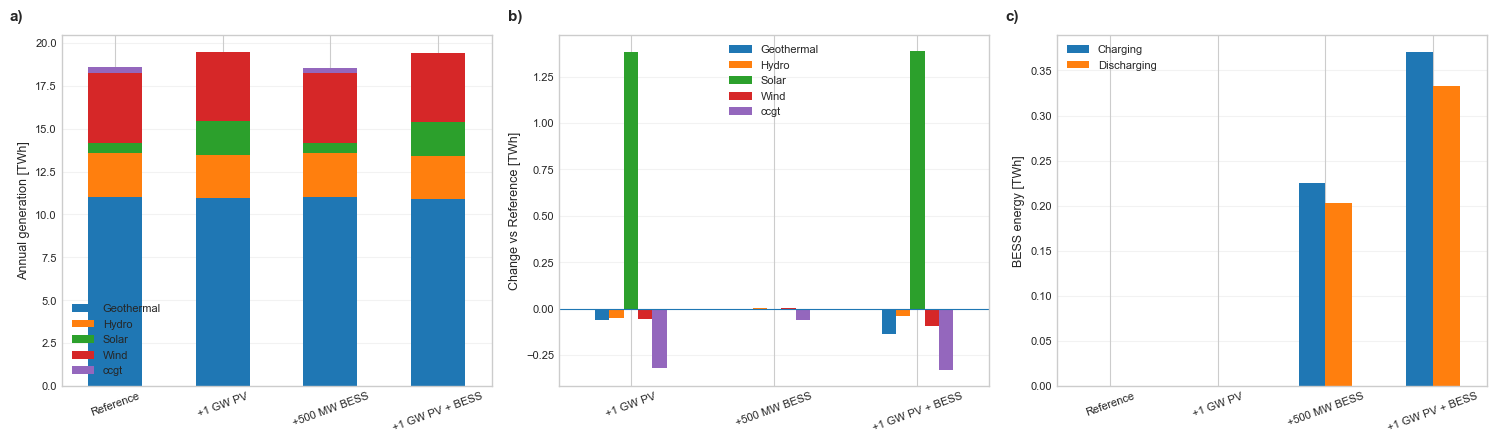

In [59]:
# ============================================================
# SHORT-TERM 2025 — ANNUAL COMPARISON
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


CASES = [
    "Reference",
    "PV",
    "BESS",
    "PV_BESS",
]

CASE_LABELS = {
    "Reference": "Reference",
    "PV": "+1 GW PV",
    "BESS": "+500 MW BESS",
    "PV_BESS": "+1 GW PV + BESS",
}


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def snapshot_weights(net):

    try:
        return pd.Series(
            net.snapshot_weightings.generators,
            index=net.snapshots,
            dtype=float,
        )
    except Exception:
        return pd.Series(
            1.0,
            index=net.snapshots,
        )


def clean_carrier(carrier):

    c = str(carrier).lower()

    mapping = {
        "solar": "Solar",
        "wind": "Wind",
        "hydro": "Hydro",
        "geothermal": "Geothermal",
        "gas": "Gas",
        "coal": "Coal",
        "diesel": "Diesel",
        "oil": "Oil",
        "biomass": "Biomass",
        "slack": "Slack",
    }

    for key, label in mapping.items():
        if key in c:
            return label

    return str(carrier)


# ------------------------------------------------------------
# Annual generator output
# ------------------------------------------------------------

annual_generation = {}


for case in CASES:

    net = short_term_2025_results[
        case
    ]["network"]

    weights = snapshot_weights(net)

    dispatch = (
        net.generators_t.p
        .multiply(
            weights,
            axis=0,
        )
        .sum(axis=0)
    )

    carrier = (
        net.generators["carrier"]
        .reindex(dispatch.index)
        .fillna("Other")
    )

    table = pd.DataFrame({
        "generation_mwh": dispatch,
        "carrier": carrier,
    })

    table["technology"] = (
        table["carrier"]
        .map(clean_carrier)
    )

    annual_generation[case] = (
        table
        .groupby("technology")[
            "generation_mwh"
        ]
        .sum()
        / 1e6
    )


annual_generation = (
    pd.DataFrame(
        annual_generation
    )
    .T
    .fillna(0.0)
)


# Remove tiny numerical values
annual_generation[
    annual_generation.abs() < 1e-6
] = 0.0


display(
    annual_generation.round(3)
)


# ------------------------------------------------------------
# BESS annual operation
# ------------------------------------------------------------

bess_summary = []


for case in CASES:

    net = short_term_2025_results[
        case
    ]["network"]

    weights = snapshot_weights(net)

    if net.storage_units.empty:

        charge = 0.0
        discharge = 0.0

    else:

        carrier = (
            net.storage_units["carrier"]
            .astype(str)
            .str.lower()
        )

        bess_names = (
            net.storage_units
            .index[
                carrier.str.contains(
                    "bess|battery",
                    regex=True,
                )
            ]
        )


        if len(bess_names) == 0:

            charge = 0.0
            discharge = 0.0

        else:

            p = (
                net.storage_units_t.p[
                    bess_names
                ]
            )

            # StorageUnit convention:
            # positive = discharge
            # negative = charge

            discharge = (
                p.clip(lower=0)
                .multiply(
                    weights,
                    axis=0,
                )
                .sum()
                .sum()
                / 1e6
            )

            charge = (
                -p.clip(upper=0)
                .multiply(
                    weights,
                    axis=0,
                )
                .sum()
                .sum()
                / 1e6
            )


    bess_summary.append({
        "case": case,
        "charge_TWh": charge,
        "discharge_TWh": discharge,
    })


bess_summary = (
    pd.DataFrame(
        bess_summary
    )
    .set_index("case")
)


# ------------------------------------------------------------
# Change relative to Reference
# ------------------------------------------------------------

reference = (
    annual_generation
    .loc["Reference"]
)


delta_generation = (
    annual_generation
    .subtract(
        reference,
        axis=1,
    )
)


# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4.5),
)


# ------------------------------------------------------------
# A — Annual generation
# ------------------------------------------------------------

plot_generation = (
    annual_generation.copy()
)

# Avoid clutter from negligible categories
keep = (
    plot_generation.max(axis=0)
    > 0.01
)

plot_generation = (
    plot_generation.loc[:, keep]
)


plot_generation.index = [
    CASE_LABELS[i]
    for i in plot_generation.index
]


plot_generation.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
)


axes[0].set_ylabel(
    "Annual generation [TWh]"
)

axes[0].set_xlabel("")

axes[0].tick_params(
    axis="x",
    rotation=20,
)

axes[0].legend(
    title="",
    fontsize=8,
)


# ------------------------------------------------------------
# B — Change relative to Reference
# ------------------------------------------------------------

delta_plot = (
    delta_generation
    .drop(
        index="Reference"
    )
)


keep = (
    delta_plot.abs()
    .max(axis=0)
    > 0.005
)

delta_plot = (
    delta_plot.loc[:, keep]
)


delta_plot.index = [
    CASE_LABELS[i]
    for i in delta_plot.index
]


delta_plot.plot(
    kind="bar",
    ax=axes[1],
)


axes[1].axhline(
    0,
    linewidth=0.8,
)


axes[1].set_ylabel(
    "Change vs Reference [TWh]"
)

axes[1].set_xlabel("")

axes[1].tick_params(
    axis="x",
    rotation=20,
)

axes[1].legend(
    title="",
    fontsize=8,
)


# ------------------------------------------------------------
# C — BESS operation
# ------------------------------------------------------------

bess_plot = (
    bess_summary.copy()
)


bess_plot.index = [
    CASE_LABELS[i]
    for i in bess_plot.index
]


bess_plot[
    [
        "charge_TWh",
        "discharge_TWh",
    ]
].plot(
    kind="bar",
    ax=axes[2],
)


axes[2].set_ylabel(
    "BESS energy [TWh]"
)

axes[2].set_xlabel("")

axes[2].tick_params(
    axis="x",
    rotation=20,
)

axes[2].legend(
    [
        "Charging",
        "Discharging",
    ],
    title="",
)


# ------------------------------------------------------------
# Panel labels
# ------------------------------------------------------------

for ax, label in zip(
    axes,
    ["a)", "b)", "c)"],
):

    ax.text(
        -0.12,
        1.04,
        label,
        transform=ax.transAxes,
        fontweight="bold",
        fontsize=11,
    )

    ax.grid(
        axis="y",
        alpha=0.25,
    )


plt.tight_layout()

plt.show()

Technology,Coal,Diesel,Gas,Geothermal,Hydro,Slack,Solar,Wind,ccgt,hydro_storage,other_cogeneration
Case,,,,,,,,,,,
+1 GW PV,0.0,0.0,0.001,10.971,19.628,0.0,1.995,4.015,0.014,2.491,0.0
+1 GW PV + BESS,0.0,0.0,0.000,10.898,19.022,0.0,2.000,3.978,0.002,2.503,0.0
+500 MW BESS,0.0,0.0,0.000,11.031,19.804,0.0,0.613,4.073,0.274,2.543,0.0
Reference,0.0,0.0,0.001,11.031,19.800,0.0,0.612,4.071,0.333,2.539,0.0


,Demand [TWh],Generation excl. BESS [TWh],BESS discharge [TWh],BESS charge [TWh],Thermal [TWh],Slack [TWh],Wind+solar available [TWh],Wind+solar dispatched [TWh],Curtailment [TWh]
Case,,,,,,,,,
Reference,37.796,38.388,0.000,0.000,0.001,0.0,4.686,4.683,0.003
+1 GW PV,37.796,39.115,0.000,0.000,0.001,0.0,6.132,6.010,0.122
+500 MW BESS,37.796,38.337,0.203,0.225,0.000,0.0,4.686,4.686,0.000
+1 GW PV + BESS,37.796,38.404,0.333,0.371,0.000,0.0,6.132,5.979,0.153


Technology,Coal,Diesel,Gas,Geothermal,Hydro,Slack,Solar,Wind,ccgt,hydro_storage,other_cogeneration
Case,,,,,,,,,,,
+1 GW PV,0.0,0.0,-0.000,-0.061,-0.172,0.0,1.383,-0.055,-0.319,-0.048,0.0
+1 GW PV + BESS,0.0,-0.0,-0.001,-0.133,-0.778,-0.0,1.388,-0.092,-0.331,-0.037,0.0
+500 MW BESS,0.0,-0.0,-0.001,0.000,0.004,-0.0,0.001,0.002,-0.059,0.003,0.0
Reference,0.0,0.0,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.0


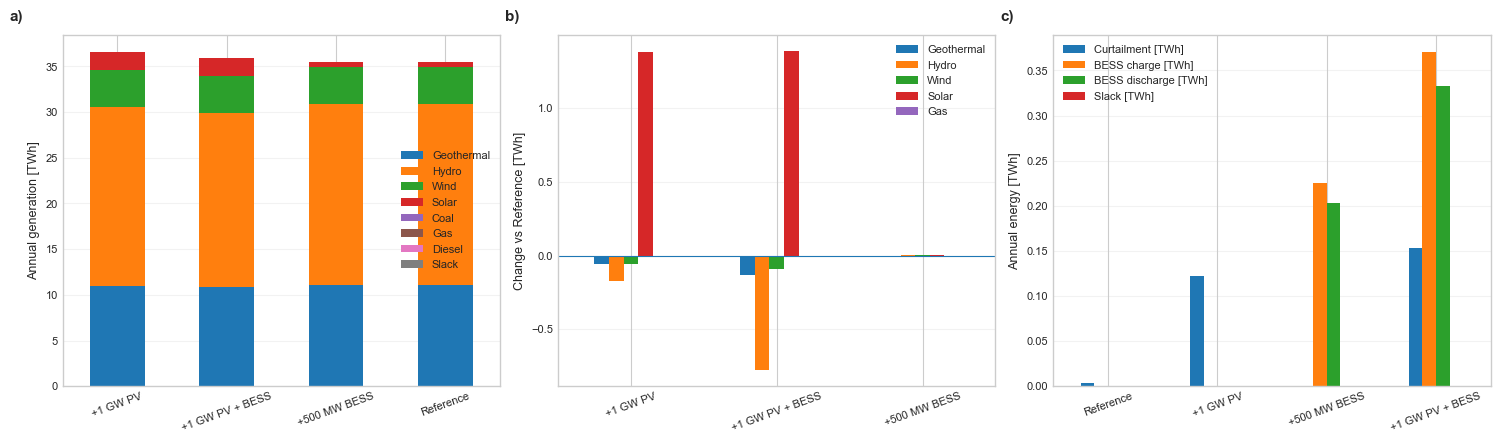

In [61]:
# ============================================================
# SHORT-TERM 2025 — CORRECT ANNUAL ENERGY BALANCE
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


CASES = [
    "Reference",
    "PV",
    "BESS",
    "PV_BESS",
]

CASE_LABELS = {
    "Reference": "Reference",
    "PV": "+1 GW PV",
    "BESS": "+500 MW BESS",
    "PV_BESS": "+1 GW PV + BESS",
}


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def get_weights(net):
    try:
        return pd.Series(
            net.snapshot_weightings.generators,
            index=net.snapshots,
            dtype=float,
        )
    except Exception:
        return pd.Series(
            1.0,
            index=net.snapshots,
        )


def classify_generator(carrier):

    c = str(carrier).lower().strip()

    if c == "solar":
        return "Solar"

    if c == "wind":
        return "Wind"

    if c == "geothermal":
        return "Geothermal"

    if c == "coal":
        return "Coal"

    if c in {
        "cogt",
        "ocgt",
        "gas_peaker",
        "gas_cogeneration",
    }:
        return "Gas"

    if c == "diesel_peaker":
        return "Diesel"

    if c == "other_generation":
        return "Other"

    if c == "slack":
        return "Slack"

    return str(carrier)


def classify_storage(carrier):

    c = str(carrier).lower().strip()

    if c == "hydro_storage":
        return "Hydro"

    if "bess" in c or "battery" in c:
        return "BESS"

    return str(carrier)


# ============================================================
# 1. CALCULATE ANNUAL ENERGY BY TECHNOLOGY
# ============================================================

annual_rows = []
balance_rows = []


for case in CASES:

    net = short_term_2025_results[case]["network"]

    weights = get_weights(net)


    # --------------------------------------------------------
    # DEMAND
    # --------------------------------------------------------

    demand_twh = (
        net.loads_t.p_set
        .multiply(weights, axis=0)
        .sum()
        .sum()
        / 1e6
    )


    # --------------------------------------------------------
    # GENERATORS
    # --------------------------------------------------------

    generator_dispatch = (
        net.generators_t.p
        .multiply(weights, axis=0)
        .sum(axis=0)
    )


    generator_table = pd.DataFrame({
        "energy_mwh": generator_dispatch,
        "carrier": (
            net.generators["carrier"]
            .reindex(generator_dispatch.index)
        ),
    })


    generator_table["technology"] = (
        generator_table["carrier"]
        .map(classify_generator)
    )


    generator_energy = (
        generator_table
        .groupby("technology")["energy_mwh"]
        .sum()
        / 1e6
    )


    # --------------------------------------------------------
    # STORAGE UNITS
    # --------------------------------------------------------

    storage_energy = pd.Series(dtype=float)

    bess_charge_twh = 0.0
    bess_discharge_twh = 0.0
    hydro_generation_twh = 0.0


    if not net.storage_units.empty:

        storage_p = (
            net.storage_units_t.p
            .reindex(
                columns=net.storage_units.index,
                fill_value=0.0,
            )
        )


        for su in net.storage_units.index:

            carrier = (
                net.storage_units.loc[
                    su,
                    "carrier",
                ]
            )

            technology = classify_storage(
                carrier
            )

            p = storage_p[su]


            discharge_twh = (
                p.clip(lower=0)
                .multiply(weights)
                .sum()
                / 1e6
            )


            charge_twh = (
                -p.clip(upper=0)
                .multiply(weights)
                .sum()
                / 1e6
            )


            if technology == "Hydro":

                hydro_generation_twh += (
                    discharge_twh
                )


            elif technology == "BESS":

                bess_discharge_twh += (
                    discharge_twh
                )

                bess_charge_twh += (
                    charge_twh
                )


    # --------------------------------------------------------
    # TOTAL SUPPLY BY TECHNOLOGY
    # --------------------------------------------------------

    energy_by_tech = (
        generator_energy
        .copy()
    )


    energy_by_tech.loc["Hydro"] = (
        energy_by_tech.get(
            "Hydro",
            0.0,
        )
        + hydro_generation_twh
    )


    for technology, value in energy_by_tech.items():

        annual_rows.append({
            "Case": CASE_LABELS[case],
            "Technology": technology,
            "Generation_TWh": value,
        })


    # --------------------------------------------------------
    # WIND + SOLAR AVAILABILITY / CURTAILMENT
    # --------------------------------------------------------

    renewable_mask = (
        net.generators["carrier"]
        .astype(str)
        .str.lower()
        .isin(
            [
                "wind",
                "solar",
            ]
        )
    )


    renewable_names = (
        net.generators
        .index[renewable_mask]
    )


    available_renewable_mwh = 0.0
    dispatched_renewable_mwh = 0.0


    for g in renewable_names:

        p_nom = float(
            net.generators.loc[
                g,
                "p_nom",
            ]
        )


        if g in net.generators_t.p_max_pu.columns:

            available = (
                net.generators_t.p_max_pu[g]
                * p_nom
            )

            available_renewable_mwh += (
                available
                .multiply(weights)
                .sum()
            )


        if g in net.generators_t.p.columns:

            dispatched_renewable_mwh += (
                net.generators_t.p[g]
                .multiply(weights)
                .sum()
            )


    renewable_available_twh = (
        available_renewable_mwh
        / 1e6
    )

    renewable_dispatch_twh = (
        dispatched_renewable_mwh
        / 1e6
    )

    curtailment_twh = max(
        renewable_available_twh
        - renewable_dispatch_twh,
        0.0,
    )


    # --------------------------------------------------------
    # SLACK
    # --------------------------------------------------------

    slack_twh = (
        generator_energy.get(
            "Slack",
            0.0,
        )
    )


    # --------------------------------------------------------
    # THERMAL GENERATION
    # --------------------------------------------------------

    thermal_twh = sum(
        generator_energy.get(
            tech,
            0.0,
        )
        for tech in [
            "Coal",
            "Gas",
            "Diesel",
            "Other",
        ]
    )


    # --------------------------------------------------------
    # TOTAL ELECTRICITY SUPPLY
    # --------------------------------------------------------

    total_supply_twh = (
        generator_energy.sum()
        + hydro_generation_twh
        + bess_discharge_twh
    )


    balance_rows.append({

        "Case":
            CASE_LABELS[case],

        "Demand [TWh]":
            demand_twh,

        "Generation excl. BESS [TWh]":
            generator_energy.sum()
            + hydro_generation_twh,

        "BESS discharge [TWh]":
            bess_discharge_twh,

        "BESS charge [TWh]":
            bess_charge_twh,

        "Thermal [TWh]":
            thermal_twh,

        "Slack [TWh]":
            slack_twh,

        "Wind+solar available [TWh]":
            renewable_available_twh,

        "Wind+solar dispatched [TWh]":
            renewable_dispatch_twh,

        "Curtailment [TWh]":
            curtailment_twh,
    })


# ============================================================
# 2. TABLES
# ============================================================

annual_generation_corrected = (
    pd.DataFrame(annual_rows)
    .pivot_table(
        index="Case",
        columns="Technology",
        values="Generation_TWh",
        aggfunc="sum",
        fill_value=0.0,
    )
)


energy_balance_corrected = (
    pd.DataFrame(balance_rows)
    .set_index("Case")
)


display(
    annual_generation_corrected
    .round(3)
)


display(
    energy_balance_corrected
    .round(3)
)


# ============================================================
# 3. CHANGE RELATIVE TO REFERENCE
# ============================================================

reference = (
    annual_generation_corrected
    .loc["Reference"]
)


delta_generation_corrected = (
    annual_generation_corrected
    .subtract(
        reference,
        axis=1,
    )
)


display(
    delta_generation_corrected
    .round(3)
)


# ============================================================
# 4. PLOT
# ============================================================

preferred_order = [
    "Geothermal",
    "Hydro",
    "Wind",
    "Solar",
    "Coal",
    "Gas",
    "Diesel",
    "Other",
    "Slack",
]


columns = [
    c
    for c in preferred_order
    if c in annual_generation_corrected.columns
]


plot_data = (
    annual_generation_corrected[
        columns
    ]
    .copy()
)


fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4.5),
)


# ------------------------------------------------------------
# a) Annual generation
# ------------------------------------------------------------

plot_data.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
)


axes[0].set_ylabel(
    "Annual generation [TWh]"
)

axes[0].set_xlabel("")

axes[0].tick_params(
    axis="x",
    rotation=20,
)

axes[0].legend(
    title="",
    fontsize=8,
)


# ------------------------------------------------------------
# b) Change vs Reference
# ------------------------------------------------------------

delta_plot = (
    delta_generation_corrected
    .drop(
        index="Reference"
    )
)


delta_columns = [
    c
    for c in preferred_order
    if c in delta_plot.columns
    and delta_plot[c].abs().max() > 0.001
]


delta_plot[
    delta_columns
].plot(
    kind="bar",
    ax=axes[1],
)


axes[1].axhline(
    0,
    linewidth=0.8,
)


axes[1].set_ylabel(
    "Change vs Reference [TWh]"
)

axes[1].set_xlabel("")

axes[1].tick_params(
    axis="x",
    rotation=20,
)

axes[1].legend(
    title="",
    fontsize=8,
)


# ------------------------------------------------------------
# c) Flexibility indicators
# ------------------------------------------------------------

flex = (
    energy_balance_corrected[
        [
            "Curtailment [TWh]",
            "BESS charge [TWh]",
            "BESS discharge [TWh]",
            "Slack [TWh]",
        ]
    ]
    .copy()
)


flex.plot(
    kind="bar",
    ax=axes[2],
)


axes[2].set_ylabel(
    "Annual energy [TWh]"
)

axes[2].set_xlabel("")

axes[2].tick_params(
    axis="x",
    rotation=20,
)

axes[2].legend(
    title="",
    fontsize=8,
)


# ------------------------------------------------------------
# Panel labels
# ------------------------------------------------------------

for ax, label in zip(
    axes,
    ["a)", "b)", "c)"],
):

    ax.text(
        -0.12,
        1.04,
        label,
        transform=ax.transAxes,
        fontweight="bold",
        fontsize=11,
    )

    ax.grid(
        axis="y",
        alpha=0.25,
    )


plt.tight_layout()

plt.show()